# Developed CNN Architecture (No Improving CNN Architecture + Bicubic Grayscale PNG + 5-Fold))

### 1.1 Libraries

In [3]:
%%time

import os
import pickle
import shutil
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Importar librerias de tensorflow
import tensorflow as tf
from tensorflow.keras.models import load_model
#from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

CPU times: user 723 µs, sys: 368 µs, total: 1.09 ms
Wall time: 1.11 ms


In [4]:
!nvidia-smi

Tue Jun  3 02:02:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.107.02             Driver Version: 550.107.02     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5500               Off |   00000000:1D:00.0 Off |                  Off |
| 37%   64C    P2             77W /  230W |     963MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.config.experimental.get_visible_devices())


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.2. Sound and Source

In [6]:
from IPython.display import Audio
import time

def sound():
    beep_07a_path = '/notebooks/beep-07a.wav'
    beep_08b_path = '/notebooks/beep-08b.wav'

    for _ in range(2):
        sound_beep_07a = Audio(beep_07a_path, autoplay=True)
        display(sound_beep_07a)
        time.sleep(0.3)
        sound_beep_08b = Audio(beep_08b_path, autoplay=True)
        display(sound_beep_08b)
        time.sleep(0.3)
sound()

### 1.3. Create a dictionary to store samples by malware families

In [7]:
source = '/notebooks/train3/'
# Inicializar un diccionario para almacenar la cantidad de muestras por familia
malware_families_train, malware_families_valid, malware_families_test, malware_families = {}, {}, {}, {}
train_data_dir = os.path.join(source, 'centum_1500/train/')
valid_data_dir = os.path.join(source, 'centum_1500/valid/')
test_data_dir = os.path.join(source, 'centum_1500/test/')
# Recorrer los directorios de las familias de malware
for familia in os.listdir(train_data_dir):
    # Comprobar si es un directorio
    if os.path.isdir(os.path.join(train_data_dir, familia)):
        # Contar la cantidad de archivos en el directorio de la familia
        cantidad_muestras_train = len(os.listdir(os.path.join(train_data_dir, familia)))
        cantidad_muestras_valid = len(os.listdir(os.path.join(valid_data_dir, familia)))
        cantidad_muestras_test = len(os.listdir(os.path.join(test_data_dir, familia)))
        # Agregar la cantidad al diccionario con el nombre de la familia como clave
        malware_families_train[familia] = cantidad_muestras_train
        malware_families_valid[familia] = cantidad_muestras_valid
        malware_families_test[familia] = cantidad_muestras_test

for d in (malware_families_train, malware_families_valid, malware_families_test):
    for key, value in d.items():
        if key in malware_families:
            malware_families[key] += value
        else:
            malware_families[key] = value

# Ordenar las familias de mayor a menor según la cantidad de muestras
sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)
# Imprimir el diccionario resultante
sorted_families

[('sfone', 1500),
 ('sillyp2p', 1500),
 ('Allaple.A', 1500),
 ('Ramnit', 1500),
 ('wabot', 1500),
 ('mira', 1500),
 ('Kelihos_ver3', 1500),
 ('ganelp', 1500),
 ('Allaple.L', 1500),
 ('wacatac', 1500),
 ('dinwod', 1500),
 ('Lollipop', 1500),
 ('berbew', 1500),
 ('small', 1500),
 ('upatre', 1500)]

### 1.3. Create a dictionary to store samples by malware families

In [8]:
%%time

def copy_malware_families(source, num_experiments, sorted_families):
    
    # Crea el directorio que contendrá el malware
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    os.makedirs(experiment_dir, exist_ok=True)

    # Ordenar las familias de mayor a menor según la cantidad de muestras
    #sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)

    # Crear directorios train, test, y valid del experimento
    for data_type in ['train', 'test', 'valid']:
        data_dir = os.path.join(experiment_dir, data_type)
        os.makedirs(data_dir, exist_ok=True)
        
        # Copiar las familias correspondientes
        for j in range(num_experiments):
            family_name, num_samples = sorted_families[j]
            family_dir = os.path.join(data_dir, family_name)
            os.makedirs(family_dir, exist_ok=True)
            source_dir = os.path.join(source, 'centum_1500', data_type, family_name)
            
            # Copiar las num_samples muestras de cada familia
            for filename in os.listdir(source_dir)[:num_samples]:
                source_path = os.path.join(source_dir, filename)
                dest_path = os.path.join(family_dir, filename)
                shutil.copy(source_path, dest_path)
    print("Familias de malware copiadas")
    #sound()

def delete_experiment_dir(source, num_experiments):
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    shutil.rmtree(experiment_dir)
    print(f"La carpeta {str(num_experiments)} fue eliminada.")

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 10.3 µs


## 2. Convolutional Neural Network Decay Evaluation Metrics by Increase in Malware Families

### 2.1. Calculate Weights by Class

In [9]:
%%time

def weights_by_class(train_generator):
    # Calculate class weights using compute_class_weight
    class_weights = compute_class_weight(class_weight = 'balanced',
                         classes = np.unique(train_generator.classes), 
                         y = train_generator.classes)
    # Create a dictionary of class weights
    class_weight_dict = dict(enumerate(class_weights))
    # Print class weights
    print("Class Weights:", class_weight_dict)
    return class_weight_dict

CPU times: user 8 µs, sys: 4 µs, total: 12 µs
Wall time: 19.8 µs


### 2.2. Image generator (Training, validation, and testing)

In [10]:
%%time

def data_gen(source_cnn, train_data_dir, validation_data_dir, test_data_dir):
    # Settings for Data Generator
    train_datagen = ImageDataGenerator(rescale=1./255)
    validation_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
            train_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    validation_generator = validation_datagen.flow_from_directory(
            validation_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    test_generator = test_datagen.flow_from_directory(
            test_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')
    return (train_generator, validation_generator, test_generator)

CPU times: user 6 µs, sys: 3 µs, total: 9 µs
Wall time: 15 µs


### 2.3. Creation of the Model Based on the Architecture
Descongelamos 5 capas de MobileNet para esta versión, pero para más adelante, version optimizada,podemos desconger 10 capas.

In [11]:
%%time

def new_model(num_classes):
    # Use MobileNet architecture with imagenet weights by transfer Learning 
    base_model = MobileNet(weights='imagenet',
                           include_top=False,
                           input_shape=(img_width, img_height, 3))

    # Freeze the convolutional layers of the pretrained model
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze the last 10 layers of the MobileNet base model
    for layer in base_model.layers[-5:]:
        layer.trainable = True

    # Malware classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    #x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x) # Probar con 0.5 si no mejora los resultados
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)  # Nueva capa adicional
    x = Dropout(0.3)(x) # Nueva capa adicional
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    # Combining the pretrained model with the malware classification layer
    model = models.Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with an optimizer and learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    
    # Calculate the total # parameters
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    # Print request info paramers
    print("Total params: {}".format(total_params))
    print("Trainable params: {}".format(trainable_params))
    print("Non-trainable params: {}".format(non_trainable_params))

    
    return model

CPU times: user 5 µs, sys: 2 µs, total: 7 µs
Wall time: 12.2 µs


### 2.4. Evaluate the model and graphs

#### 2.4.1. Get the accuracy and log loss of the model (Train, Validation and Test)

In [12]:
%%time

def prediction(model, train_generator, validation_generator, test_generator):
    # Obtener la precisión y la pérdida en el conjunto de datos de entrenamiento
    train_loss, train_acc = model.evaluate(train_generator, verbose=1)
    print('Train Accuracy:', train_acc)
    print('Train Log Loss:', train_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de validación
    val_loss, val_acc = model.evaluate(validation_generator, verbose=1)
    print('Validation Accuracy:', val_acc)
    print('Validation Log Loss:', val_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de prueba
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    print('Test Accuracy:', test_acc)
    print('Test Log Loss:', test_loss)
    
    # Return test_loss and test_acc
    return(test_acc, test_loss)

CPU times: user 16 µs, sys: 8 µs, total: 24 µs
Wall time: 28.6 µs


#### 2.4.2. Precision, Recall, Confusion Matrix and  AUC

In [13]:
%%time

def confu_matrix(model, test_generator):
# Get the total number of samples in the test builder
    total_samples = len(test_generator)
    print(f"Test labels: {test_generator.class_indices}")

    # Get test builder batch size
    batch_size = test_generator.batch_size

    # Create lists to store the actual and predicted labels
    true_labels = []
    predicted_labels = []

    # Iterate over all batches in the test builder
    for batch_index in range(total_samples):
        # Get a batch of data from the test builder
        batch_images, batch_labels = test_generator[batch_index]

        # Make predictions on the current batch
        batch_predictions = model.predict_on_batch(batch_images)

        # Get the actual labels of the current batch
        true_labels.extend(np.argmax(batch_labels, axis=1))

        # Get the predicted labels of the current batch
        predicted_labels.extend(np.argmax(batch_predictions, axis=1))

    # Convert lists of labels to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Calculate the confusion matrix
    confusion_mtx = confusion_matrix(true_labels, predicted_labels)

    print("\nMatriz de Confusión:")
    print(confusion_mtx)
    print(f"True labels: {len(true_labels)}")
    print(f"Predicted labels: len(predicted_labels)")

    # Get the classification report
    class_report = classification_report(true_labels, predicted_labels)

    # Print the classification report
    print('\nClassification report:')
    print(class_report)

    # Get the predictions for the test dataset
    y_test_pred = model.predict(test_generator)

    # Get the AUC
    #test_auc = roc_auc_score(true_labels, y_test_pred, multi_class='ovr')
    #print('AUC:', test_auc)
    
    # Normalize the confusion matrix
    cm_norm = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]

    # Set up plot with 12x12 inch figure
    plt.figure(figsize=(12, 12))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.show()
    
    crd = classification_report(true_labels, predicted_labels, output_dict=True)
    
    return crd['macro avg']['precision'], crd['macro avg']['recall'], crd['macro avg']['f1-score']
    

CPU times: user 0 ns, sys: 9 µs, total: 9 µs
Wall time: 15.5 µs


## 3. Decay Evaluation Metrics by Increase in Malware Families

### 3.1. Settings (Configurar)

In [14]:
%%time

# Experiment dir 
source = '/notebooks/train3/'

# Model names to use for save'
nombre_modelo = 'MobileNet_tf_1500'
save_model = source + 'layer_contribution/MobileNet_tf_optimized/'
os.makedirs(save_model, exist_ok=True)

# Resize all images to 224x224
img_width, img_height = 224, 224

# Configuring the hyperparameters
batch_size = 32
num_epochs = 50
learning_rate = 0.0001
num_folds = 5

test_acc_list_all = []
test_loss_list_all = []
precision_list_all = []
recall_list_all = []
f1_score_list_all = []

sound()

CPU times: user 19.6 ms, sys: 0 ns, total: 19.6 ms
Wall time: 1.22 s


In [15]:
%%time

def exp(num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all):
    # Copiar las familias a ser clasificadas
    copy_malware_families(source, num_classes, sorted_families)
    
    ### SETTINGS ###
    source2 = os.path.join(source, 'all_malware',str(num_classes))
    print(f"source2: {source2}")
    name_save_model = nombre_modelo + str(num_classes)
    print(f"name_save_model: {name_save_model}")
    
    train_data_dir = source2 + '/train/'
    validation_data_dir = source2 + '/valid/'
    test_data_dir = source2 + '/test/'

    # Settings for Data Generator
    train_generator, validation_generator, test_generator = data_gen(source2, train_data_dir, 
                                                                     validation_data_dir, test_data_dir)

    # Print the familias to be classified
    print("Lista de clases de malware a ser analizadas:")
    source_dir = os.path.join(source2, 'train/')
    for  dir in os.listdir(source_dir):
        print("- "+dir)

    # Defines the number of folds for cross validation
    num_folds = 5

    # Split the data set into folds
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    # Lists to store the metrics of each fold
    fold_train_histories, fold_val_histories = [], []
    test_loss_list, test_acc_list = [], []
    precision_list, recall_list, f1_score_list = [], [], []
    
    # Variables to track the best fold
    best_val_accuracy = 0
    best_fold_idx = 0

    for fold_idx, (train_index, val_index) in enumerate(skf.split(train_generator.filenames, train_generator.classes)):
        print('')
        print('=' * 100)
        print(f'TRAINING AND EVALUATING FOLD {fold_idx + 1}/{num_folds}...\n')

        # Create and Compile Xception model with an optimizer and learning rate
        model = new_model(num_classes)

        early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)

        # Training the malware classification layer with the ReduceLROnPlateau callback
        history_model = model.fit(
            train_generator,
            steps_per_epoch=train_generator.samples // batch_size,
            epochs=num_epochs,
            validation_data=validation_generator,
            validation_steps=validation_generator.samples // batch_size,
            callbacks=[early_stopping],
        )

        sound()

        # Check if this fold is the best one
        current_val_accuracy = max(history_model.history['val_accuracy'])
        if current_val_accuracy > best_val_accuracy:
            best_val_accuracy = current_val_accuracy
            best_fold_idx = fold_idx + 1
            # Save the best model
            model.save(save_model+name_save_model+'_best.h5')

        ##### SAVE HISTORY FOR ALL FOLDS #####
        with open(save_model+'history_'+name_save_model+'_'+str(fold_idx + 1)+'.pkl', 'wb') as file:
            pickle.dump(history_model.history, file)
        print(f"History for fold {fold_idx + 1} saved...")

        # Store training and validation metrics for this fold
        fold_train_histories.append(history_model.history['accuracy'])
        fold_val_histories.append(history_model.history['val_accuracy'])

        # Store Metrics
        test_acc, test_loss = prediction(model, train_generator, validation_generator, test_generator)
        test_acc_list.append(test_acc)
        test_loss_list.append(test_loss)
        precision, recall, f1_score = confu_matrix(model, test_generator)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_score_list.append(f1_score)

    print(f"\nBest fold was {best_fold_idx} with val_accuracy: {best_val_accuracy:.4f}")

    # Calcula el promedio de las métricas de todos los pliegues
    avg_train_accuracy = sum([max(hist) for hist in fold_train_histories]) / num_folds
    avg_val_accuracy = sum([max(hist) for hist in fold_val_histories]) / num_folds
    # Imprime el promedio de las métricas de entrenamiento y validación
    print(f'Average training accuracy in {num_folds}-fold: {avg_train_accuracy}')
    print(f'Average validation precision in {num_folds}-fold: {avg_val_accuracy}')

    print("\nTest Metrics")
    print(f"test_acc_list: {test_acc_list}")
    print(f'Average Test Accuracy with {num_folds}-fold: {sum(test_acc_list)/len(test_acc_list)}')
    print(f"test_loss_list: {test_loss_list}")
    print(f'Average Test Log Loss with {num_folds}-fold: {sum(test_loss_list)/len(test_loss_list)}')
    print(f'\nPrecision List: {precision_list}')
    print(f'Average Precision List with {num_folds}-fold: {sum(precision_list)/len(precision_list)}')
    print(f'Recall List: {recall_list}')
    print(f'Average Recall List with {num_folds}-fold: {sum(recall_list)/len(recall_list)}')
    print(f'F1 Score List: {f1_score_list}')
    print(f'Average F1 Score List with {num_folds}-fold: {sum(f1_score_list)/len(f1_score_list)}')

    print("\nMetrics List Store")
    test_acc_list_all.append(sum(test_acc_list)/len(test_acc_list))
    print(f'\ntest_acc_list_all = {test_acc_list_all}')
    test_loss_list_all.append(sum(test_loss_list)/len(test_loss_list))
    print(f'test_loss_list_all = {test_loss_list_all}')
    precission_list_all.append(sum(precision_list)/len(precision_list))
    print(f'precision_list_all = {precission_list_all}')
    recall_list_all.append(sum(recall_list)/len(recall_list))
    print(f'recall_list_all = {recall_list_all}')
    f1_score_list_all.append(sum(f1_score_list)/len(f1_score_list))
    print(f'f1_score_list_all = {f1_score_list_all}')

    # Eliminamos el directorio del experimento
    delete_experiment_dir(source, num_classes)

    return test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 7.87 µs


## 4. Experiments

Familias de malware copiadas
source2: /notebooks/train3/all_malware/2
name_save_model: MobileNet_tf_15002
Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p

TRAINING AND EVALUATING FOLD 1/5...



2025-06-02 03:31:00.057430: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22198 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1d:00.0, compute capability: 8.6


Total params: 3821634
Trainable params: 1644418
Non-trainable params: 2177216
Epoch 1/50


2025-06-02 03:31:11.851297: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-06-02 03:31:16.884126: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f24ba12a5d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-02 03:31:16.884207: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-06-02 03:31:16.899485: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748835077.158629     389 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/65 [==============================] - 30s 217ms/step - loss: 0.9448 - accuracy: 0.9778 - val_loss: 0.9618 - val_accuracy: 0.9978
Epoch 2/50
65/65 [==============================] - 10s 144ms/step - loss: 0.8650 - accuracy: 0.9976 - val_loss: 0.8818 - val_accuracy: 1.0000
Epoch 3/50
65/65 [==============================] - 10s 158ms/step - loss: 0.8433 - accuracy: 0.9990 - val_loss: 0.8339 - val_accuracy: 1.0000
Epoch 4/50
65/65 [==============================] - 10s 153ms/step - loss: 0.8185 - accuracy: 1.0000 - val_loss: 0.8101 - val_accuracy: 1.0000
Epoch 5/50
65/65 [==============================] - 10s 154ms/step - loss: 0.7999 - accuracy: 0.9990 - val_loss: 0.7877 - val_accuracy: 1.0000
Epoch 6/50
65/65 [==============================] - 11s 162ms/step - loss: 0.7784 - accuracy: 1.0000 - val_loss: 0.7677 - val_accuracy: 1.0000
Epoch 7/50
65/65 [==============================] - 10s 144ms/step - loss: 0.7579 - accuracy: 1.0000 - val_loss: 0.7480 - val_accuracy: 1.0000
Epoch 8/50

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
66/66 [==============================] - 8s 119ms/step - loss: 0.1012 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.10119801014661789
15/15 [==============================] - 2s 105ms/step - loss: 0.1012 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.10121100395917892
15/15 [==============================] - 2s 106ms/step - loss: 0.1012 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.10119875520467758
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [============================

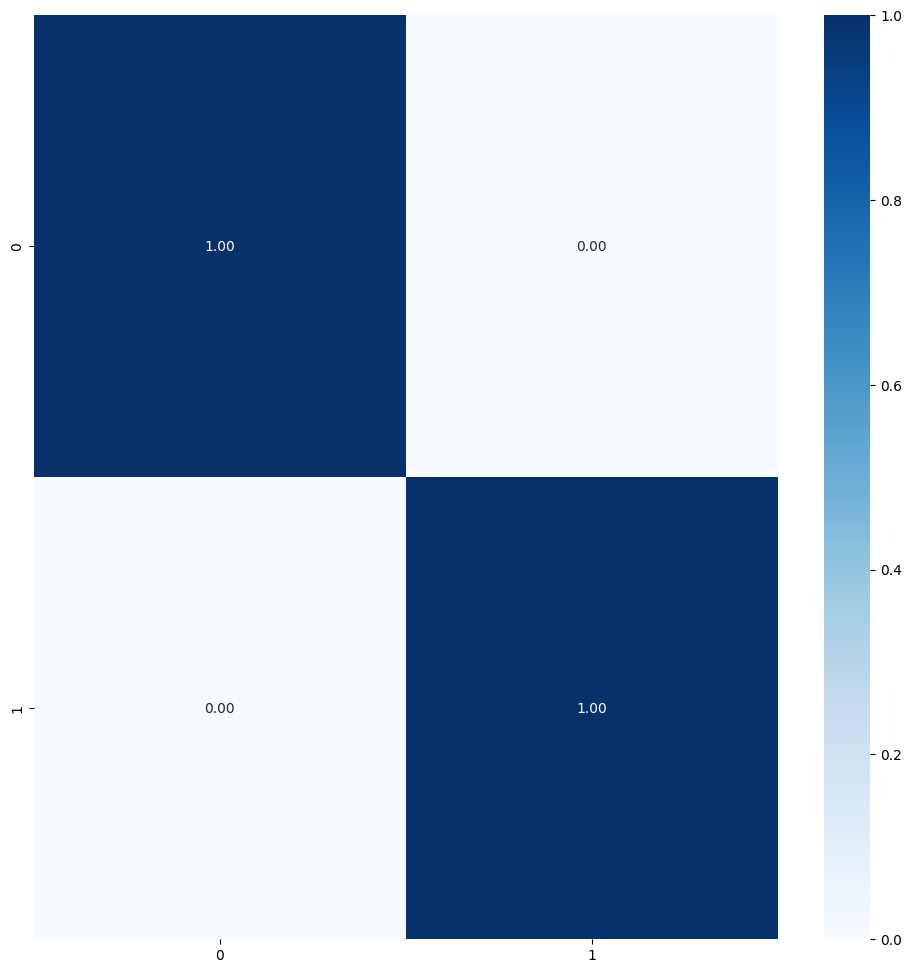


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3821634
Trainable params: 1644418
Non-trainable params: 2177216
Epoch 1/50
65/65 [==============================] - 21s 184ms/step - loss: 0.9280 - accuracy: 0.9855 - val_loss: 0.9749 - val_accuracy: 0.9955
Epoch 2/50
65/65 [==============================] - 9s 144ms/step - loss: 0.8599 - accuracy: 0.9976 - val_loss: 0.8830 - val_accuracy: 0.9978
Epoch 3/50
65/65 [==============================] - 11s 160ms/step - loss: 0.8353 - accuracy: 0.9995 - val_loss: 0.8304 - val_accuracy: 0.9978
Epoch 4/50
65/65 [==============================] - 10s 154ms/step - loss: 0.8117 - accuracy: 1.0000 - val_loss: 0.8023 - val_accuracy: 1.0000
Epoch 5/50
65/65 [==============================] - 9s 144ms/step - loss: 0.7925 - accuracy: 0.9990 - val_loss: 0.7774 - val_accuracy: 1.0000
Epoch 6/50
65/65 [==============================] - 10s 159ms/step - loss: 0.7671 - accuracy: 1.0000 - val_loss: 0.7550 - val_accuracy: 1.0000
Epoch 7/50
65/65 [==========

History for fold 2 saved...
66/66 [==============================] - 8s 120ms/step - loss: 0.0918 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.09180198609828949
15/15 [==============================] - 2s 113ms/step - loss: 0.0918 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.09181546419858932
15/15 [==============================] - 2s 110ms/step - loss: 0.0918 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.09180230647325516
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [============================

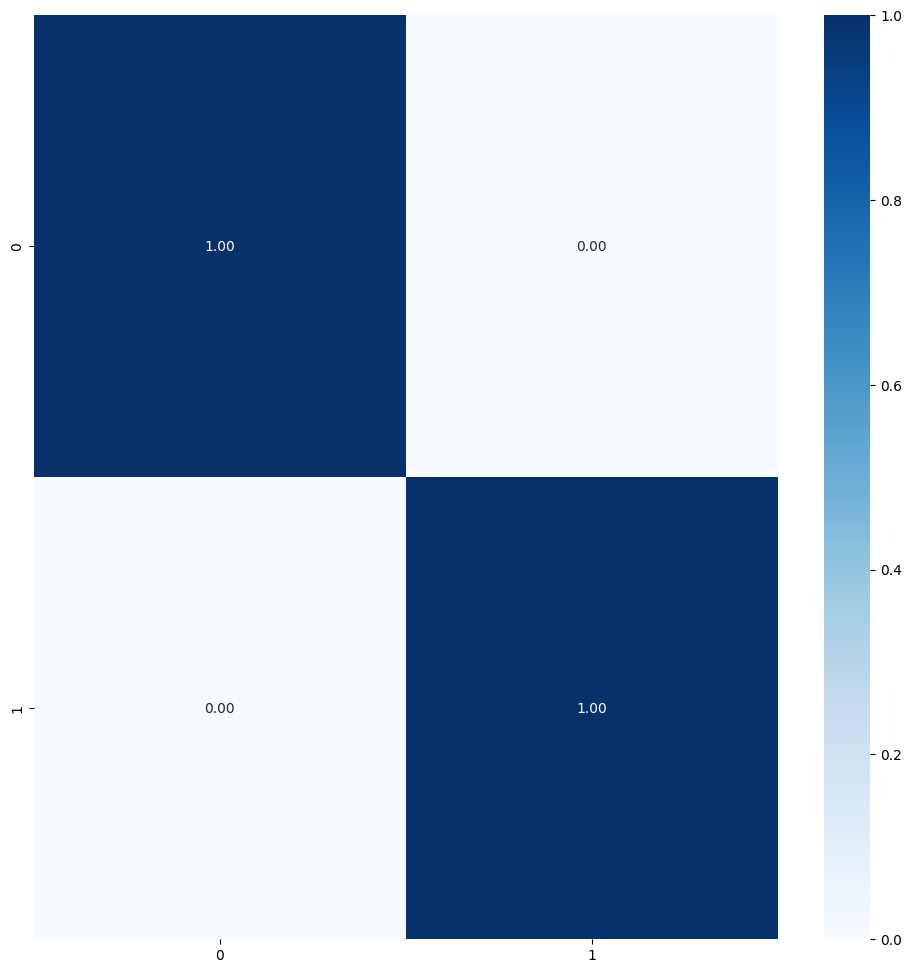


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3821634
Trainable params: 1644418
Non-trainable params: 2177216
Epoch 1/50
65/65 [==============================] - 21s 180ms/step - loss: 0.9706 - accuracy: 0.9681 - val_loss: 1.0600 - val_accuracy: 0.9911
Epoch 2/50
65/65 [==============================] - 9s 142ms/step - loss: 0.8733 - accuracy: 0.9956 - val_loss: 0.9112 - val_accuracy: 0.9955
Epoch 3/50
65/65 [==============================] - 10s 155ms/step - loss: 0.8517 - accuracy: 0.9990 - val_loss: 0.8583 - val_accuracy: 0.9955
Epoch 4/50
65/65 [==============================] - 10s 153ms/step - loss: 0.8315 - accuracy: 1.0000 - val_loss: 0.8303 - val_accuracy: 0.9955
Epoch 5/50
65/65 [==============================] - 10s 148ms/step - loss: 0.8142 - accuracy: 1.0000 - val_loss: 0.8046 - val_accuracy: 1.0000
Epoch 6/50
65/65 [==============================] - 10s 155ms/step - loss: 0.7962 - accuracy: 0.9995 - val_loss: 0.7861 - val_accuracy: 1.0000
Epoch 7/50
65/65 [=========

History for fold 3 saved...
66/66 [==============================] - 9s 113ms/step - loss: 0.1275 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.127535879611969
15/15 [==============================] - 2s 96ms/step - loss: 0.1275 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.1275479942560196
15/15 [==============================] - 2s 112ms/step - loss: 0.1275 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.127535879611969
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [==============================] - 

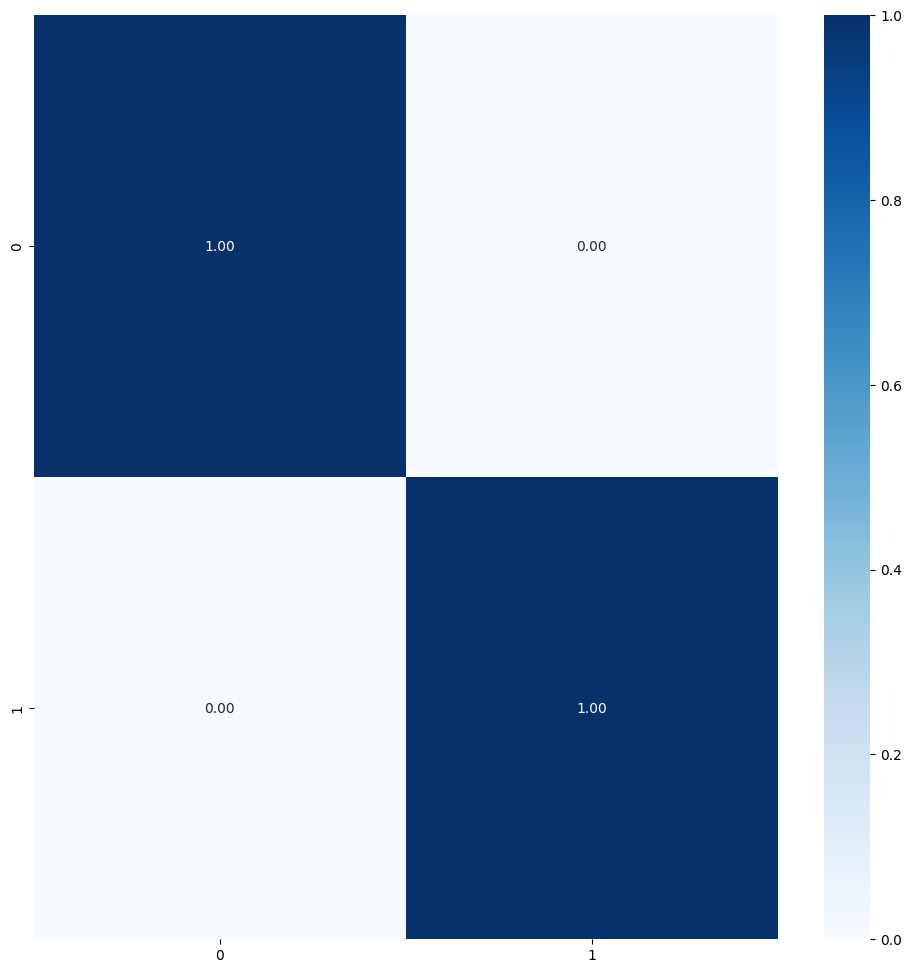


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3821634
Trainable params: 1644418
Non-trainable params: 2177216
Epoch 1/50
65/65 [==============================] - 23s 205ms/step - loss: 0.9635 - accuracy: 0.9700 - val_loss: 1.1063 - val_accuracy: 0.9531
Epoch 2/50
65/65 [==============================] - 12s 175ms/step - loss: 0.8705 - accuracy: 0.9981 - val_loss: 0.8866 - val_accuracy: 0.9978
Epoch 3/50
65/65 [==============================] - 8s 125ms/step - loss: 0.8508 - accuracy: 1.0000 - val_loss: 0.8450 - val_accuracy: 0.9978
Epoch 4/50
65/65 [==============================] - 10s 160ms/step - loss: 0.8327 - accuracy: 0.9995 - val_loss: 0.8245 - val_accuracy: 0.9978
Epoch 5/50
65/65 [==============================] - 8s 117ms/step - loss: 0.8139 - accuracy: 1.0000 - val_loss: 0.8045 - val_accuracy: 1.0000
Epoch 6/50
65/65 [==============================] - 5s 73ms/step - loss: 0.7963 - accuracy: 0.9990 - val_loss: 0.7848 - val_accuracy: 1.0000
Epoch 7/50
65/65 [============

History for fold 4 saved...
66/66 [==============================] - 10s 142ms/step - loss: 0.1077 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.10770012438297272
15/15 [==============================] - 3s 129ms/step - loss: 0.1077 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.10770478844642639
15/15 [==============================] - 3s 142ms/step - loss: 0.1077 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.10770060867071152
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [===========================

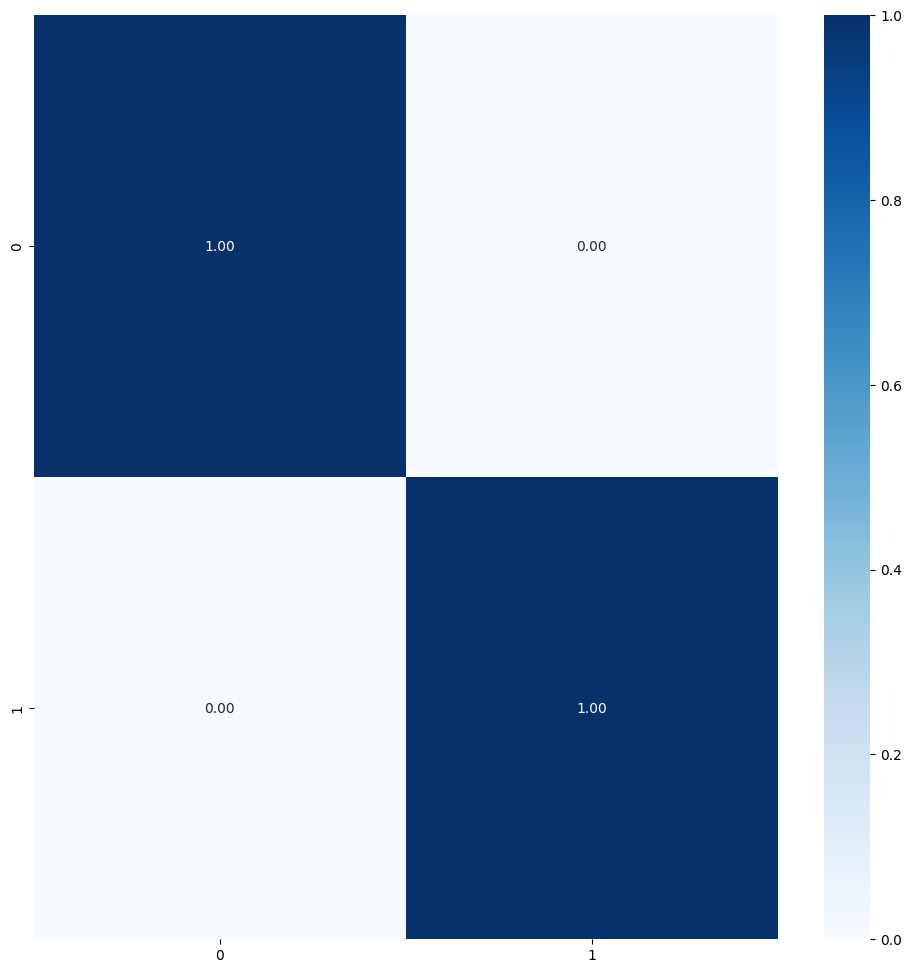


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3821634
Trainable params: 1644418
Non-trainable params: 2177216
Epoch 1/50
65/65 [==============================] - 26s 220ms/step - loss: 0.9262 - accuracy: 0.9836 - val_loss: 0.9802 - val_accuracy: 0.9955
Epoch 2/50
65/65 [==============================] - 13s 203ms/step - loss: 0.8723 - accuracy: 0.9981 - val_loss: 0.8789 - val_accuracy: 1.0000
Epoch 3/50
65/65 [==============================] - 12s 176ms/step - loss: 0.8503 - accuracy: 0.9985 - val_loss: 0.8385 - val_accuracy: 1.0000
Epoch 4/50
65/65 [==============================] - 13s 194ms/step - loss: 0.8263 - accuracy: 1.0000 - val_loss: 0.8155 - val_accuracy: 1.0000
Epoch 5/50
65/65 [==============================] - 13s 198ms/step - loss: 0.8056 - accuracy: 0.9995 - val_loss: 0.7929 - val_accuracy: 1.0000
Epoch 6/50
65/65 [==============================] - 13s 195ms/step - loss: 0.7819 - accuracy: 1.0000 - val_loss: 0.7702 - val_accuracy: 1.0000
Epoch 7/50
65/65 [========

History for fold 5 saved...
66/66 [==============================] - 8s 110ms/step - loss: 0.0836 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.08360318839550018
15/15 [==============================] - 2s 102ms/step - loss: 0.0836 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.08361638337373734
15/15 [==============================] - 2s 109ms/step - loss: 0.0836 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.08360462635755539
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [============================

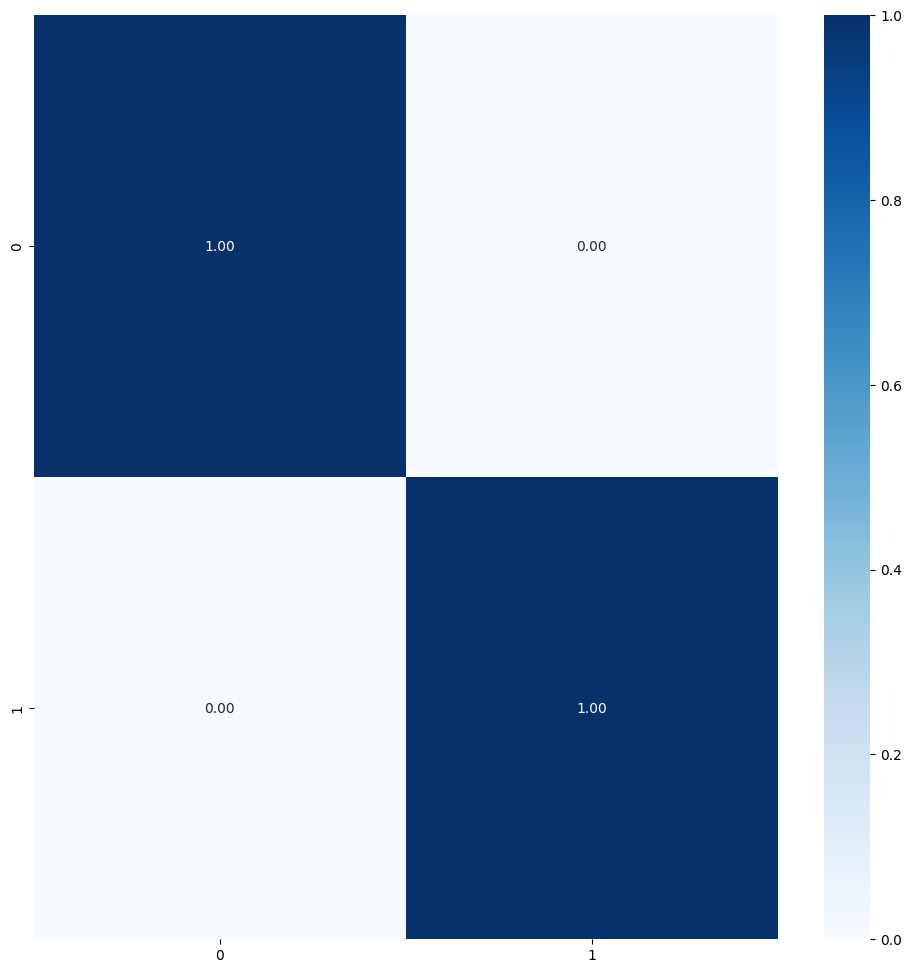


Best fold was 1 with val_accuracy: 1.0000
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 1.0

Test Metrics
test_acc_list: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Test Accuracy with 5-fold: 1.0
test_loss_list: [0.10119875520467758, 0.09180230647325516, 0.127535879611969, 0.10770060867071152, 0.08360462635755539]
Average Test Log Loss with 5-fold: 0.10236843526363373

Precision List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Precision List with 5-fold: 1.0
Recall List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Recall List with 5-fold: 1.0
F1 Score List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average F1 Score List with 5-fold: 1.0

Metrics List Store

test_acc_list_all = [1.0]
test_loss_list_all = [0.10236843526363373]
precision_list_all = [1.0]
recall_list_all = [1.0]
f1_score_list_all = [1.0]
La carpeta 2 fue eliminada.
CPU times: user 49min 3s, sys: 4min 55s, total: 53min 59s
Wall time: 48min 17s


In [17]:
%%time
###################################### Probar Dropout 0.4
num_classes = 2
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/3
name_save_model: MobileNet_tf_15003
Found 3150 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3821763
Trainable params: 1644547
Non-trainable params: 2177216
Epoch 1/50
98/98 [==============================] - 29s 183ms/step - loss: 0.9759 - accuracy: 0.9734 - val_loss: 0.9940 - val_accuracy: 0.9940
Epoch 2/50
98/98 [==============================] - 17s 171ms/step - loss: 0.8735 - accuracy: 0.9978 - val_loss: 0.8724 - val_accuracy: 0.9970
Epoch 3/50
98/98 [==============================] - 14s 141ms/step - loss: 0.8511 - accuracy: 0.9987 - val_loss: 0.8458 - val_accuracy: 0.9970
Epoch 4/50
98/98 [==============================] - 9s 96ms/step - loss: 0.8293 - accuracy: 0.9990 - val_loss: 0.8238 - val_accuracy: 0.9985
Epoch 5/

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
99/99 [==============================] - 12s 121ms/step - loss: 0.0315 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.031549688428640366
22/22 [==============================] - 3s 117ms/step - loss: 0.0366 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.03655455633997917
22/22 [==============================] - 3s 123ms/step - loss: 0.0316 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.031551238149404526
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00

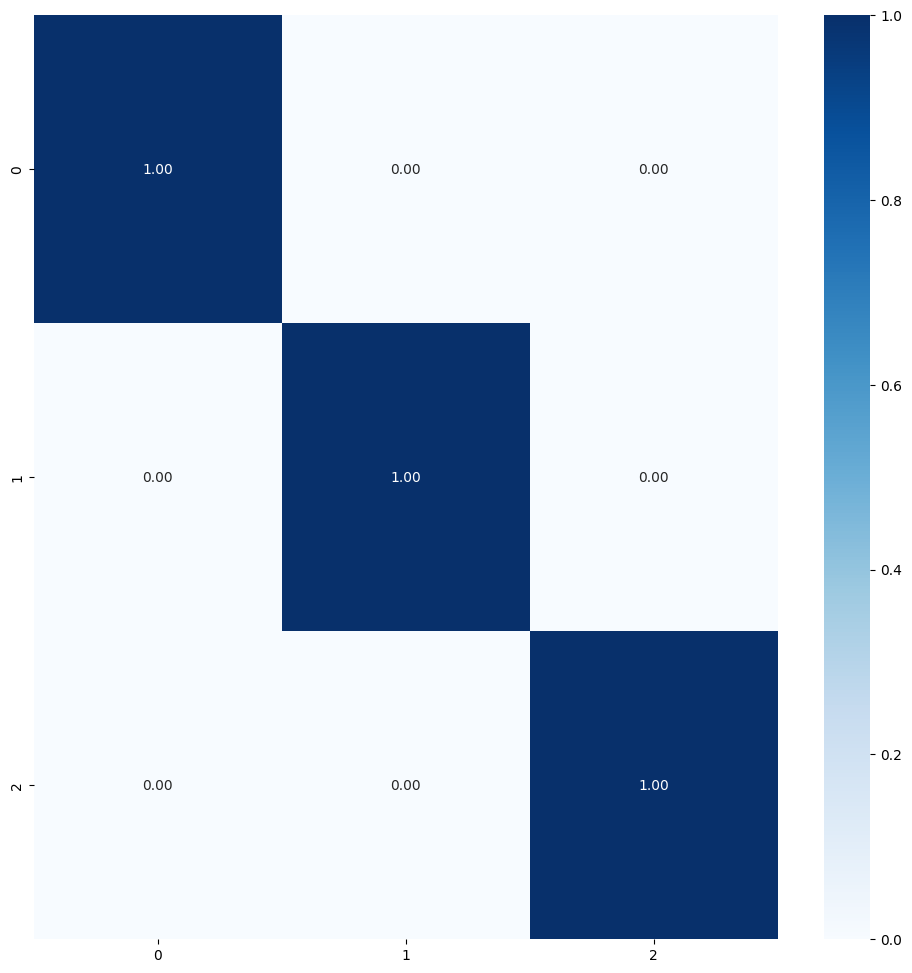


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3821763
Trainable params: 1644547
Non-trainable params: 2177216
Epoch 1/50
98/98 [==============================] - 28s 192ms/step - loss: 0.9860 - accuracy: 0.9644 - val_loss: 0.9533 - val_accuracy: 0.9955
Epoch 2/50
98/98 [==============================] - 14s 147ms/step - loss: 0.8736 - accuracy: 0.9984 - val_loss: 0.8679 - val_accuracy: 0.9985
Epoch 3/50
98/98 [==============================] - 15s 149ms/step - loss: 0.8532 - accuracy: 0.9990 - val_loss: 0.8441 - val_accuracy: 0.9985
Epoch 4/50
98/98 [==============================] - 15s 150ms/step - loss: 0.8317 - accuracy: 0.9994 - val_loss: 0.8262 - val_accuracy: 0.9985
Epoch 5/50
98/98 [==============================] - 18s 186ms/step - loss: 0.8107 - accuracy: 0.9994 - val_loss: 0.8047 - val_accuracy: 0.9985
Epoch 6/50
98/98 [==============================] - 14s 144ms/step - loss: 0.7885 - accuracy: 0.9997 - val_loss: 0.7782 - val_accuracy: 0.9985
Epoch 7/50
98/98 [========

History for fold 2 saved...
99/99 [==============================] - 13s 126ms/step - loss: 0.0366 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.036589231342077255
22/22 [==============================] - 3s 117ms/step - loss: 0.0413 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.04129699617624283
22/22 [==============================] - 3s 118ms/step - loss: 0.0366 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.03658967837691307
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00 

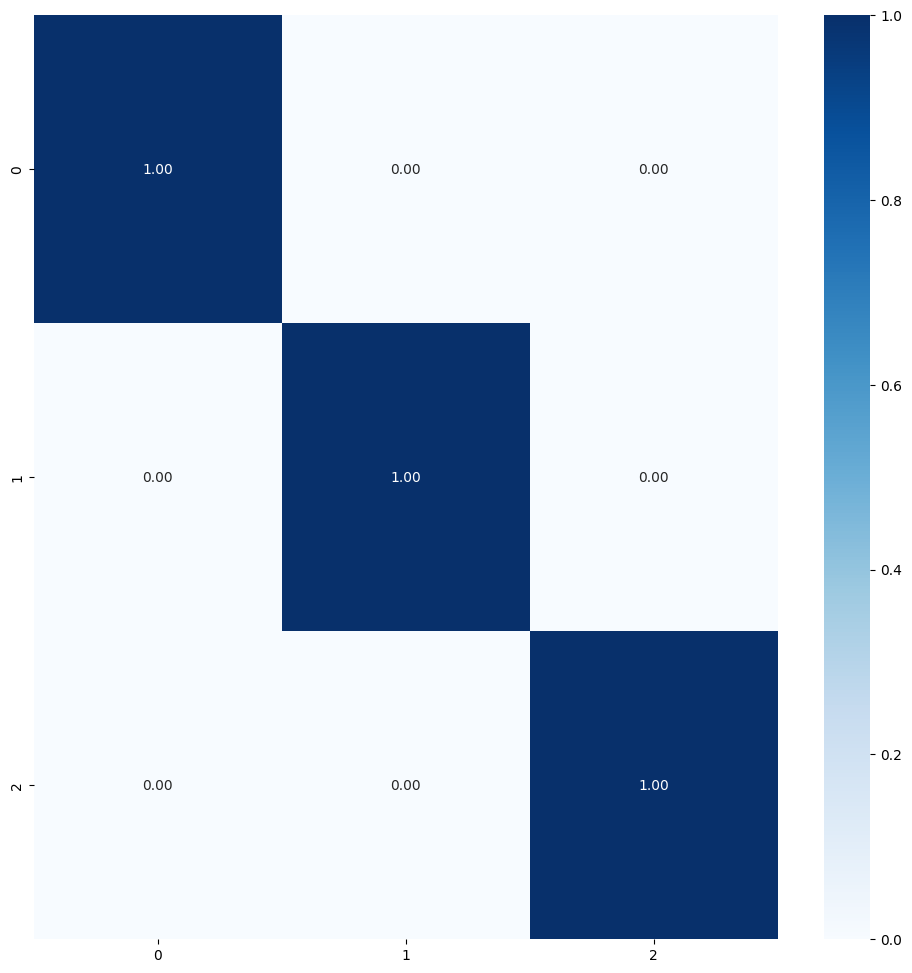


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3821763
Trainable params: 1644547
Non-trainable params: 2177216
Epoch 1/50
98/98 [==============================] - 26s 173ms/step - loss: 0.9700 - accuracy: 0.9666 - val_loss: 0.9460 - val_accuracy: 0.9940
Epoch 2/50
98/98 [==============================] - 14s 144ms/step - loss: 0.8750 - accuracy: 0.9974 - val_loss: 0.8684 - val_accuracy: 0.9985
Epoch 3/50
98/98 [==============================] - 15s 144ms/step - loss: 0.8518 - accuracy: 0.9990 - val_loss: 0.8478 - val_accuracy: 0.9985
Epoch 4/50
98/98 [==============================] - 15s 148ms/step - loss: 0.8318 - accuracy: 0.9994 - val_loss: 0.8269 - val_accuracy: 0.9985
Epoch 5/50
98/98 [==============================] - 15s 148ms/step - loss: 0.8113 - accuracy: 0.9984 - val_loss: 0.8017 - val_accuracy: 0.9985
Epoch 6/50
98/98 [==============================] - 15s 149ms/step - loss: 0.7884 - accuracy: 1.0000 - val_loss: 0.7799 - val_accuracy: 0.9985
Epoch 7/50
98/98 [========

History for fold 3 saved...
99/99 [==============================] - 12s 119ms/step - loss: 0.0302 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.030219482257962227
22/22 [==============================] - 3s 122ms/step - loss: 0.0321 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.032100144773721695
22/22 [==============================] - 3s 117ms/step - loss: 0.0302 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.03022165410220623
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00

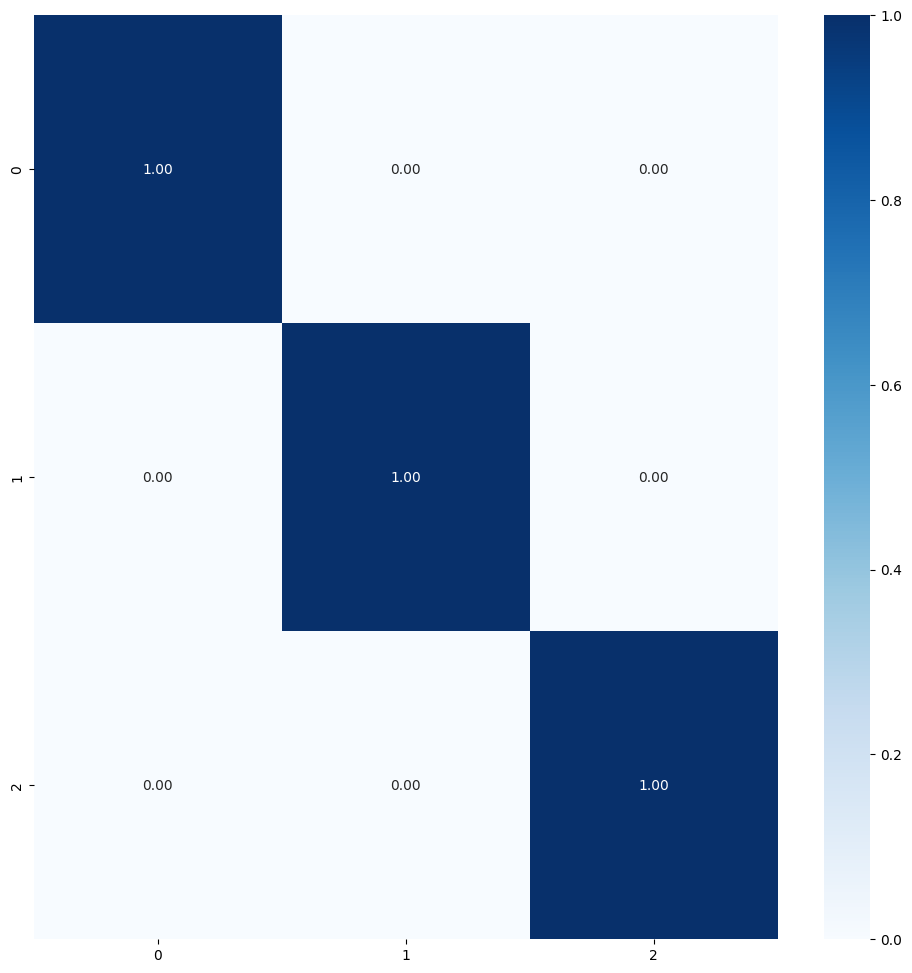


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3821763
Trainable params: 1644547
Non-trainable params: 2177216
Epoch 1/50
98/98 [==============================] - 28s 184ms/step - loss: 0.9912 - accuracy: 0.9641 - val_loss: 0.9780 - val_accuracy: 0.9955
Epoch 2/50
98/98 [==============================] - 16s 158ms/step - loss: 0.8744 - accuracy: 0.9981 - val_loss: 0.8722 - val_accuracy: 0.9985
Epoch 3/50
98/98 [==============================] - 14s 138ms/step - loss: 0.8555 - accuracy: 0.9987 - val_loss: 0.8472 - val_accuracy: 0.9985
Epoch 4/50
98/98 [==============================] - 11s 117ms/step - loss: 0.8319 - accuracy: 1.0000 - val_loss: 0.8268 - val_accuracy: 0.9985
Epoch 5/50
98/98 [==============================] - 8s 75ms/step - loss: 0.8100 - accuracy: 1.0000 - val_loss: 0.8043 - val_accuracy: 0.9985
Epoch 6/50
98/98 [==============================] - 14s 143ms/step - loss: 0.7874 - accuracy: 0.9997 - val_loss: 0.7820 - val_accuracy: 0.9985
Epoch 7/50
98/98 [==========

History for fold 4 saved...
99/99 [==============================] - 13s 122ms/step - loss: 0.0319 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.031910113990306854
22/22 [==============================] - 3s 109ms/step - loss: 0.0370 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.03701973706483841
22/22 [==============================] - 3s 115ms/step - loss: 0.0319 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0319112129509449
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00  

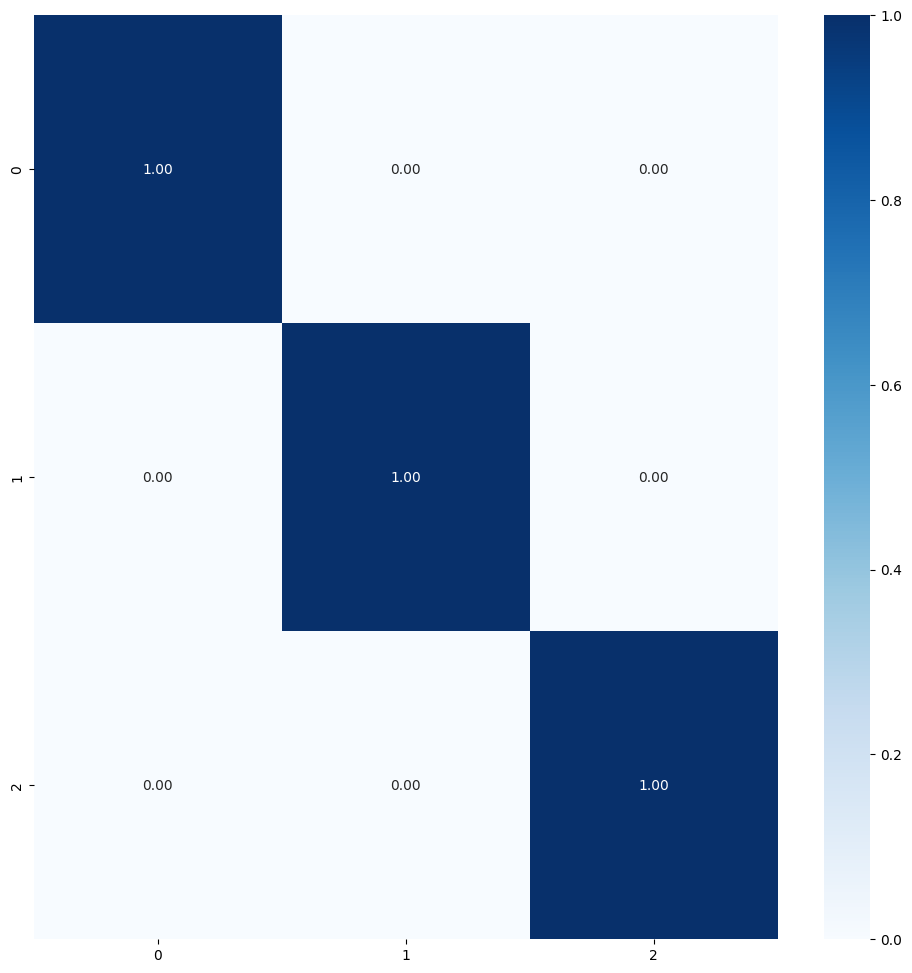


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3821763
Trainable params: 1644547
Non-trainable params: 2177216
Epoch 1/50
98/98 [==============================] - 26s 173ms/step - loss: 0.9509 - accuracy: 0.9731 - val_loss: 0.9659 - val_accuracy: 0.9926
Epoch 2/50
98/98 [==============================] - 15s 153ms/step - loss: 0.8676 - accuracy: 0.9994 - val_loss: 0.8687 - val_accuracy: 0.9970
Epoch 3/50
98/98 [==============================] - 15s 150ms/step - loss: 0.8466 - accuracy: 0.9994 - val_loss: 0.8376 - val_accuracy: 0.9985
Epoch 4/50
98/98 [==============================] - 15s 149ms/step - loss: 0.8271 - accuracy: 0.9981 - val_loss: 0.8134 - val_accuracy: 0.9985
Epoch 5/50
98/98 [==============================] - 15s 150ms/step - loss: 0.7995 - accuracy: 1.0000 - val_loss: 0.7907 - val_accuracy: 0.9985
Epoch 6/50
98/98 [==============================] - 15s 153ms/step - loss: 0.7749 - accuracy: 1.0000 - val_loss: 0.7652 - val_accuracy: 0.9985
Epoch 7/50
98/98 [========

History for fold 5 saved...
99/99 [==============================] - 13s 124ms/step - loss: 0.0369 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.03692454844713211
22/22 [==============================] - 3s 113ms/step - loss: 0.0386 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.038617976009845734
22/22 [==============================] - 3s 123ms/step - loss: 0.0369 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.036924246698617935
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00

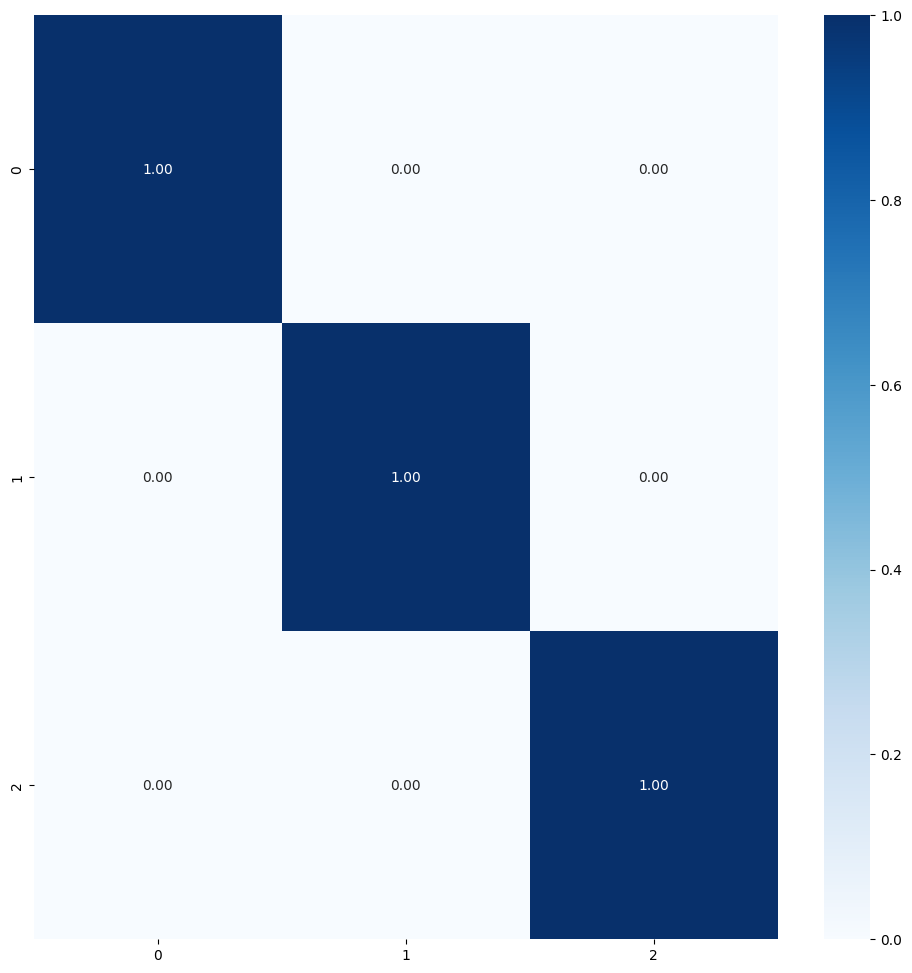


Best fold was 1 with val_accuracy: 1.0000
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 1.0

Test Metrics
test_acc_list: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Test Accuracy with 5-fold: 1.0
test_loss_list: [0.031551238149404526, 0.03658967837691307, 0.03022165410220623, 0.0319112129509449, 0.036924246698617935]
Average Test Log Loss with 5-fold: 0.033439606055617334

Precision List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Precision List with 5-fold: 1.0
Recall List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Recall List with 5-fold: 1.0
F1 Score List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average F1 Score List with 5-fold: 1.0

Metrics List Store

test_acc_list_all = [1.0, 1.0]
test_loss_list_all = [0.10236843526363373, 0.033439606055617334]
precision_list_all = [1.0, 1.0]
recall_list_all = [1.0, 1.0]
f1_score_list_all = [1.0, 1.0]
La carpeta 3 fue eliminada.
CPU times: user 1h 12min 8s, sys: 6min 33s, total: 1h 18min 41s
Wall time: 1h 12min 17s


In [18]:
%%time

num_classes = 3
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/4
name_save_model: MobileNet_tf_15004
Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3821892
Trainable params: 1644676
Non-trainable params: 2177216
Epoch 1/50
131/131 [==============================] - 33s 177ms/step - loss: 1.0350 - accuracy: 0.9520 - val_loss: 0.9690 - val_accuracy: 0.9888
Epoch 2/50
131/131 [==============================] - 21s 160ms/step - loss: 0.8944 - accuracy: 0.9950 - val_loss: 0.8825 - val_accuracy: 0.9933
Epoch 3/50
131/131 [==============================] - 22s 160ms/step - loss: 0.8664 - accuracy: 0.9962 - val_loss: 0.8594 - val_accuracy: 0.9944
Epoch 4/50
131/131 [==============================] - 20s 153ms/step - loss: 0.8464 - accuracy: 0.9966 - val_loss: 0.8415 - val_accura

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
132/132 [==============================] - 17s 124ms/step - loss: 0.0185 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.018511764705181122
29/29 [==============================] - 4s 121ms/step - loss: 0.0424 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.04238014668226242
29/29 [==============================] - 5s 122ms/step - loss: 0.0372 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.037213392555713654
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00      1.00       225
           3       1.00     

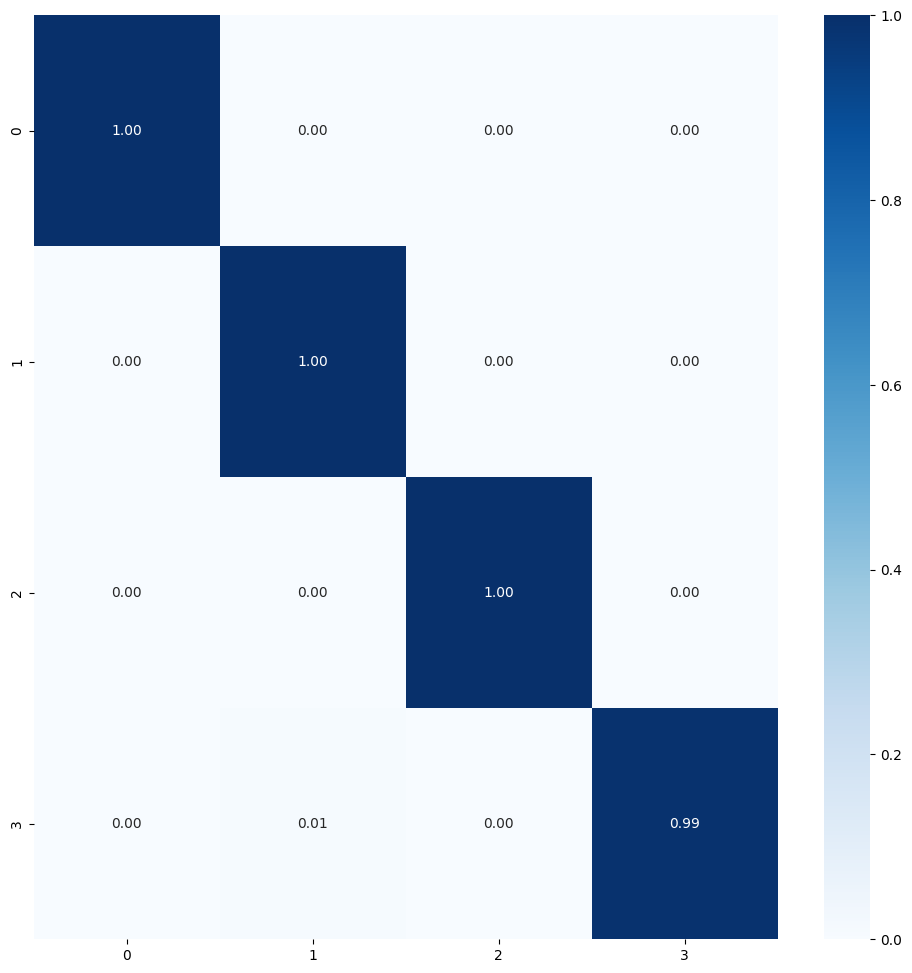


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3821892
Trainable params: 1644676
Non-trainable params: 2177216
Epoch 1/50
131/131 [==============================] - 34s 183ms/step - loss: 1.0183 - accuracy: 0.9571 - val_loss: 0.9454 - val_accuracy: 0.9855
Epoch 2/50
131/131 [==============================] - 22s 169ms/step - loss: 0.8887 - accuracy: 0.9930 - val_loss: 0.8779 - val_accuracy: 0.9944
Epoch 3/50
131/131 [==============================] - 20s 156ms/step - loss: 0.8597 - accuracy: 0.9969 - val_loss: 0.8563 - val_accuracy: 0.9955
Epoch 4/50
131/131 [==============================] - 20s 152ms/step - loss: 0.8376 - accuracy: 0.9983 - val_loss: 0.8352 - val_accuracy: 0.9967
Epoch 5/50
131/131 [==============================] - 20s 149ms/step - loss: 0.8162 - accuracy: 0.9981 - val_loss: 0.8114 - val_accuracy: 0.9967
Epoch 6/50
131/131 [==============================] - 21s 154ms/step - loss: 0.7909 - accuracy: 0.9986 - val_loss: 0.7865 - val_accuracy: 0.9967
Epoch 7/50
131

History for fold 2 saved...
132/132 [==============================] - 16s 122ms/step - loss: 0.0241 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.02405925840139389
29/29 [==============================] - 4s 119ms/step - loss: 0.0449 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.04487239569425583
29/29 [==============================] - 4s 118ms/step - loss: 0.0336 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.03357721492648125
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00      1.00       225
           3       1.00      0

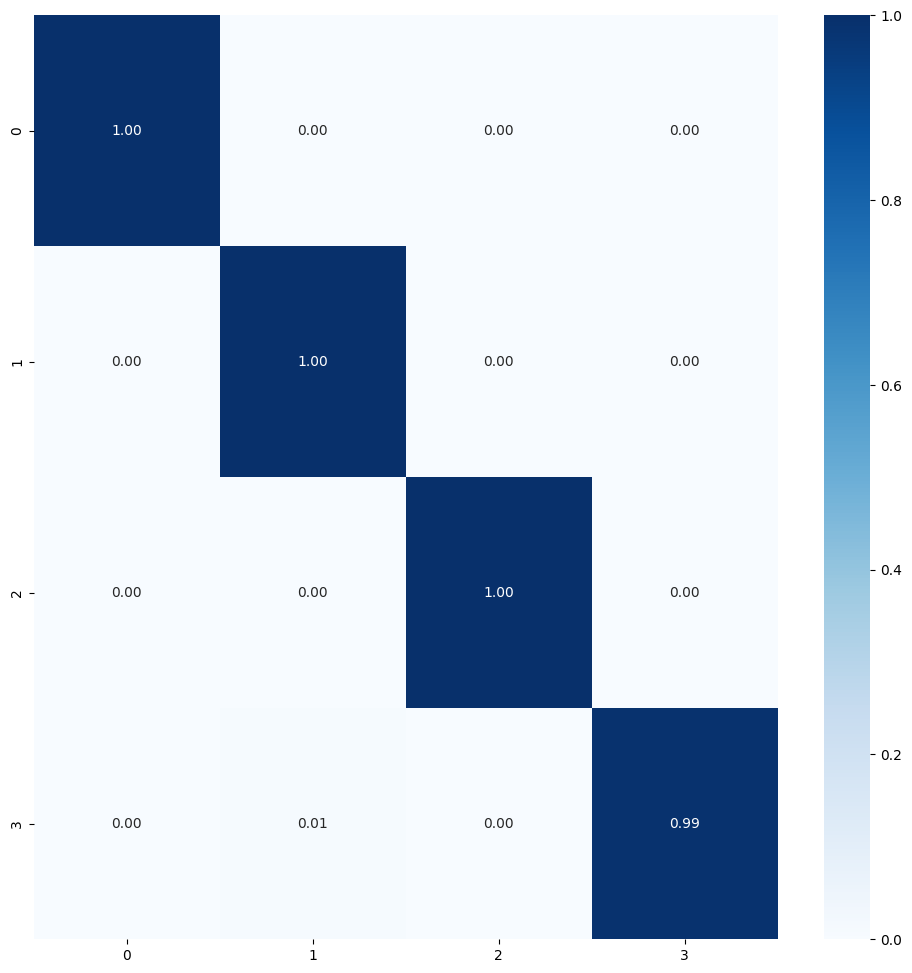


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3821892
Trainable params: 1644676
Non-trainable params: 2177216
Epoch 1/50
131/131 [==============================] - 34s 179ms/step - loss: 1.0479 - accuracy: 0.9472 - val_loss: 0.9583 - val_accuracy: 0.9877
Epoch 2/50
131/131 [==============================] - 21s 157ms/step - loss: 0.8932 - accuracy: 0.9954 - val_loss: 0.8811 - val_accuracy: 0.9955
Epoch 3/50
131/131 [==============================] - 20s 151ms/step - loss: 0.8657 - accuracy: 0.9959 - val_loss: 0.8579 - val_accuracy: 0.9967
Epoch 4/50
131/131 [==============================] - 20s 153ms/step - loss: 0.8431 - accuracy: 0.9978 - val_loss: 0.8373 - val_accuracy: 0.9967
Epoch 5/50
131/131 [==============================] - 21s 163ms/step - loss: 0.8173 - accuracy: 0.9998 - val_loss: 0.8183 - val_accuracy: 0.9967
Epoch 6/50
131/131 [==============================] - 21s 158ms/step - loss: 0.7967 - accuracy: 0.9990 - val_loss: 0.7970 - val_accuracy: 0.9967
Epoch 7/50
131

History for fold 3 saved...
132/132 [==============================] - 17s 124ms/step - loss: 0.0328 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.03275500237941742
29/29 [==============================] - 4s 119ms/step - loss: 0.0574 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.05735039338469505
29/29 [==============================] - 4s 117ms/step - loss: 0.0578 - accuracy: 0.9967
Test Accuracy: 0.996666669845581
Test Log Loss: 0.057776328176259995
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 224   0   1]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00      1.00      1.00       225
           3       1.00      0

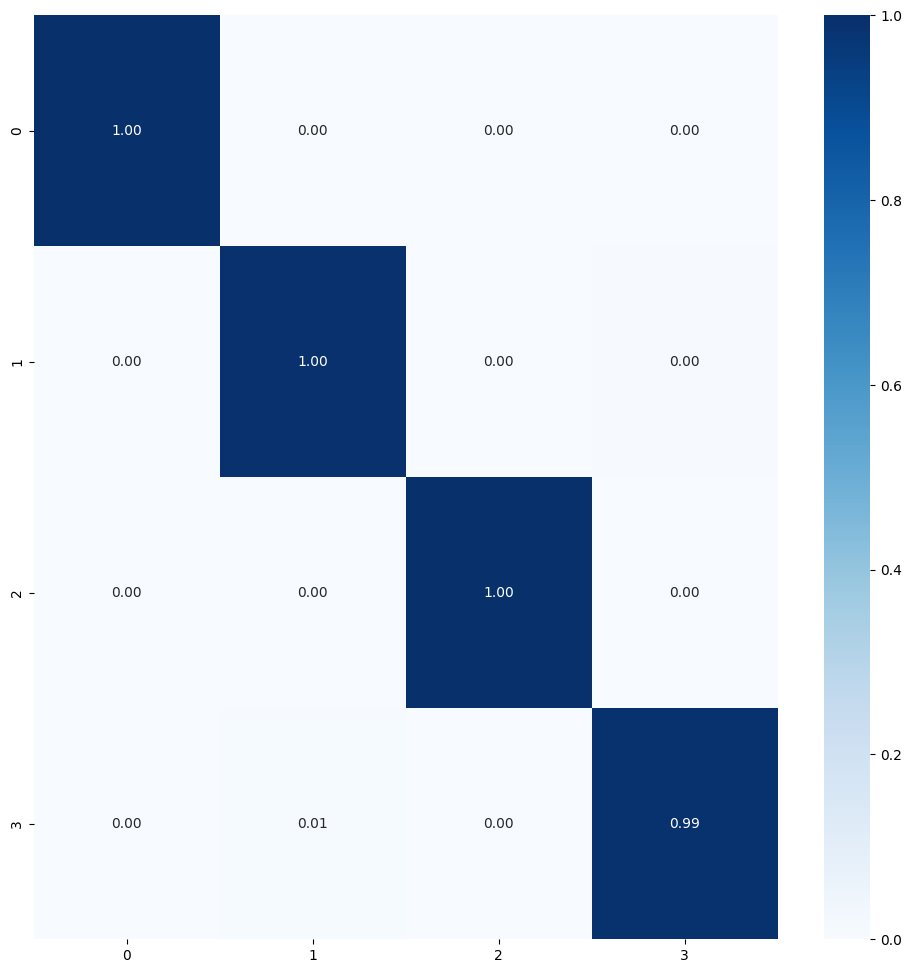


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3821892
Trainable params: 1644676
Non-trainable params: 2177216
Epoch 1/50
131/131 [==============================] - 31s 165ms/step - loss: 1.0593 - accuracy: 0.9448 - val_loss: 0.9817 - val_accuracy: 0.9777
Epoch 2/50
131/131 [==============================] - 20s 152ms/step - loss: 0.8991 - accuracy: 0.9930 - val_loss: 0.8862 - val_accuracy: 0.9944
Epoch 3/50
131/131 [==============================] - 21s 156ms/step - loss: 0.8671 - accuracy: 0.9971 - val_loss: 0.8634 - val_accuracy: 0.9967
Epoch 4/50
131/131 [==============================] - 21s 161ms/step - loss: 0.8463 - accuracy: 0.9981 - val_loss: 0.8494 - val_accuracy: 0.9967
Epoch 5/50
131/131 [==============================] - 20s 149ms/step - loss: 0.8266 - accuracy: 0.9978 - val_loss: 0.8281 - val_accuracy: 0.9967
Epoch 6/50
131/131 [==============================] - 22s 163ms/step - loss: 0.8022 - accuracy: 0.9998 - val_loss: 0.8112 - val_accuracy: 0.9967
Epoch 7/50
131

History for fold 4 saved...
132/132 [==============================] - 16s 121ms/step - loss: 0.0342 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.03421982377767563
29/29 [==============================] - 4s 120ms/step - loss: 0.0572 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.05722811073064804
29/29 [==============================] - 5s 118ms/step - loss: 0.0574 - accuracy: 0.9967
Test Accuracy: 0.996666669845581
Test Log Loss: 0.057442713528871536
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 224   0   1]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00      1.00      1.00       225
           3       1.00      0

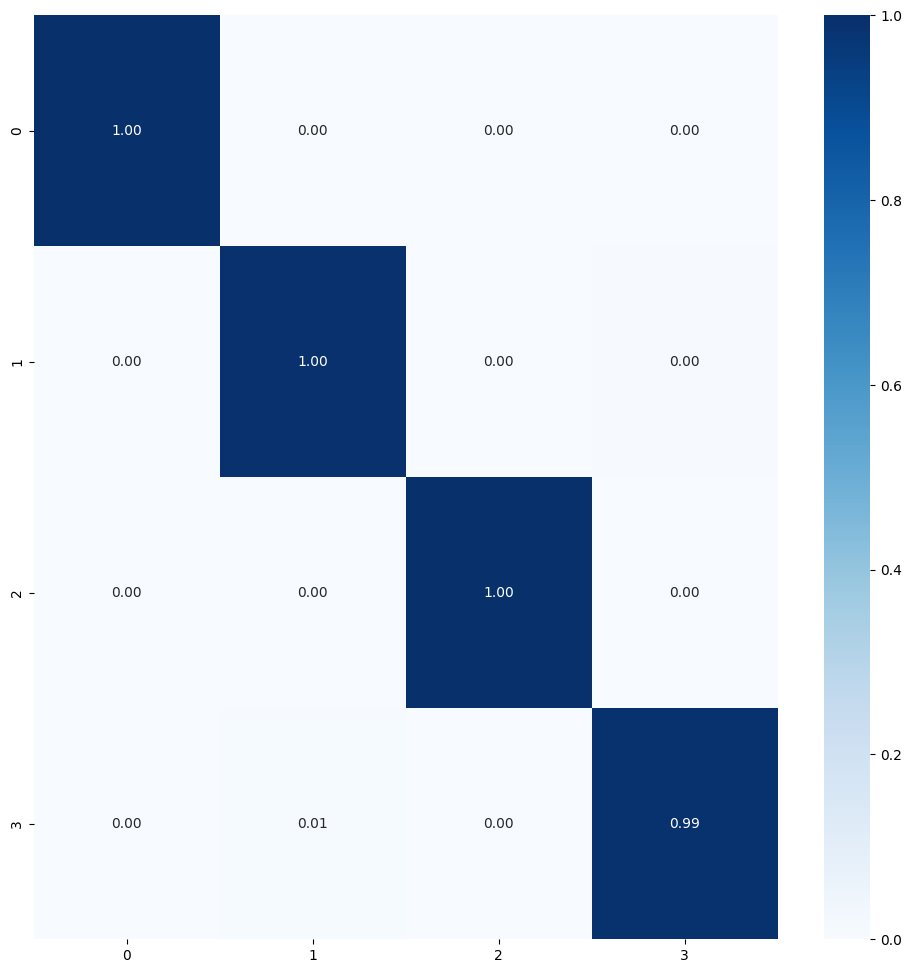


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3821892
Trainable params: 1644676
Non-trainable params: 2177216
Epoch 1/50
131/131 [==============================] - 33s 168ms/step - loss: 1.0650 - accuracy: 0.9417 - val_loss: 0.9569 - val_accuracy: 0.9900
Epoch 2/50
131/131 [==============================] - 20s 148ms/step - loss: 0.8994 - accuracy: 0.9923 - val_loss: 0.8824 - val_accuracy: 0.9944
Epoch 3/50
131/131 [==============================] - 20s 149ms/step - loss: 0.8715 - accuracy: 0.9950 - val_loss: 0.8611 - val_accuracy: 0.9967
Epoch 4/50
131/131 [==============================] - 21s 155ms/step - loss: 0.8474 - accuracy: 0.9978 - val_loss: 0.8458 - val_accuracy: 0.9967
Epoch 5/50
131/131 [==============================] - 19s 147ms/step - loss: 0.8253 - accuracy: 0.9988 - val_loss: 0.8241 - val_accuracy: 0.9967
Epoch 6/50
131/131 [==============================] - 21s 158ms/step - loss: 0.8019 - accuracy: 0.9993 - val_loss: 0.8015 - val_accuracy: 0.9967
Epoch 7/50
131

History for fold 5 saved...
132/132 [==============================] - 17s 125ms/step - loss: 0.0286 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.02856147289276123
29/29 [==============================] - 4s 117ms/step - loss: 0.0629 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.06287075579166412
29/29 [==============================] - 5s 121ms/step - loss: 0.0566 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.0566401369869709
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00      1.00       225
           3       1.00      0.

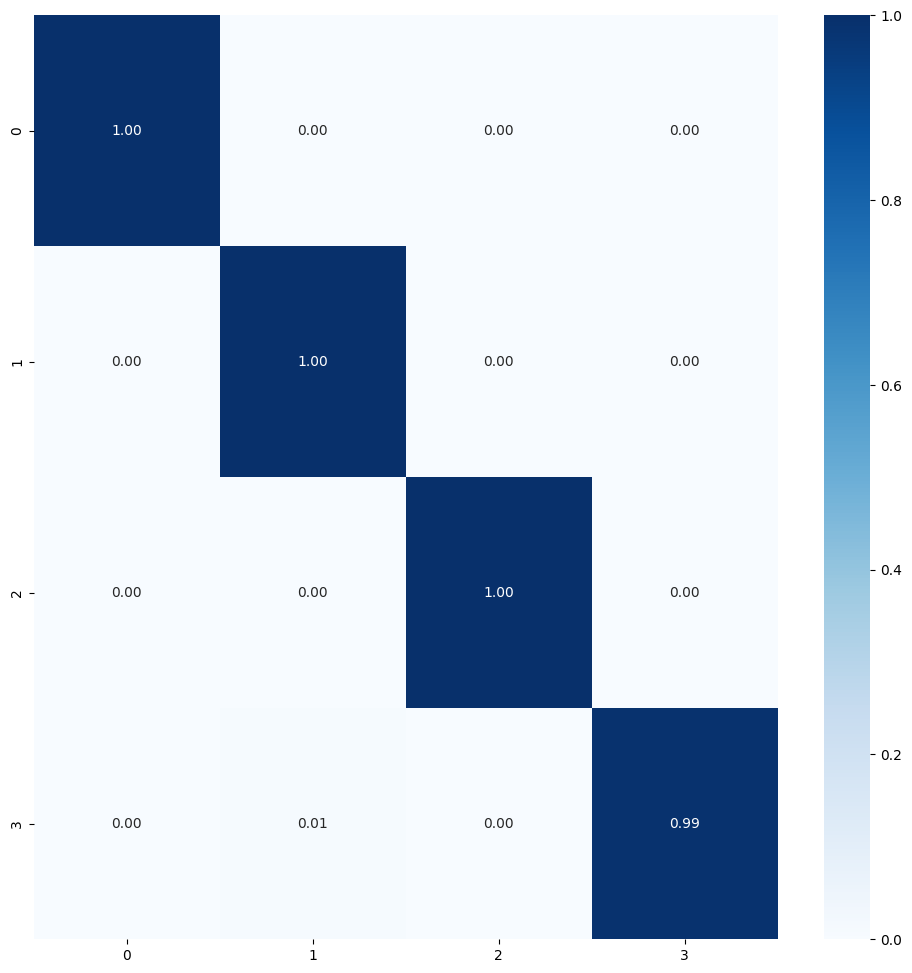


Best fold was 1 with val_accuracy: 0.9978
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9977678656578064

Test Metrics
test_acc_list: [0.9977777600288391, 0.9977777600288391, 0.996666669845581, 0.996666669845581, 0.9977777600288391]
Average Test Accuracy with 5-fold: 0.9973333239555359
test_loss_list: [0.037213392555713654, 0.03357721492648125, 0.057776328176259995, 0.057442713528871536, 0.0566401369869709]
Average Test Log Loss with 5-fold: 0.048529957234859464

Precision List: [0.9977973568281938, 0.9977973568281938, 0.9966715391908976, 0.9966715391908976, 0.9977973568281938]
Average Precision List with 5-fold: 0.9973470297732753
Recall List: [0.9977777777777778, 0.9977777777777778, 0.9966666666666667, 0.9966666666666667, 0.9977777777777778]
Average Recall List with 5-fold: 0.9973333333333333
F1 Score List: [0.9977777338811631, 0.9977777338811631, 0.99666665020568, 0.99666665020568, 0.9977777338811631]
Average F1 Score List with 5-fold: 0.9973333

In [19]:
%%time

num_classes = 4
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/5
name_save_model: MobileNet_tf_15005
Found 5250 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822021
Trainable params: 1644805
Non-trainable params: 2177216
Epoch 1/50
164/164 [==============================] - 39s 174ms/step - loss: 1.2096 - accuracy: 0.8887 - val_loss: 1.0731 - val_accuracy: 0.9312
Epoch 2/50
164/164 [==============================] - 25s 153ms/step - loss: 0.9646 - accuracy: 0.9684 - val_loss: 0.9124 - val_accuracy: 0.9911
Epoch 3/50
164/164 [==============================] - 24s 147ms/step - loss: 0.9141 - accuracy: 0.9837 - val_loss: 0.8845 - val_accuracy: 0.9946
Epoch 4/50
164/164 [==============================] - 18s 111ms/step - loss: 0.8760 - accuracy: 0.9918 - val_loss: 0.8658 - 

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
165/165 [==============================] - 20s 121ms/step - loss: 0.1624 - accuracy: 0.9922
Train Accuracy: 0.9921904802322388
Train Log Loss: 0.16236211359500885
36/36 [==============================] - 4s 119ms/step - loss: 0.2193 - accuracy: 0.9769
Validation Accuracy: 0.97688889503479
Validation Log Loss: 0.21925434470176697
36/36 [==============================] - 5s 122ms/step - loss: 0.2386 - accuracy: 0.9787
Test Accuracy: 0.9786666631698608
Test Log Loss: 0.23856529593467712
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 225   0   0]
 [  0   2   0 223   0]
 [  0   1  20   0 204]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2      

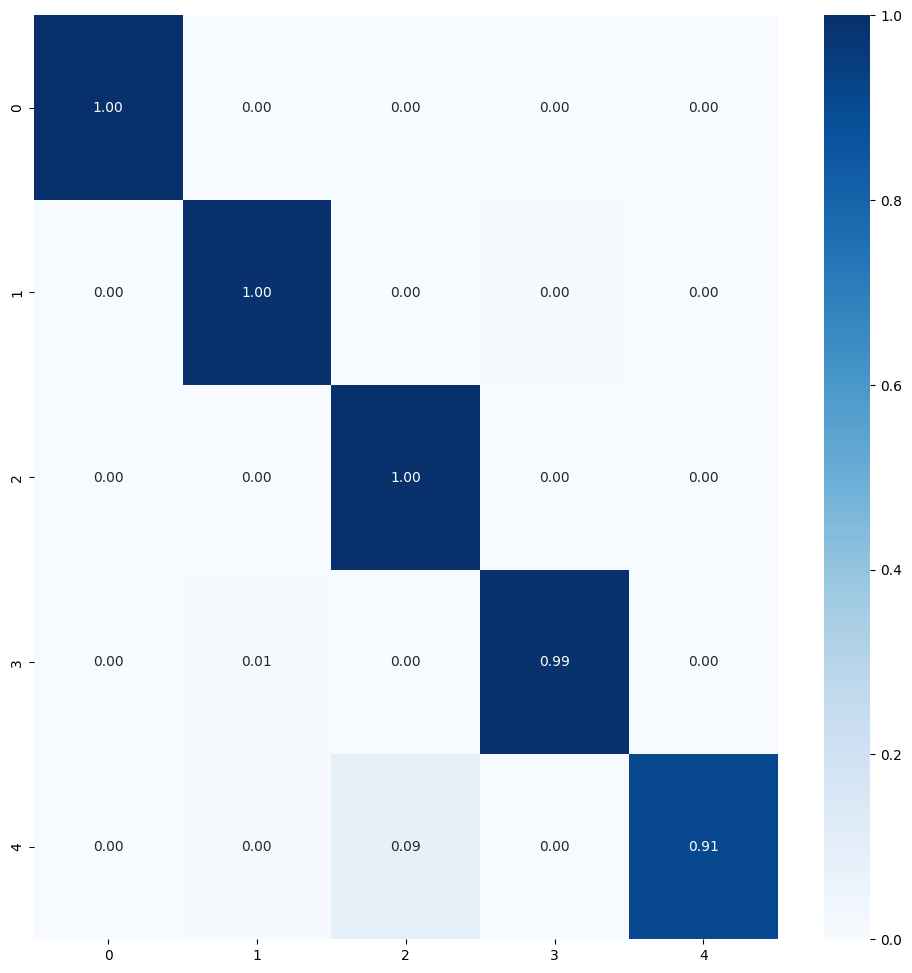


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822021
Trainable params: 1644805
Non-trainable params: 2177216
Epoch 1/50
164/164 [==============================] - 37s 162ms/step - loss: 1.2537 - accuracy: 0.8789 - val_loss: 1.0830 - val_accuracy: 0.9286
Epoch 2/50
164/164 [==============================] - 25s 149ms/step - loss: 0.9628 - accuracy: 0.9743 - val_loss: 0.9096 - val_accuracy: 0.9920
Epoch 3/50
164/164 [==============================] - 25s 151ms/step - loss: 0.9263 - accuracy: 0.9820 - val_loss: 0.8814 - val_accuracy: 0.9964
Epoch 4/50
164/164 [==============================] - 25s 151ms/step - loss: 0.8887 - accuracy: 0.9887 - val_loss: 0.8665 - val_accuracy: 0.9946
Epoch 5/50
164/164 [==============================] - 25s 152ms/step - loss: 0.8615 - accuracy: 0.9916 - val_loss: 0.8461 - val_accuracy: 0.9955
Epoch 6/50
164/164 [==============================] - 24s 145ms/step - loss: 0.8383 - accuracy: 0.9939 - val_loss: 0.8287 - val_accuracy: 0.9955
Epoch 7/50
164

History for fold 2 saved...
165/165 [==============================] - 21s 122ms/step - loss: 0.1620 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.16200900077819824
36/36 [==============================] - 5s 120ms/step - loss: 0.1947 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.1946992576122284
36/36 [==============================] - 5s 118ms/step - loss: 0.2042 - accuracy: 0.9920
Test Accuracy: 0.9919999837875366
Test Log Loss: 0.20416505634784698
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 220   0   5]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00      0.9

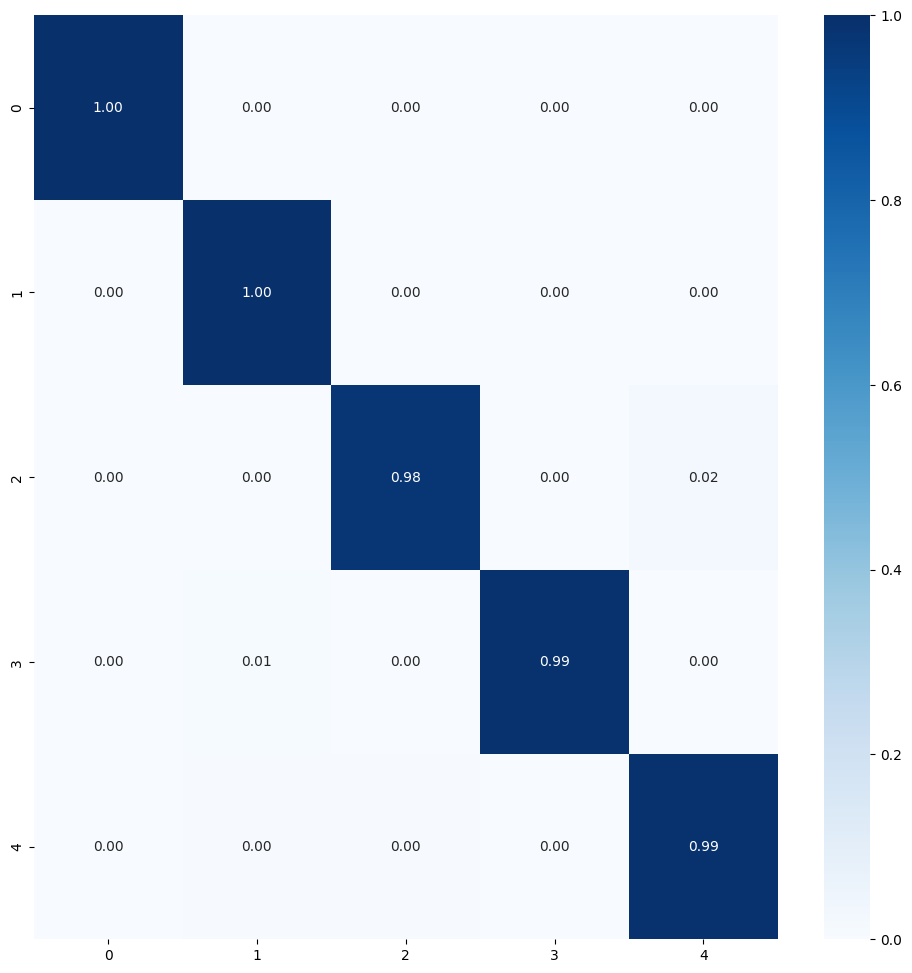


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822021
Trainable params: 1644805
Non-trainable params: 2177216
Epoch 1/50
164/164 [==============================] - 37s 169ms/step - loss: 1.2004 - accuracy: 0.8877 - val_loss: 1.0306 - val_accuracy: 0.9563
Epoch 2/50
164/164 [==============================] - 25s 149ms/step - loss: 0.9533 - accuracy: 0.9730 - val_loss: 0.9062 - val_accuracy: 0.9893
Epoch 3/50
164/164 [==============================] - 24s 148ms/step - loss: 0.9039 - accuracy: 0.9872 - val_loss: 0.8788 - val_accuracy: 0.9920
Epoch 4/50
164/164 [==============================] - 24s 149ms/step - loss: 0.8766 - accuracy: 0.9900 - val_loss: 0.8553 - val_accuracy: 0.9946
Epoch 5/50
164/164 [==============================] - 25s 152ms/step - loss: 0.8501 - accuracy: 0.9925 - val_loss: 0.8440 - val_accuracy: 0.9920
Epoch 6/50
164/164 [==============================] - 26s 154ms/step - loss: 0.8328 - accuracy: 0.9902 - val_loss: 0.8161 - val_accuracy: 0.9955
Epoch 7/50
164

History for fold 3 saved...
165/165 [==============================] - 21s 125ms/step - loss: 0.1822 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.18224118649959564
36/36 [==============================] - 5s 126ms/step - loss: 0.2051 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.20512443780899048
36/36 [==============================] - 6s 124ms/step - loss: 0.2090 - accuracy: 0.9938
Test Accuracy: 0.9937777519226074
Test Log Loss: 0.20898909866809845
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   3   0 221]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       0.99      1.

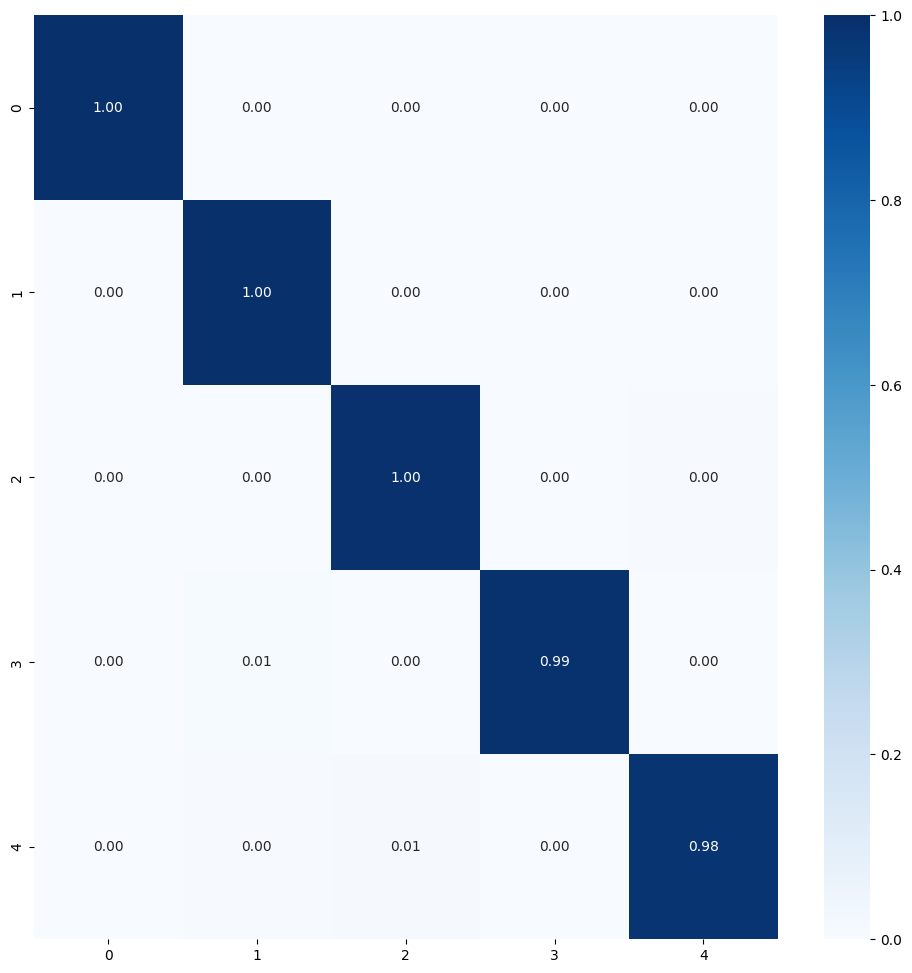


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822021
Trainable params: 1644805
Non-trainable params: 2177216
Epoch 1/50
164/164 [==============================] - 39s 177ms/step - loss: 1.2170 - accuracy: 0.8835 - val_loss: 1.0259 - val_accuracy: 0.9634
Epoch 2/50
164/164 [==============================] - 26s 154ms/step - loss: 0.9540 - accuracy: 0.9737 - val_loss: 0.9167 - val_accuracy: 0.9830
Epoch 3/50
164/164 [==============================] - 25s 151ms/step - loss: 0.9230 - accuracy: 0.9812 - val_loss: 0.8901 - val_accuracy: 0.9893
Epoch 4/50
164/164 [==============================] - 26s 156ms/step - loss: 0.8809 - accuracy: 0.9893 - val_loss: 0.8643 - val_accuracy: 0.9946
Epoch 5/50
164/164 [==============================] - 25s 152ms/step - loss: 0.8634 - accuracy: 0.9897 - val_loss: 0.8655 - val_accuracy: 0.9821
Epoch 6/50
164/164 [==============================] - 25s 151ms/step - loss: 0.8369 - accuracy: 0.9939 - val_loss: 0.8322 - val_accuracy: 0.9929
Epoch 7/50
164

History for fold 4 saved...
165/165 [==============================] - 21s 125ms/step - loss: 0.1960 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.19595275819301605
36/36 [==============================] - 5s 120ms/step - loss: 0.2260 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.22600926458835602
36/36 [==============================] - 4s 119ms/step - loss: 0.2280 - accuracy: 0.9938
Test Accuracy: 0.9937777519226074
Test Log Loss: 0.22799931466579437
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   3   0 221]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       0.99      1.

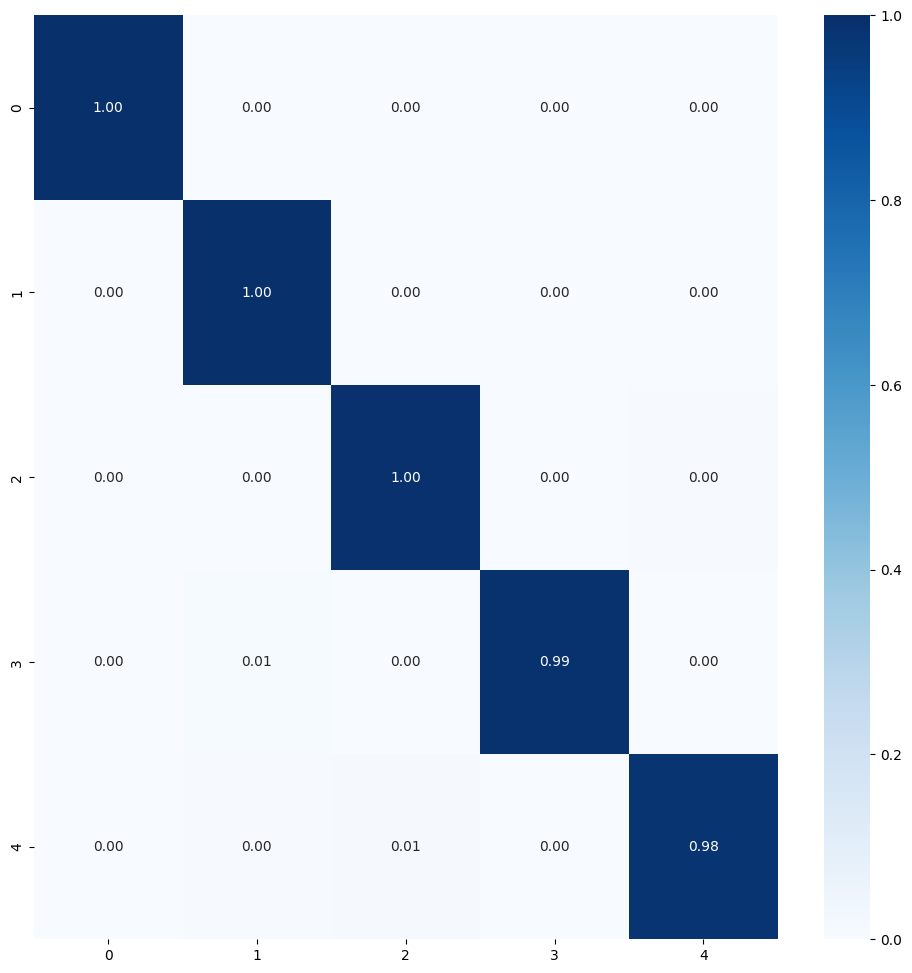


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822021
Trainable params: 1644805
Non-trainable params: 2177216
Epoch 1/50
164/164 [==============================] - 37s 166ms/step - loss: 1.2204 - accuracy: 0.8837 - val_loss: 1.0221 - val_accuracy: 0.9661
Epoch 2/50
164/164 [==============================] - 25s 151ms/step - loss: 0.9562 - accuracy: 0.9730 - val_loss: 0.9063 - val_accuracy: 0.9902
Epoch 3/50
164/164 [==============================] - 25s 151ms/step - loss: 0.9079 - accuracy: 0.9864 - val_loss: 0.9020 - val_accuracy: 0.9804
Epoch 4/50
164/164 [==============================] - 25s 151ms/step - loss: 0.8826 - accuracy: 0.9870 - val_loss: 0.8628 - val_accuracy: 0.9920
Epoch 5/50
164/164 [==============================] - 25s 152ms/step - loss: 0.8523 - accuracy: 0.9931 - val_loss: 0.8383 - val_accuracy: 0.9964
Epoch 6/50
164/164 [==============================] - 26s 156ms/step - loss: 0.8265 - accuracy: 0.9946 - val_loss: 0.8215 - val_accuracy: 0.9946
Epoch 7/50
164

History for fold 5 saved...
165/165 [==============================] - 22s 126ms/step - loss: 0.1621 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.16208618879318237
36/36 [==============================] - 5s 123ms/step - loss: 0.1893 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.1893044263124466
36/36 [==============================] - 5s 133ms/step - loss: 0.1831 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.18305888772010803
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 225   0   0]
 [  0   2   0 223   0]
 [  0   1   2   0 222]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       0.99      1.00

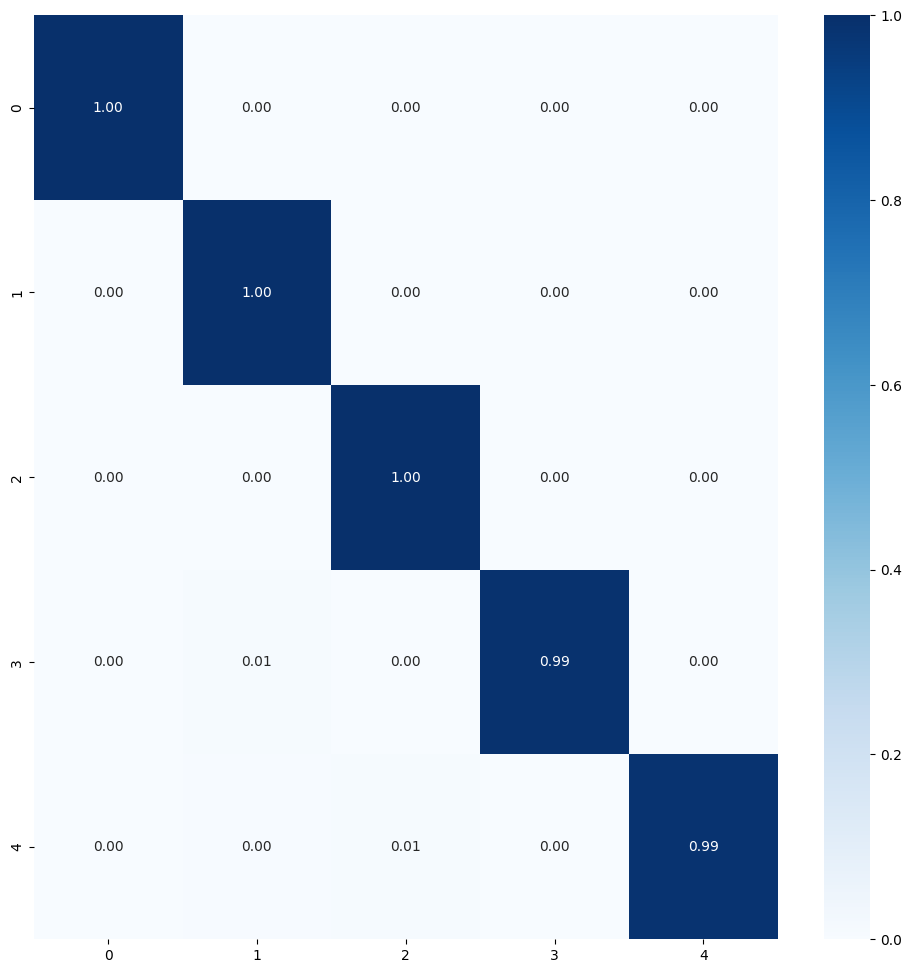


Best fold was 1 with val_accuracy: 0.9973
Average training accuracy in 5-fold: 0.9999616742134094
Average validation precision in 5-fold: 0.9969642758369446

Test Metrics
test_acc_list: [0.9786666631698608, 0.9919999837875366, 0.9937777519226074, 0.9937777519226074, 0.995555579662323]
Average Test Accuracy with 5-fold: 0.9907555460929871
test_loss_list: [0.23856529593467712, 0.20416505634784698, 0.20898909866809845, 0.22799931466579437, 0.18305888772010803]
Average Test Log Loss with 5-fold: 0.21255553066730498

Precision List: [0.9801374404387306, 0.9920774787647852, 0.9938243483455633, 0.9938243483455633, 0.9956063065151867]
Average Precision List with 5-fold: 0.9910939844819658
Recall List: [0.9786666666666667, 0.992, 0.9937777777777779, 0.9937777777777779, 0.9955555555555555]
Average Recall List with 5-fold: 0.9907555555555556
F1 Score List: [0.9785929375121702, 0.9920015488599739, 0.9937755915761354, 0.9937755915761354, 0.9955554019144776]
Average F1 Score List with 5-fold: 0.990

In [20]:
%%time

num_classes = 5
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/6
name_save_model: MobileNet_tf_15006
Found 6300 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822150
Trainable params: 1644934
Non-trainable params: 2177216
Epoch 1/50
196/196 [==============================] - 45s 176ms/step - loss: 1.3195 - accuracy: 0.8521 - val_loss: 1.0616 - val_accuracy: 0.9182
Epoch 2/50
196/196 [==============================] - 31s 156ms/step - loss: 0.9754 - accuracy: 0.9647 - val_loss: 0.9041 - val_accuracy: 0.9911
Epoch 3/50
196/196 [==============================] - 30s 152ms/step - loss: 0.9164 - accuracy: 0.9815 - val_loss: 0.8855 - val_accuracy: 0.9903
Epoch 4/50
196/196 [==============================] - 32s 164ms/step - loss: 0.8796 - accuracy: 0.9882 - val_loss: 0.

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
197/197 [==============================] - 25s 128ms/step - loss: 0.0236 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.023591071367263794
43/43 [==============================] - 6s 131ms/step - loss: 0.0500 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.050045546144247055
43/43 [==============================] - 6s 128ms/step - loss: 0.0459 - accuracy: 0.9948
Test Accuracy: 0.9948148131370544
Test Log Loss: 0.04594196006655693
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99   

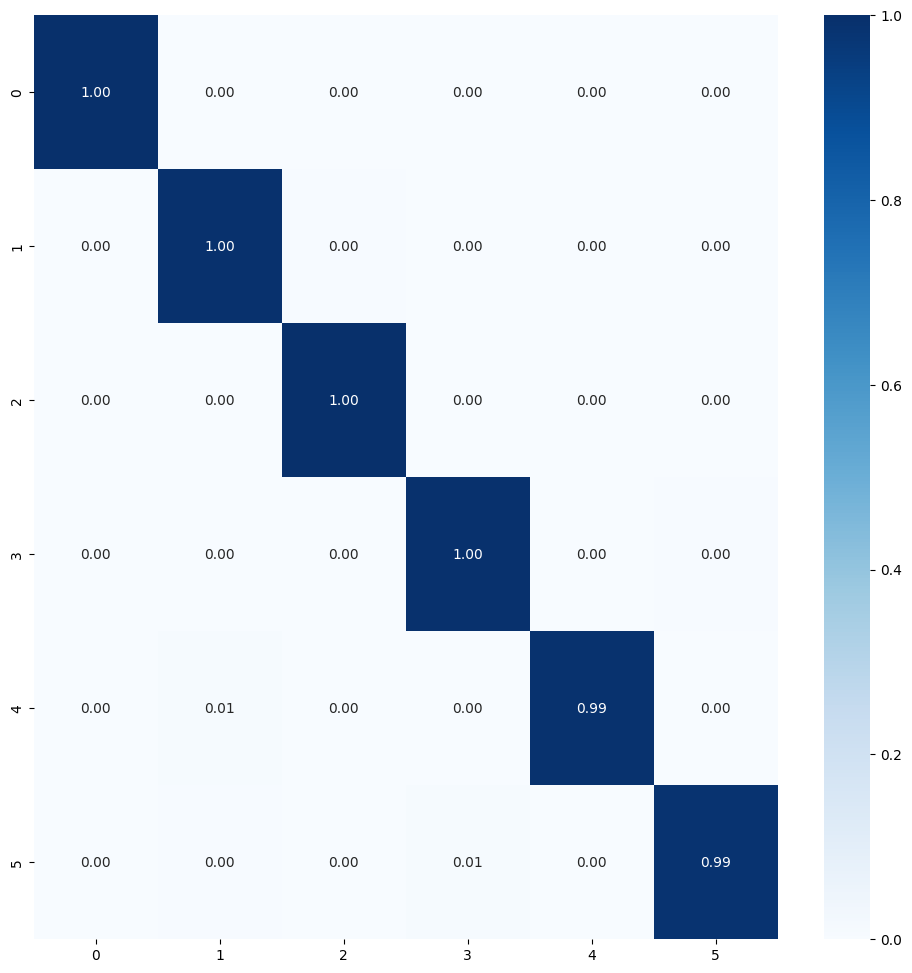


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822150
Trainable params: 1644934
Non-trainable params: 2177216
Epoch 1/50
196/196 [==============================] - 46s 170ms/step - loss: 1.2600 - accuracy: 0.8663 - val_loss: 1.0846 - val_accuracy: 0.9077
Epoch 2/50
196/196 [==============================] - 31s 160ms/step - loss: 0.9627 - accuracy: 0.9697 - val_loss: 0.9053 - val_accuracy: 0.9896
Epoch 3/50
196/196 [==============================] - 31s 159ms/step - loss: 0.9102 - accuracy: 0.9850 - val_loss: 0.8779 - val_accuracy: 0.9948
Epoch 4/50
196/196 [==============================] - 30s 154ms/step - loss: 0.8750 - accuracy: 0.9874 - val_loss: 0.8584 - val_accuracy: 0.9933
Epoch 5/50
196/196 [==============================] - 31s 157ms/step - loss: 0.8458 - accuracy: 0.9906 - val_loss: 0.8318 - val_accuracy: 0.9940
Epoch 6/50
196/196 [==============================] - 31s 157ms/step - loss: 0.8148 - accuracy: 0.9951 - val_loss: 0.8240 - val_accuracy: 0.9881
Epoch 7/50
196

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 2 saved...
197/197 [==============================] - 26s 132ms/step - loss: 0.0215 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.02153671905398369
43/43 [==============================] - 6s 132ms/step - loss: 0.0495 - accuracy: 0.9941
Validation Accuracy: 0.9940740466117859
Validation Log Loss: 0.04950028657913208
43/43 [==============================] - 6s 131ms/step - loss: 0.0545 - accuracy: 0.9948
Test Accuracy: 0.9948148131370544
Test Log Loss: 0.05450174957513809
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 225   0   0]
 [  0   2   0   0 223   0]
 [  0   1   0   3   0 221]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99    

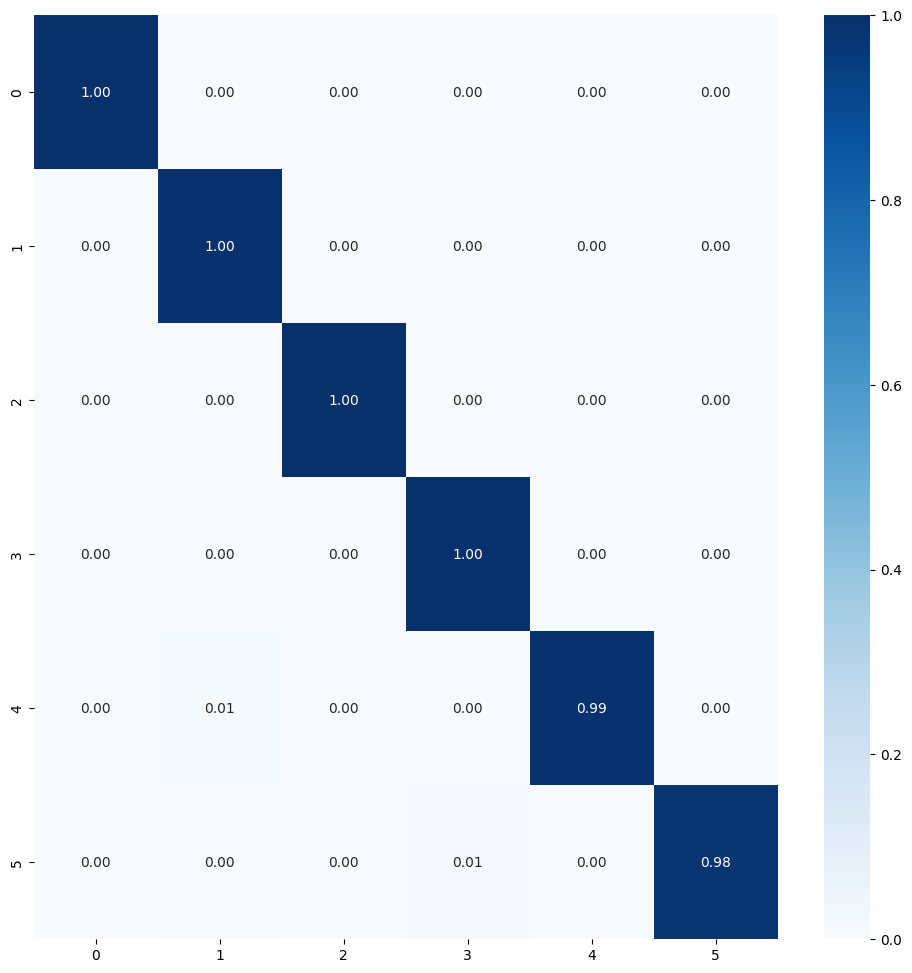


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822150
Trainable params: 1644934
Non-trainable params: 2177216
Epoch 1/50
196/196 [==============================] - 46s 181ms/step - loss: 1.3096 - accuracy: 0.8607 - val_loss: 1.0400 - val_accuracy: 0.9427
Epoch 2/50
196/196 [==============================] - 32s 162ms/step - loss: 0.9850 - accuracy: 0.9659 - val_loss: 0.9177 - val_accuracy: 0.9859
Epoch 3/50
196/196 [==============================] - 32s 161ms/step - loss: 0.9243 - accuracy: 0.9789 - val_loss: 0.8797 - val_accuracy: 0.9948
Epoch 4/50
196/196 [==============================] - 31s 160ms/step - loss: 0.8850 - accuracy: 0.9876 - val_loss: 0.8654 - val_accuracy: 0.9911
Epoch 5/50
196/196 [==============================] - 31s 157ms/step - loss: 0.8549 - accuracy: 0.9925 - val_loss: 0.8447 - val_accuracy: 0.9911
Epoch 6/50
196/196 [==============================] - 29s 149ms/step - loss: 0.8263 - accuracy: 0.9944 - val_loss: 0.8282 - val_accuracy: 0.9918
Epoch 7/50
196

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 3 saved...
197/197 [==============================] - 30s 150ms/step - loss: 0.0255 - accuracy: 0.9995
Train Accuracy: 0.9995238184928894
Train Log Loss: 0.02551383525133133
43/43 [==============================] - 8s 160ms/step - loss: 0.0638 - accuracy: 0.9896
Validation Accuracy: 0.9896296262741089
Validation Log Loss: 0.06380490213632584
43/43 [==============================] - 7s 153ms/step - loss: 0.0895 - accuracy: 0.9889
Test Accuracy: 0.9888888597488403
Test Log Loss: 0.08954521268606186
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 225   0   0]
 [  0   2   0   0 223   0]
 [  0   1   0  10   0 214]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1

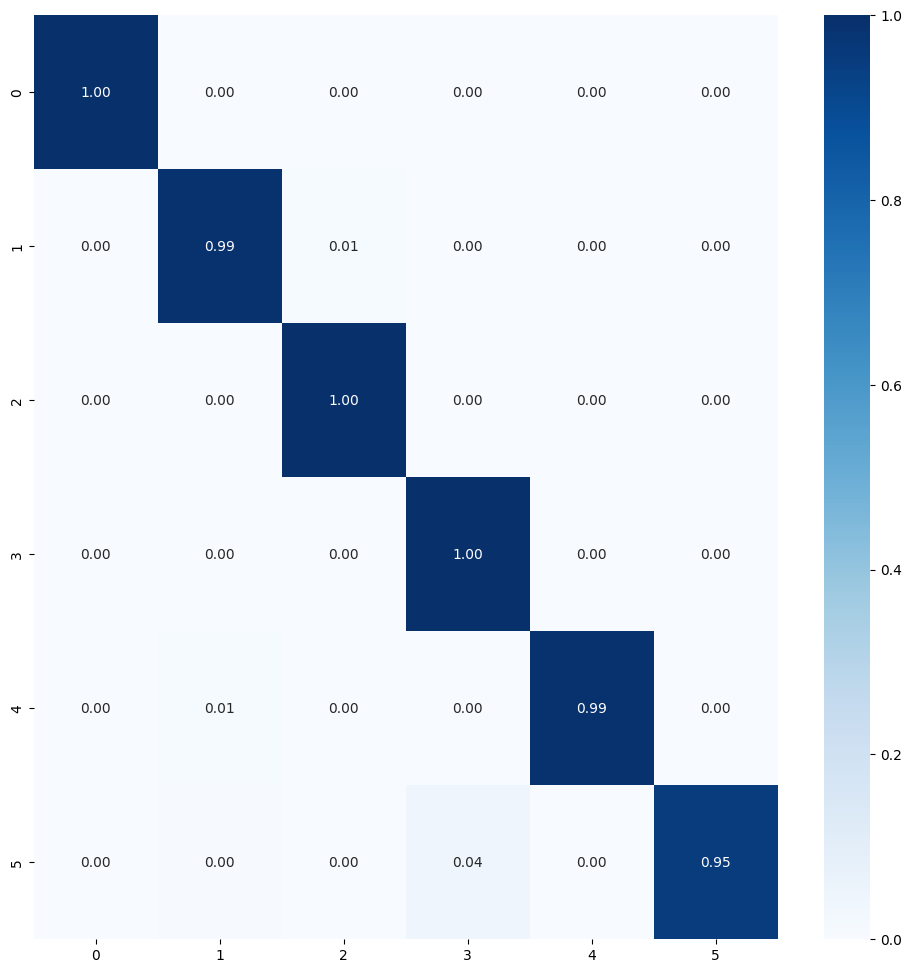


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822150
Trainable params: 1644934
Non-trainable params: 2177216
Epoch 1/50
196/196 [==============================] - 52s 202ms/step - loss: 1.2634 - accuracy: 0.8711 - val_loss: 1.0372 - val_accuracy: 0.9427
Epoch 2/50
196/196 [==============================] - 38s 192ms/step - loss: 0.9764 - accuracy: 0.9688 - val_loss: 0.9066 - val_accuracy: 0.9881
Epoch 3/50
196/196 [==============================] - 38s 191ms/step - loss: 0.9135 - accuracy: 0.9828 - val_loss: 0.8797 - val_accuracy: 0.9926
Epoch 4/50
196/196 [==============================] - 38s 194ms/step - loss: 0.8800 - accuracy: 0.9887 - val_loss: 0.8604 - val_accuracy: 0.9926
Epoch 5/50
196/196 [==============================] - 38s 193ms/step - loss: 0.8513 - accuracy: 0.9911 - val_loss: 0.8413 - val_accuracy: 0.9926
Epoch 6/50
196/196 [==============================] - 37s 189ms/step - loss: 0.8273 - accuracy: 0.9923 - val_loss: 0.8213 - val_accuracy: 0.9911
Epoch 7/50
196

History for fold 4 saved...
197/197 [==============================] - 25s 128ms/step - loss: 0.0264 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.026361245661973953
43/43 [==============================] - 6s 132ms/step - loss: 0.0535 - accuracy: 0.9941
Validation Accuracy: 0.9940740466117859
Validation Log Loss: 0.0535188689827919
43/43 [==============================] - 6s 125ms/step - loss: 0.0505 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.05048864334821701
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99     

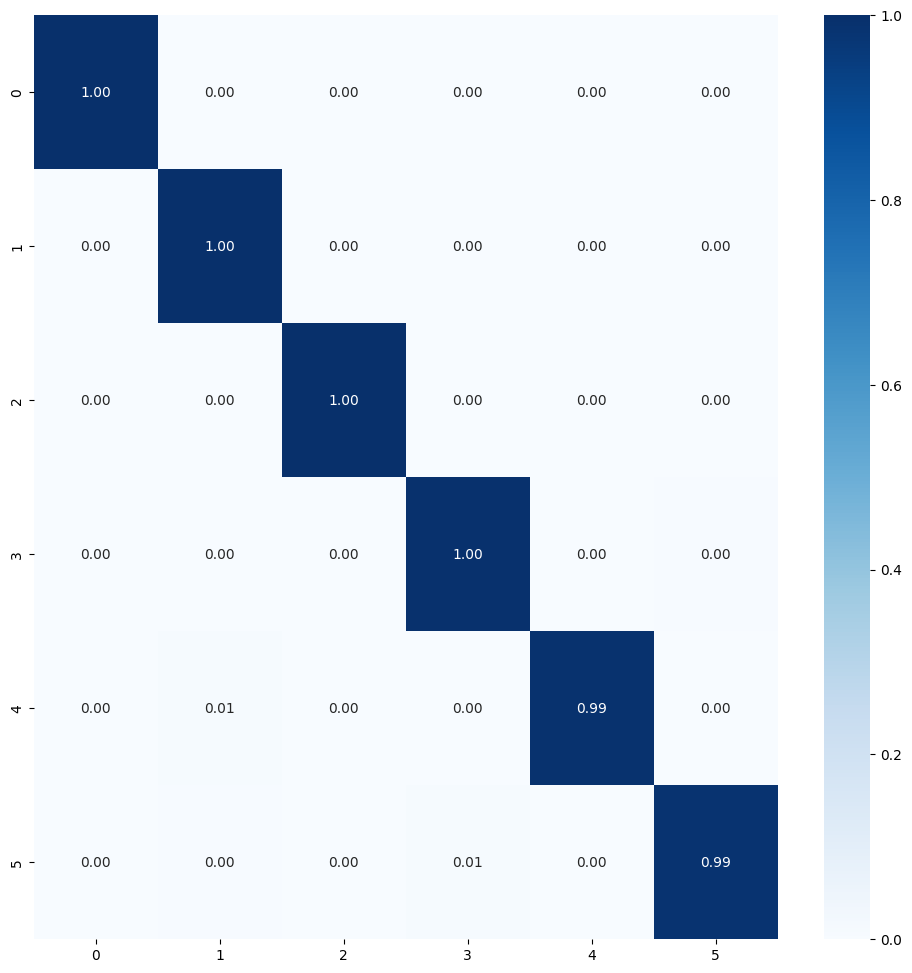


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822150
Trainable params: 1644934
Non-trainable params: 2177216
Epoch 1/50
196/196 [==============================] - 43s 170ms/step - loss: 1.2990 - accuracy: 0.8594 - val_loss: 1.1145 - val_accuracy: 0.8958
Epoch 2/50
196/196 [==============================] - 31s 156ms/step - loss: 0.9829 - accuracy: 0.9628 - val_loss: 0.9156 - val_accuracy: 0.9836
Epoch 3/50
196/196 [==============================] - 32s 161ms/step - loss: 0.9185 - accuracy: 0.9832 - val_loss: 0.8800 - val_accuracy: 0.9933
Epoch 4/50
196/196 [==============================] - 32s 160ms/step - loss: 0.8823 - accuracy: 0.9884 - val_loss: 0.8590 - val_accuracy: 0.9955
Epoch 5/50
196/196 [==============================] - 30s 153ms/step - loss: 0.8546 - accuracy: 0.9912 - val_loss: 0.8362 - val_accuracy: 0.9955
Epoch 6/50
196/196 [==============================] - 32s 158ms/step - loss: 0.8285 - accuracy: 0.9944 - val_loss: 0.8265 - val_accuracy: 0.9933
Epoch 7/50
196

History for fold 5 saved...
197/197 [==============================] - 26s 129ms/step - loss: 0.0291 - accuracy: 0.9998
Train Accuracy: 0.9998412728309631
Train Log Loss: 0.02912438102066517
43/43 [==============================] - 6s 139ms/step - loss: 0.0567 - accuracy: 0.9941
Validation Accuracy: 0.9940740466117859
Validation Log Loss: 0.05665038898587227
43/43 [==============================] - 6s 125ms/step - loss: 0.0566 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.05661679804325104
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1 

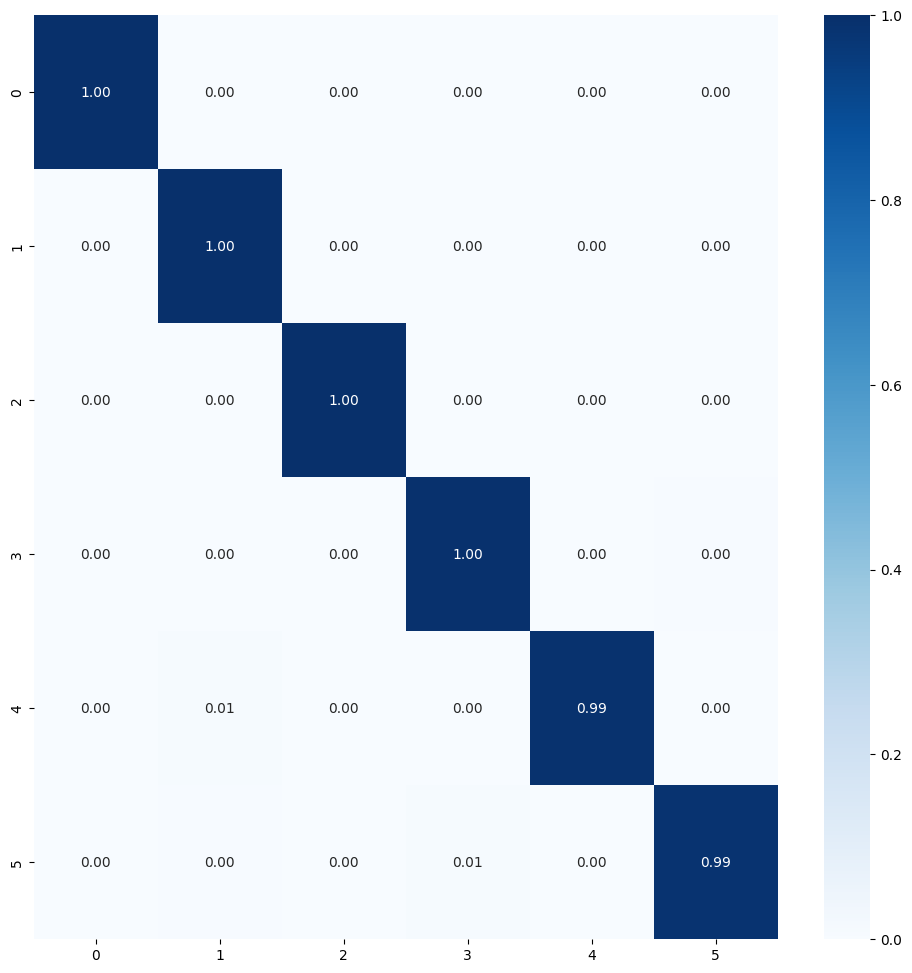


Best fold was 3 with val_accuracy: 0.9970
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.996279776096344

Test Metrics
test_acc_list: [0.9948148131370544, 0.9948148131370544, 0.9888888597488403, 0.995555579662323, 0.995555579662323]
Average Test Accuracy with 5-fold: 0.993925929069519
test_loss_list: [0.04594196006655693, 0.05450174957513809, 0.08954521268606186, 0.05048864334821701, 0.05661679804325104]
Average Test Log Loss with 5-fold: 0.05941887274384498

Precision List: [0.994837583292207, 0.9948669112452099, 0.9892269832567046, 0.9955847071347165, 0.9955847071347165]
Average Precision List with 5-fold: 0.9940201784127108
Recall List: [0.9948148148148149, 0.9948148148148149, 0.9888888888888889, 0.9955555555555556, 0.9955555555555556]
Average Recall List with 5-fold: 0.9939259259259261
F1 Score List: [0.994814734289022, 0.9948129559069345, 0.9888713971634268, 0.9955554569333644, 0.9955554569333644]
Average F1 Score List with 5-fold: 0.9939220002

In [21]:
%%time

num_classes = 6
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/7
name_save_model: MobileNet_tf_15007
Found 7350 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822279
Trainable params: 1645063
Non-trainable params: 2177216
Epoch 1/50
229/229 [==============================] - 50s 174ms/step - loss: 1.2610 - accuracy: 0.8818 - val_loss: 1.0910 - val_accuracy: 0.9101
Epoch 2/50
229/229 [==============================] - 37s 158ms/step - loss: 0.9589 - accuracy: 0.9720 - val_loss: 0.9060 - val_accuracy: 0.9923
Epoch 3/50
229/229 [==============================] - 39s 169ms/step - loss: 0.9011 - accuracy: 0.9832 - val_loss: 0.8908 - val_accuracy: 0.9879
Epoch 4/50
229/229 [==============================] - 36s 159ms/step - loss: 0.8639 - accuracy: 0.9899

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
230/230 [==============================] - 28s 123ms/step - loss: 0.0132 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.013231093063950539
50/50 [==============================] - 6s 126ms/step - loss: 0.0549 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.054868344217538834
50/50 [==============================] - 7s 135ms/step - loss: 0.0540 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.05403386056423187
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   2   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

      

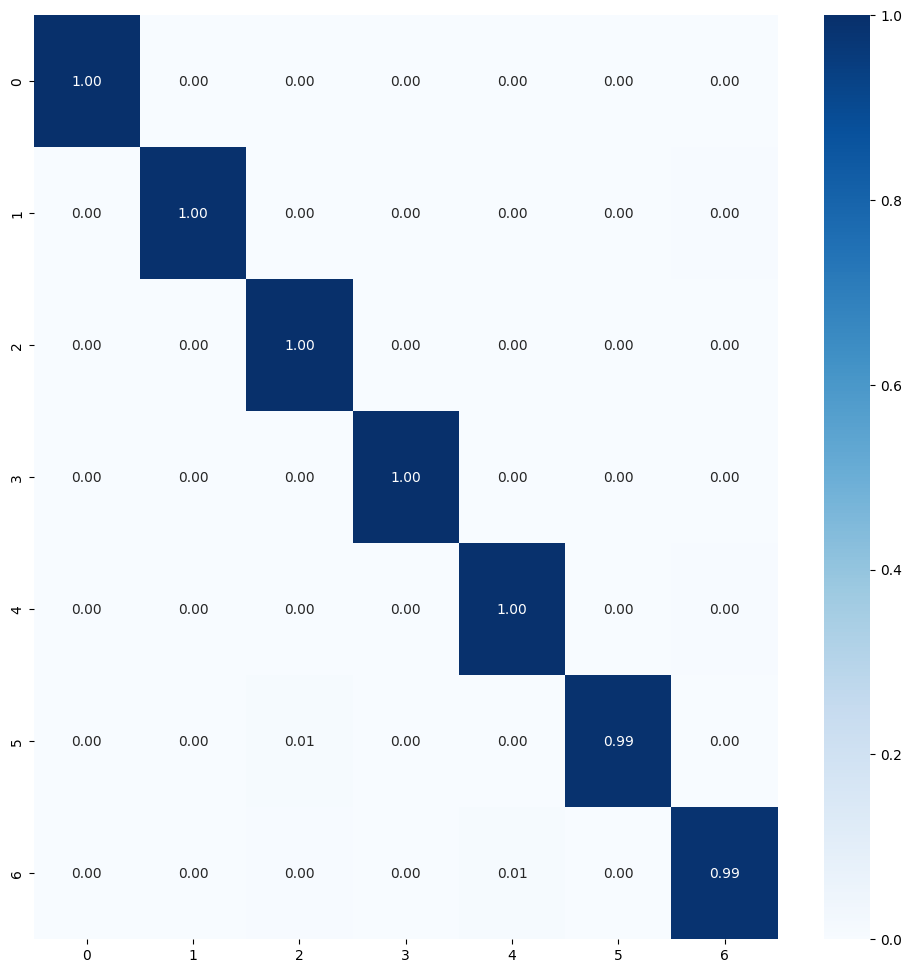


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822279
Trainable params: 1645063
Non-trainable params: 2177216
Epoch 1/50
229/229 [==============================] - 48s 163ms/step - loss: 1.3108 - accuracy: 0.8646 - val_loss: 0.9930 - val_accuracy: 0.9675
Epoch 2/50
229/229 [==============================] - 34s 147ms/step - loss: 0.9651 - accuracy: 0.9721 - val_loss: 0.9021 - val_accuracy: 0.9923
Epoch 3/50
229/229 [==============================] - 34s 148ms/step - loss: 0.9056 - accuracy: 0.9843 - val_loss: 0.8753 - val_accuracy: 0.9923
Epoch 4/50
229/229 [==============================] - 35s 150ms/step - loss: 0.8657 - accuracy: 0.9910 - val_loss: 0.8641 - val_accuracy: 0.9904
Epoch 5/50
229/229 [==============================] - 36s 155ms/step - loss: 0.8385 - accuracy: 0.9930 - val_loss: 0.8290 - val_accuracy: 0.9930
Epoch 6/50
229/229 [==============================] - 36s 152ms/step - loss: 0.8069 - accuracy: 0.9944 - val_loss: 0.8062 - val_accuracy: 0.9923
Epoch 7/50
229

History for fold 2 saved...
230/230 [==============================] - 29s 119ms/step - loss: 0.0163 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.01626560278236866
50/50 [==============================] - 6s 122ms/step - loss: 0.0417 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.04169763624668121
50/50 [==============================] - 6s 122ms/step - loss: 0.0458 - accuracy: 0.9937
Test Accuracy: 0.9936507940292358
Test Log Loss: 0.04583021253347397
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 223   1   0   1   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   3   0 221]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

       

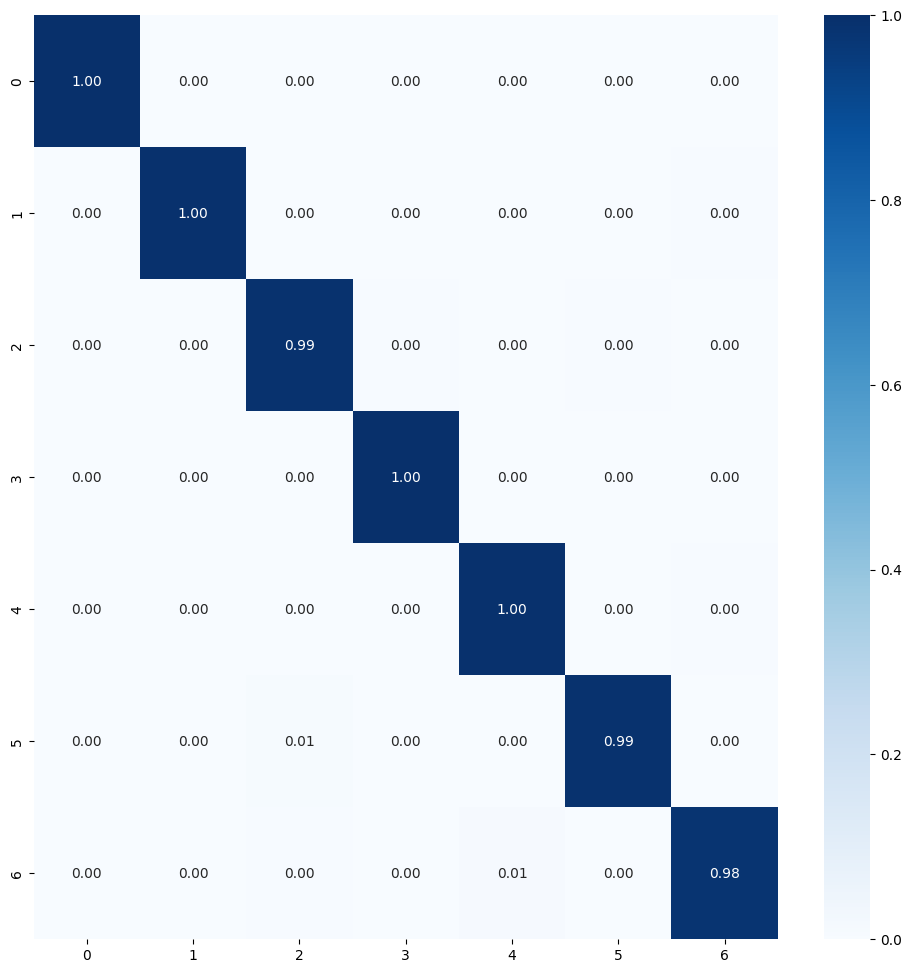


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822279
Trainable params: 1645063
Non-trainable params: 2177216
Epoch 1/50
229/229 [==============================] - 52s 184ms/step - loss: 1.2463 - accuracy: 0.8840 - val_loss: 0.9979 - val_accuracy: 0.9598
Epoch 2/50
229/229 [==============================] - 35s 154ms/step - loss: 0.9620 - accuracy: 0.9732 - val_loss: 0.9192 - val_accuracy: 0.9860
Epoch 3/50
229/229 [==============================] - 37s 162ms/step - loss: 0.9033 - accuracy: 0.9835 - val_loss: 0.8729 - val_accuracy: 0.9955
Epoch 4/50
229/229 [==============================] - 35s 153ms/step - loss: 0.8700 - accuracy: 0.9882 - val_loss: 0.8565 - val_accuracy: 0.9904
Epoch 5/50
229/229 [==============================] - 36s 156ms/step - loss: 0.8349 - accuracy: 0.9925 - val_loss: 0.8312 - val_accuracy: 0.9930
Epoch 6/50
229/229 [==============================] - 35s 151ms/step - loss: 0.8049 - accuracy: 0.9939 - val_loss: 0.7988 - val_accuracy: 0.9949
Epoch 7/50
229

History for fold 3 saved...
230/230 [==============================] - 29s 126ms/step - loss: 0.0110 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.010962441563606262
50/50 [==============================] - 7s 129ms/step - loss: 0.0460 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.046010639518499374
50/50 [==============================] - 7s 124ms/step - loss: 0.0463 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.046341150999069214
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 224   1   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 225   0   0]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   2   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

     

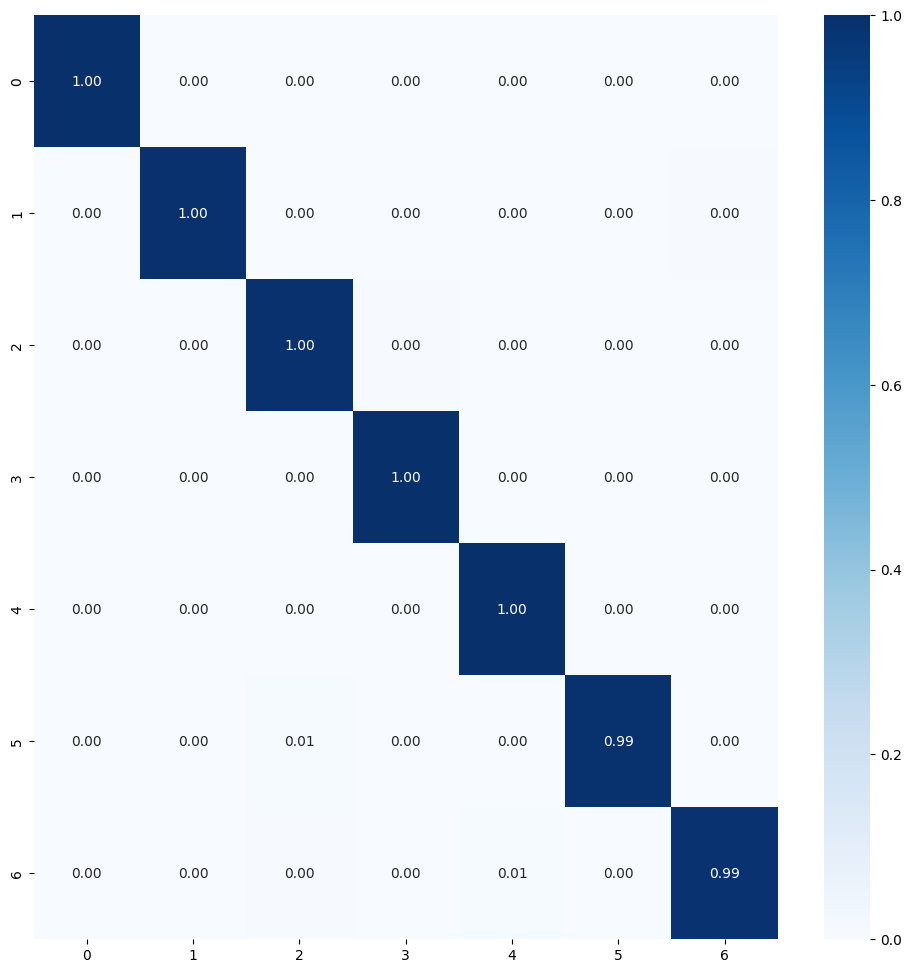


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822279
Trainable params: 1645063
Non-trainable params: 2177216
Epoch 1/50
229/229 [==============================] - 50s 172ms/step - loss: 1.2758 - accuracy: 0.8736 - val_loss: 1.0534 - val_accuracy: 0.9190
Epoch 2/50
229/229 [==============================] - 37s 161ms/step - loss: 0.9608 - accuracy: 0.9725 - val_loss: 0.9685 - val_accuracy: 0.9598
Epoch 3/50
229/229 [==============================] - 36s 154ms/step - loss: 0.9001 - accuracy: 0.9848 - val_loss: 0.8888 - val_accuracy: 0.9898
Epoch 4/50
229/229 [==============================] - 34s 149ms/step - loss: 0.8606 - accuracy: 0.9908 - val_loss: 0.8550 - val_accuracy: 0.9923
Epoch 5/50
229/229 [==============================] - 40s 173ms/step - loss: 0.8276 - accuracy: 0.9936 - val_loss: 0.8274 - val_accuracy: 0.9936
Epoch 6/50
229/229 [==============================] - 36s 151ms/step - loss: 0.7982 - accuracy: 0.9944 - val_loss: 0.8027 - val_accuracy: 0.9923
Epoch 7/50
229

History for fold 4 saved...
230/230 [==============================] - 28s 122ms/step - loss: 0.0125 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.01248035579919815
50/50 [==============================] - 6s 103ms/step - loss: 0.0502 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.05015875771641731
50/50 [==============================] - 5s 88ms/step - loss: 0.0496 - accuracy: 0.9949
Test Accuracy: 0.9949206113815308
Test Log Loss: 0.04961223155260086
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 224   1   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   2   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

        

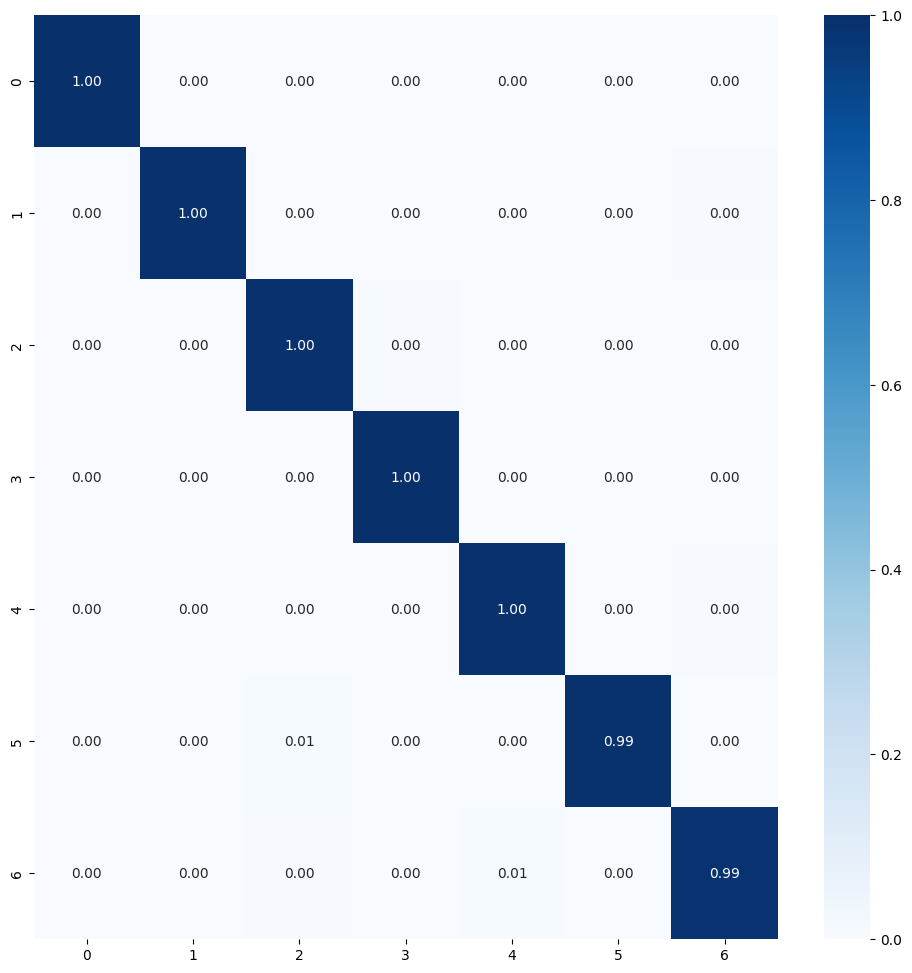


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822279
Trainable params: 1645063
Non-trainable params: 2177216
Epoch 1/50
229/229 [==============================] - 46s 158ms/step - loss: 1.2816 - accuracy: 0.8724 - val_loss: 0.9810 - val_accuracy: 0.9764
Epoch 2/50
229/229 [==============================] - 35s 150ms/step - loss: 0.9622 - accuracy: 0.9727 - val_loss: 0.9202 - val_accuracy: 0.9834
Epoch 3/50
229/229 [==============================] - 37s 158ms/step - loss: 0.9020 - accuracy: 0.9861 - val_loss: 0.8827 - val_accuracy: 0.9892
Epoch 4/50
229/229 [==============================] - 35s 151ms/step - loss: 0.8684 - accuracy: 0.9876 - val_loss: 0.8661 - val_accuracy: 0.9879
Epoch 5/50
229/229 [==============================] - 37s 158ms/step - loss: 0.8356 - accuracy: 0.9911 - val_loss: 0.8328 - val_accuracy: 0.9917
Epoch 6/50
229/229 [==============================] - 36s 155ms/step - loss: 0.7985 - accuracy: 0.9945 - val_loss: 0.7960 - val_accuracy: 0.9943
Epoch 7/50
229

History for fold 5 saved...
230/230 [==============================] - 31s 131ms/step - loss: 0.0141 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.014148016460239887
50/50 [==============================] - 7s 125ms/step - loss: 0.0497 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.04971391335129738
50/50 [==============================] - 7s 128ms/step - loss: 0.0511 - accuracy: 0.9937
Test Accuracy: 0.9936507940292358
Test Log Loss: 0.05114328861236572
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 224   1   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 221   0   4]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   1   0 223]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

      

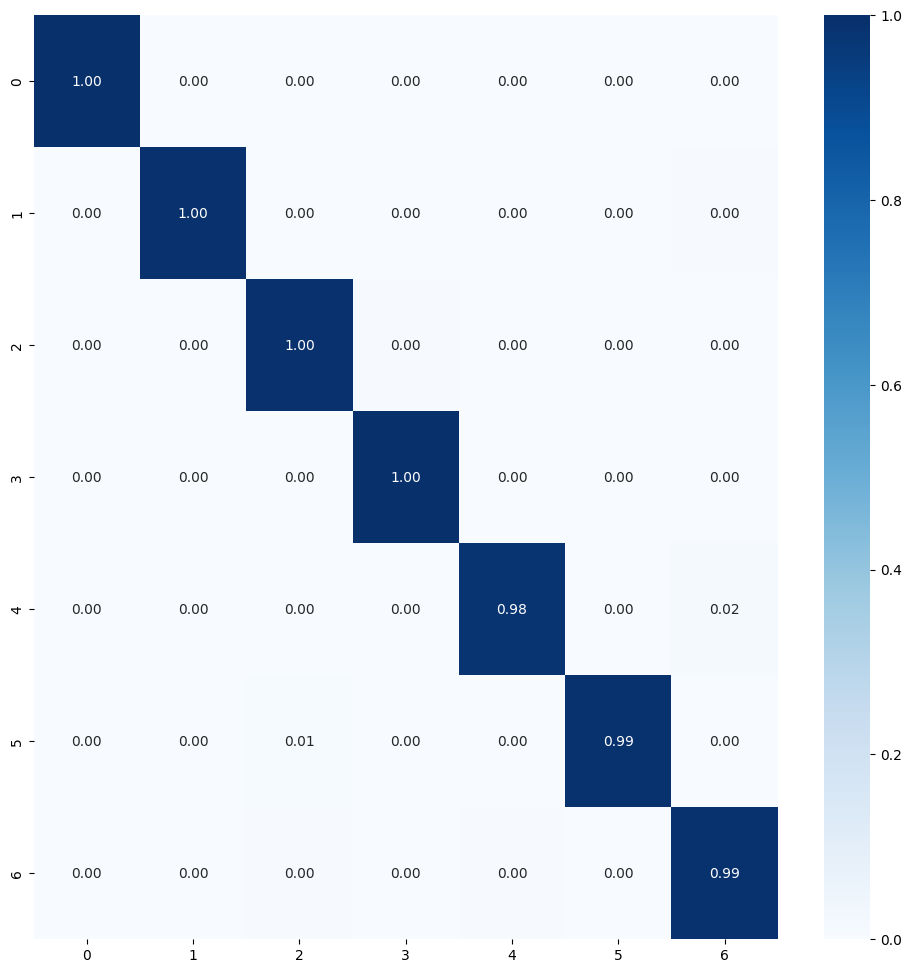


Best fold was 1 with val_accuracy: 0.9962
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9955357193946839

Test Metrics
test_acc_list: [0.995555579662323, 0.9936507940292358, 0.995555579662323, 0.9949206113815308, 0.9936507940292358]
Average Test Accuracy with 5-fold: 0.9946666717529297
test_loss_list: [0.05403386056423187, 0.04583021253347397, 0.046341150999069214, 0.04961223155260086, 0.05114328861236572]
Average Test Log Loss with 5-fold: 0.04939214885234833

Precision List: [0.9955805680446376, 0.9936645900493085, 0.9955806406554487, 0.9949401761796295, 0.9937035761631705]
Average Precision List with 5-fold: 0.9946939102184389
Recall List: [0.9955555555555556, 0.9936507936507937, 0.9955555555555556, 0.9949206349206349, 0.9936507936507938]
Average Recall List with 5-fold: 0.9946666666666667
F1 Score List: [0.9955568977250755, 0.9936493042806955, 0.9955554771687901, 0.9949219926013535, 0.9936576384875994]
Average F1 Score List with 5-fold: 0.99466

In [22]:
%%time

num_classes = 7
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/8
name_save_model: MobileNet_tf_15008
Found 8400 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822408
Trainable params: 1645192
Non-trainable params: 2177216
Epoch 1/50
262/262 [==============================] - 58s 179ms/step - loss: 1.2772 - accuracy: 0.8762 - val_loss: 0.9681 - val_accuracy: 0.9788
Epoch 2/50
262/262 [==============================] - 43s 165ms/step - loss: 0.9617 - accuracy: 0.9726 - val_loss: 0.9211 - val_accuracy: 0.9788
Epoch 3/50
262/262 [==============================] - 41s 158ms/step - loss: 0.9096 - accuracy: 0.9832 - val_loss: 0.8715 - val_accuracy: 0.9905
Epoch 4/50
262/262 [==============================] - 43s 162ms/step - loss: 0.8630 - accurac

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
263/263 [==============================] - 29s 109ms/step - loss: 0.0110 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.01104055903851986
57/57 [==============================] - 8s 131ms/step - loss: 0.0456 - accuracy: 0.9944
Validation Accuracy: 0.9944444298744202
Validation Log Loss: 0.04561571776866913
57/57 [==============================] - 8s 137ms/step - loss: 0.0465 - accuracy: 0.9950
Test Accuracy: 0.9950000047683716
Test Log Loss: 0.0465037077665329
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   4   0 220]]
True labels: 1800
Predicted labels: len(predicted_labels)

Classifica

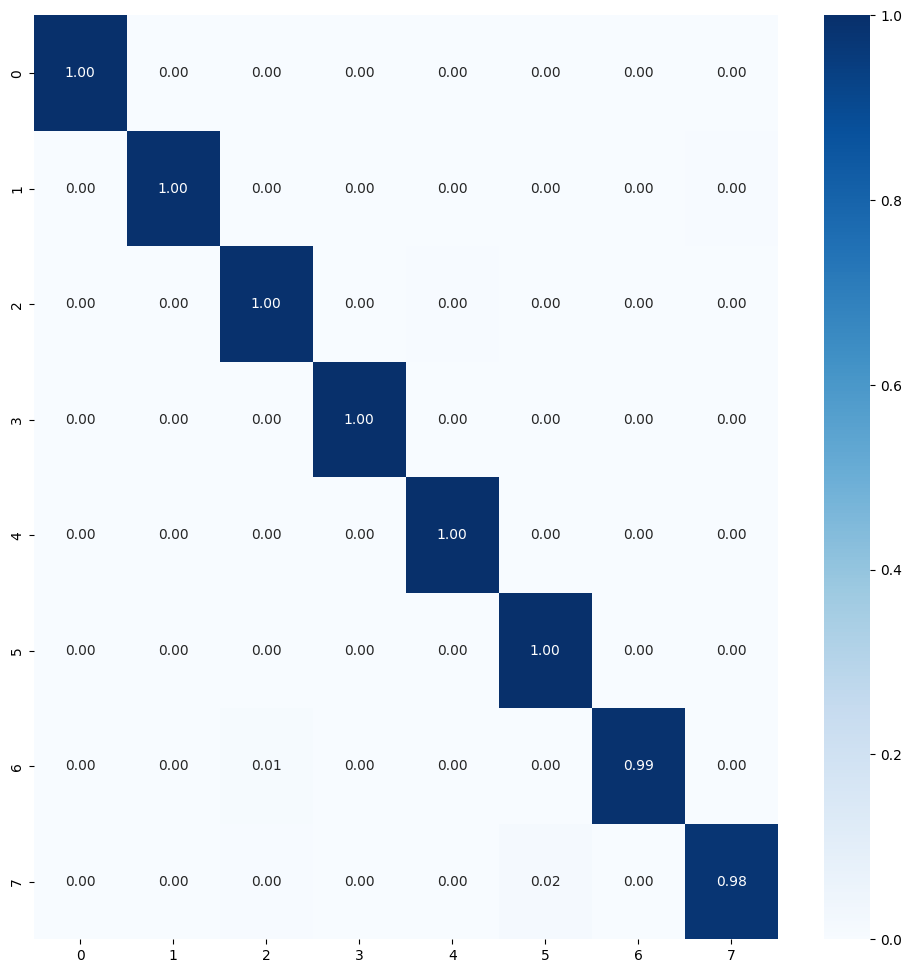


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822408
Trainable params: 1645192
Non-trainable params: 2177216
Epoch 1/50
262/262 [==============================] - 58s 174ms/step - loss: 1.2857 - accuracy: 0.8743 - val_loss: 0.9942 - val_accuracy: 0.9587
Epoch 2/50
262/262 [==============================] - 45s 170ms/step - loss: 0.9665 - accuracy: 0.9710 - val_loss: 0.9018 - val_accuracy: 0.9922
Epoch 3/50
262/262 [==============================] - 50s 192ms/step - loss: 0.8995 - accuracy: 0.9854 - val_loss: 0.8719 - val_accuracy: 0.9933
Epoch 4/50
262/262 [==============================] - 51s 194ms/step - loss: 0.8638 - accuracy: 0.9908 - val_loss: 0.8498 - val_accuracy: 0.9911
Epoch 5/50
262/262 [==============================] - 49s 186ms/step - loss: 0.8309 - accuracy: 0.9918 - val_loss: 0.8205 - val_accuracy: 0.9933
Epoch 6/50
262/262 [==============================] - 50s 189ms/step - loss: 0.7940 - accuracy: 0.9956 - val_loss: 0.7875 - val_accuracy: 0.9939
Epoch 7/50
262

History for fold 2 saved...
263/263 [==============================] - 36s 136ms/step - loss: 0.0084 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.008381010964512825
57/57 [==============================] - 8s 133ms/step - loss: 0.0386 - accuracy: 0.9950
Validation Accuracy: 0.9950000047683716
Validation Log Loss: 0.03862316906452179
57/57 [==============================] - 8s 132ms/step - loss: 0.0307 - accuracy: 0.9967
Test Accuracy: 0.996666669845581
Test Log Loss: 0.03071300871670246
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   0   0   1   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   1   0 223]]
True labels: 1800
Predicted labels: len(predicted_labels)

Classific

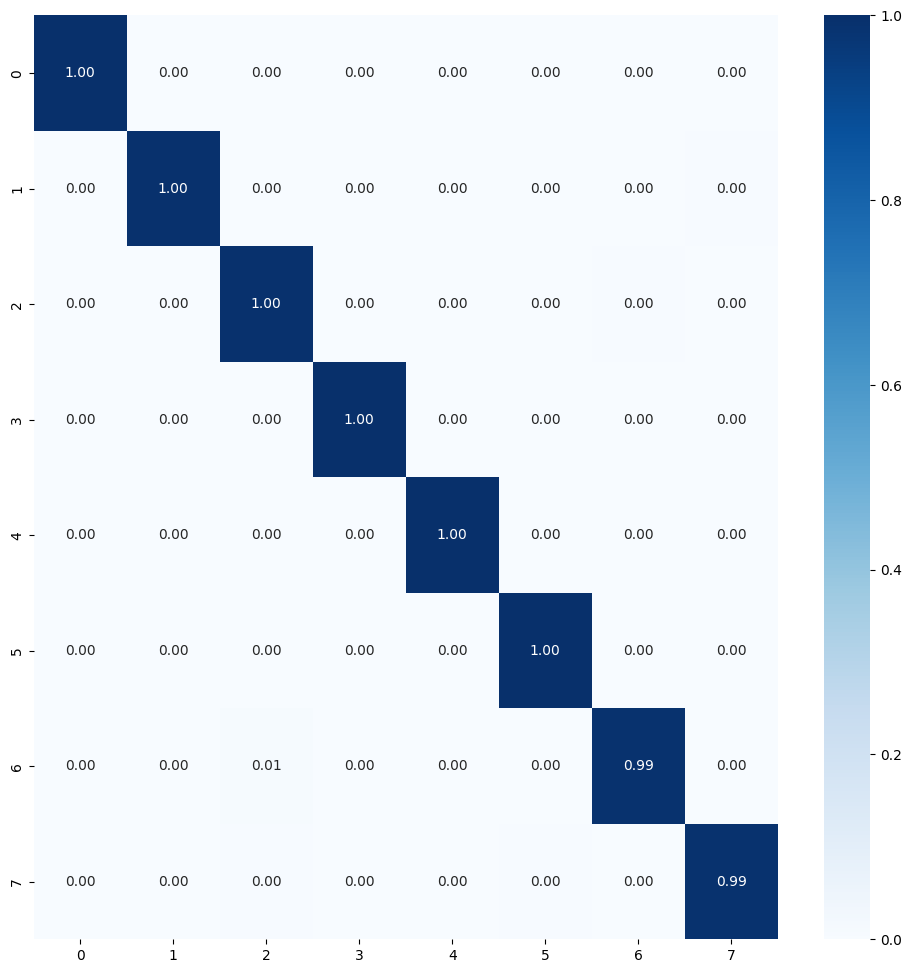


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822408
Trainable params: 1645192
Non-trainable params: 2177216
Epoch 1/50
262/262 [==============================] - 57s 180ms/step - loss: 1.2961 - accuracy: 0.8679 - val_loss: 0.9653 - val_accuracy: 0.9727
Epoch 2/50
262/262 [==============================] - 44s 168ms/step - loss: 0.9636 - accuracy: 0.9710 - val_loss: 0.8971 - val_accuracy: 0.9916
Epoch 3/50
262/262 [==============================] - 44s 166ms/step - loss: 0.9026 - accuracy: 0.9841 - val_loss: 0.8719 - val_accuracy: 0.9916
Epoch 4/50
262/262 [==============================] - 42s 162ms/step - loss: 0.8616 - accuracy: 0.9896 - val_loss: 0.8446 - val_accuracy: 0.9922
Epoch 5/50
262/262 [==============================] - 44s 165ms/step - loss: 0.8295 - accuracy: 0.9931 - val_loss: 0.8153 - val_accuracy: 0.9950
Epoch 6/50
262/262 [==============================] - 46s 174ms/step - loss: 0.7920 - accuracy: 0.9949 - val_loss: 0.7884 - val_accuracy: 0.9933
Epoch 7/50
262

History for fold 3 saved...
263/263 [==============================] - 41s 153ms/step - loss: 0.0124 - accuracy: 0.9996
Train Accuracy: 0.9996428489685059
Train Log Loss: 0.012403962202370167
57/57 [==============================] - 10s 149ms/step - loss: 0.0432 - accuracy: 0.9939
Validation Accuracy: 0.9938889145851135
Validation Log Loss: 0.043208975344896317
57/57 [==============================] - 9s 147ms/step - loss: 0.0520 - accuracy: 0.9917
Test Accuracy: 0.9916666746139526
Test Log Loss: 0.05196968466043472
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[224   0   0   0   1   0   0   0]
 [  0 224   0   0   1   0   0   0]
 [  0   0 217   0   8   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 224   0   1]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   1   0 223]]
True labels: 1800
Predicted labels: len(predicted_

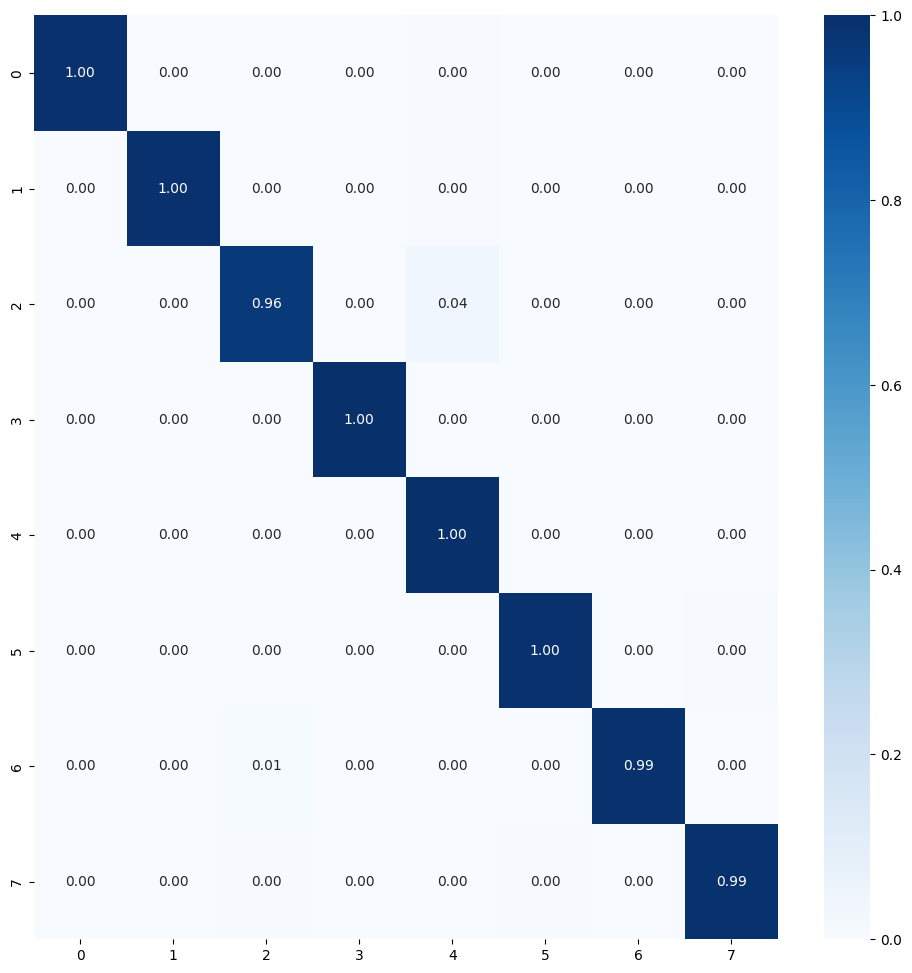


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822408
Trainable params: 1645192
Non-trainable params: 2177216
Epoch 1/50
262/262 [==============================] - 64s 196ms/step - loss: 1.2807 - accuracy: 0.8724 - val_loss: 0.9823 - val_accuracy: 0.9676
Epoch 2/50
262/262 [==============================] - 49s 185ms/step - loss: 0.9575 - accuracy: 0.9724 - val_loss: 0.8997 - val_accuracy: 0.9916
Epoch 3/50
262/262 [==============================] - 49s 186ms/step - loss: 0.9020 - accuracy: 0.9842 - val_loss: 0.8716 - val_accuracy: 0.9933
Epoch 4/50
262/262 [==============================] - 51s 191ms/step - loss: 0.8652 - accuracy: 0.9894 - val_loss: 0.8500 - val_accuracy: 0.9911
Epoch 5/50
262/262 [==============================] - 49s 185ms/step - loss: 0.8257 - accuracy: 0.9931 - val_loss: 0.8173 - val_accuracy: 0.9939
Epoch 6/50
262/262 [==============================] - 50s 192ms/step - loss: 0.7901 - accuracy: 0.9958 - val_loss: 0.7868 - val_accuracy: 0.9950
Epoch 7/50
262

History for fold 4 saved...
263/263 [==============================] - 35s 131ms/step - loss: 0.0075 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00749185448512435
57/57 [==============================] - 8s 130ms/step - loss: 0.0392 - accuracy: 0.9950
Validation Accuracy: 0.9950000047683716
Validation Log Loss: 0.03924837335944176
57/57 [==============================] - 8s 129ms/step - loss: 0.0322 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.03220319002866745
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 224   0   1]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   2   0 222]]
True labels: 1800
Predicted labels: len(predicted_labels)

Classifica

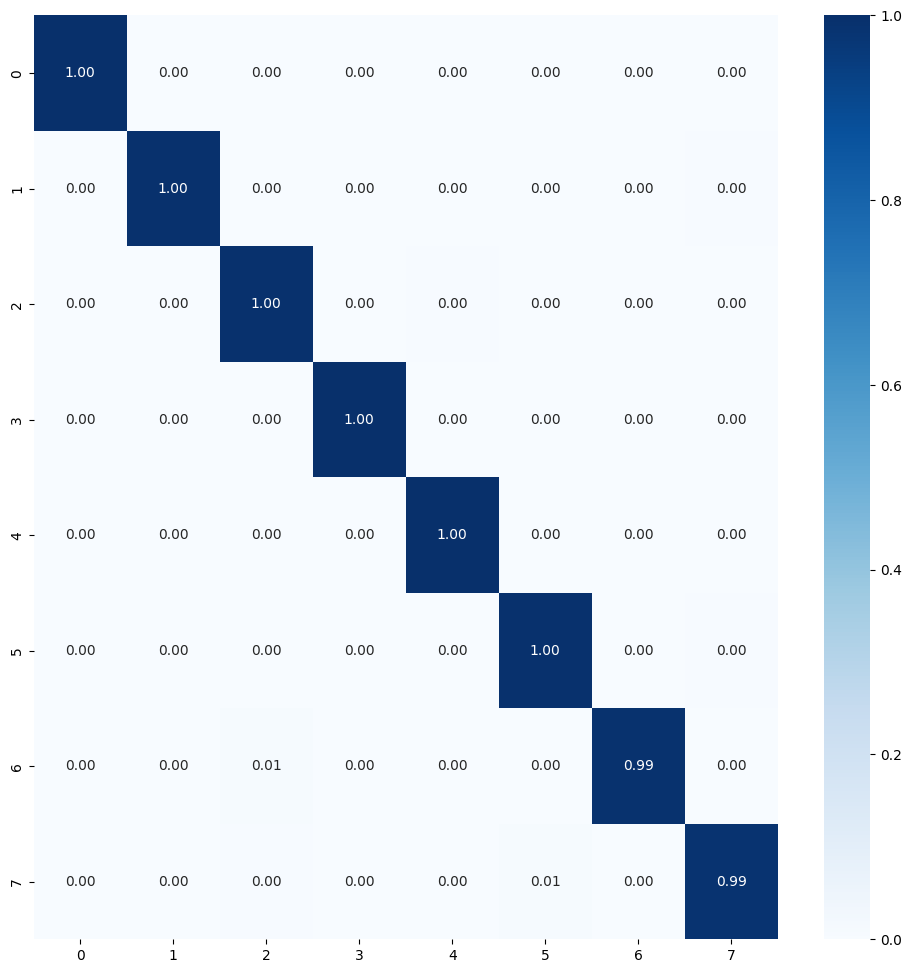


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822408
Trainable params: 1645192
Non-trainable params: 2177216
Epoch 1/50
262/262 [==============================] - 56s 171ms/step - loss: 1.3202 - accuracy: 0.8664 - val_loss: 0.9789 - val_accuracy: 0.9682
Epoch 2/50
262/262 [==============================] - 43s 164ms/step - loss: 0.9573 - accuracy: 0.9737 - val_loss: 0.8947 - val_accuracy: 0.9911
Epoch 3/50
262/262 [==============================] - 43s 163ms/step - loss: 0.8893 - accuracy: 0.9884 - val_loss: 0.8700 - val_accuracy: 0.9916
Epoch 4/50
262/262 [==============================] - 37s 140ms/step - loss: 0.8540 - accuracy: 0.9914 - val_loss: 0.8422 - val_accuracy: 0.9927
Epoch 5/50
262/262 [==============================] - 36s 138ms/step - loss: 0.8169 - accuracy: 0.9945 - val_loss: 0.8094 - val_accuracy: 0.9927
Epoch 6/50
262/262 [==============================] - 42s 159ms/step - loss: 0.7844 - accuracy: 0.9946 - val_loss: 0.7791 - val_accuracy: 0.9922
Epoch 7/50
262

History for fold 5 saved...
263/263 [==============================] - 32s 122ms/step - loss: 0.0101 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.010130148380994797
57/57 [==============================] - 7s 124ms/step - loss: 0.0359 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.03587669879198074
57/57 [==============================] - 8s 125ms/step - loss: 0.0332 - accuracy: 0.9967
Test Accuracy: 0.996666669845581
Test Log Loss: 0.033218082040548325
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 225   0   0   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 224   0   1]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   1   0 223]]
True labels: 1800
Predicted labels: len(predicted_labels)

Classific

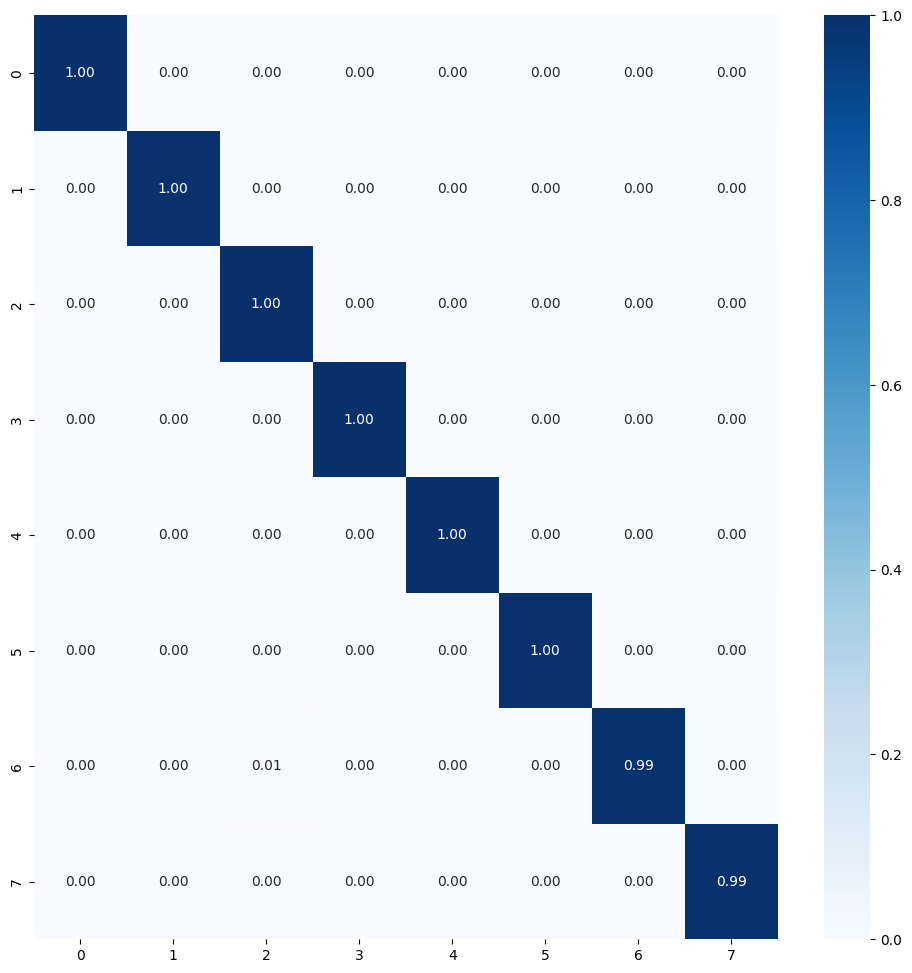


Best fold was 1 with val_accuracy: 0.9961
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9959821462631225

Test Metrics
test_acc_list: [0.9950000047683716, 0.996666669845581, 0.9916666746139526, 0.995555579662323, 0.996666669845581]
Average Test Accuracy with 5-fold: 0.9951111197471618
test_loss_list: [0.0465037077665329, 0.03071300871670246, 0.05196968466043472, 0.03220319002866745, 0.033218082040548325]
Average Test Log Loss with 5-fold: 0.03892153464257717

Precision List: [0.995045903302747, 0.9966788488474412, 0.9918627143394431, 0.9955726541571757, 0.996688596491228]
Average Precision List with 5-fold: 0.995169743427607
Recall List: [0.995, 0.9966666666666666, 0.9916666666666667, 0.9955555555555555, 0.9966666666666667]
Average Recall List with 5-fold: 0.9951111111111113
F1 Score List: [0.9949972753607166, 0.9966678683915275, 0.9916871476027334, 0.9955567435261843, 0.9966690866129856]
Average F1 Score List with 5-fold: 0.9951156242988295

Metri

In [23]:
%%time

num_classes = 8
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/9
name_save_model: MobileNet_tf_15009
Found 9450 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822537
Trainable params: 1645321
Non-trainable params: 2177216
Epoch 1/50
295/295 [==============================] - 59s 164ms/step - loss: 1.2473 - accuracy: 0.8836 - val_loss: 0.9511 - val_accuracy: 0.9792
Epoch 2/50
295/295 [==============================] - 48s 162ms/step - loss: 0.9469 - accuracy: 0.9744 - val_loss: 0.8897 - val_accuracy: 0.9911
Epoch 3/50
295/295 [==============================] - 45s 151ms/step - loss: 0.8865 - accuracy: 0.9863 - val_loss: 0.8561 - val_accuracy: 0.9950
Epoch 4/50
295/295 [==============================] - 49s 167ms/step - loss: 0.84

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
296/296 [==============================] - 47s 157ms/step - loss: 0.0092 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00920006725937128
64/64 [==============================] - 11s 158ms/step - loss: 0.0358 - accuracy: 0.9960
Validation Accuracy: 0.9960494041442871
Validation Log Loss: 0.03577842563390732
64/64 [==============================] - 10s 152ms/step - loss: 0.0322 - accuracy: 0.9965
Test Accuracy: 0.9965432286262512
Test Log Loss: 0.032241757959127426
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  0   0   0   2   0   0   0 223   0]
 [  0   0   0   1 

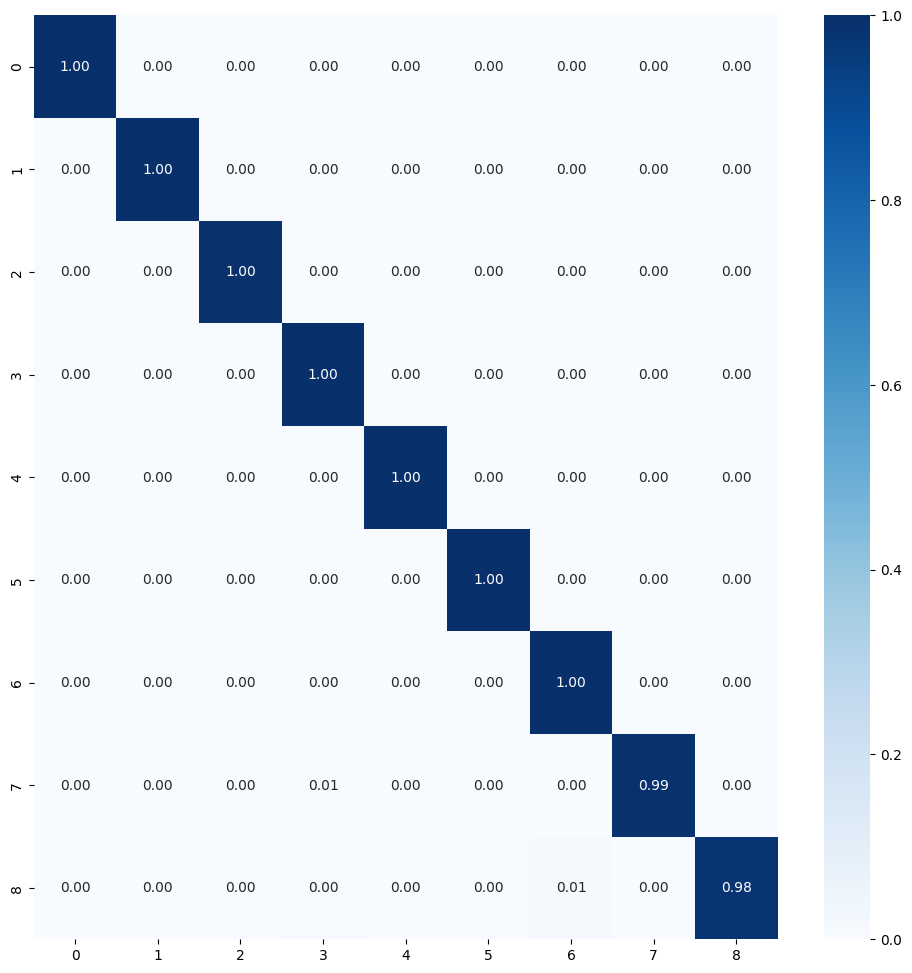


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822537
Trainable params: 1645321
Non-trainable params: 2177216
Epoch 1/50
295/295 [==============================] - 70s 196ms/step - loss: 1.2428 - accuracy: 0.8846 - val_loss: 0.9442 - val_accuracy: 0.9836
Epoch 2/50
295/295 [==============================] - 56s 189ms/step - loss: 0.9494 - accuracy: 0.9735 - val_loss: 0.8870 - val_accuracy: 0.9926
Epoch 3/50
295/295 [==============================] - 57s 191ms/step - loss: 0.8828 - accuracy: 0.9865 - val_loss: 0.8509 - val_accuracy: 0.9950
Epoch 4/50
295/295 [==============================] - 57s 192ms/step - loss: 0.8412 - accuracy: 0.9920 - val_loss: 0.8186 - val_accuracy: 0.9950
Epoch 5/50
295/295 [==============================] - 49s 166ms/step - loss: 0.8005 - accuracy: 0.9952 - val_loss: 0.7850 - val_accuracy: 0.9960
Epoch 6/50
295/295 [==============================] - 45s 152ms/step - loss: 0.7602 - accuracy: 0.9965 - val_loss: 0.7509 - val_accuracy: 0.9950
Epoch 7/50
295

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 2 saved...
296/296 [==============================] - 39s 133ms/step - loss: 0.0084 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.008410286158323288
64/64 [==============================] - 9s 130ms/step - loss: 0.0427 - accuracy: 0.9951
Validation Accuracy: 0.9950617551803589
Validation Log Loss: 0.04267527163028717
64/64 [==============================] - 9s 132ms/step - loss: 0.0392 - accuracy: 0.9960
Test Accuracy: 0.9960494041442871
Test Log Loss: 0.03917011246085167
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 224   1   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  0   0   0   2   0   0   0 223   0]
 [  0   0   0   1   

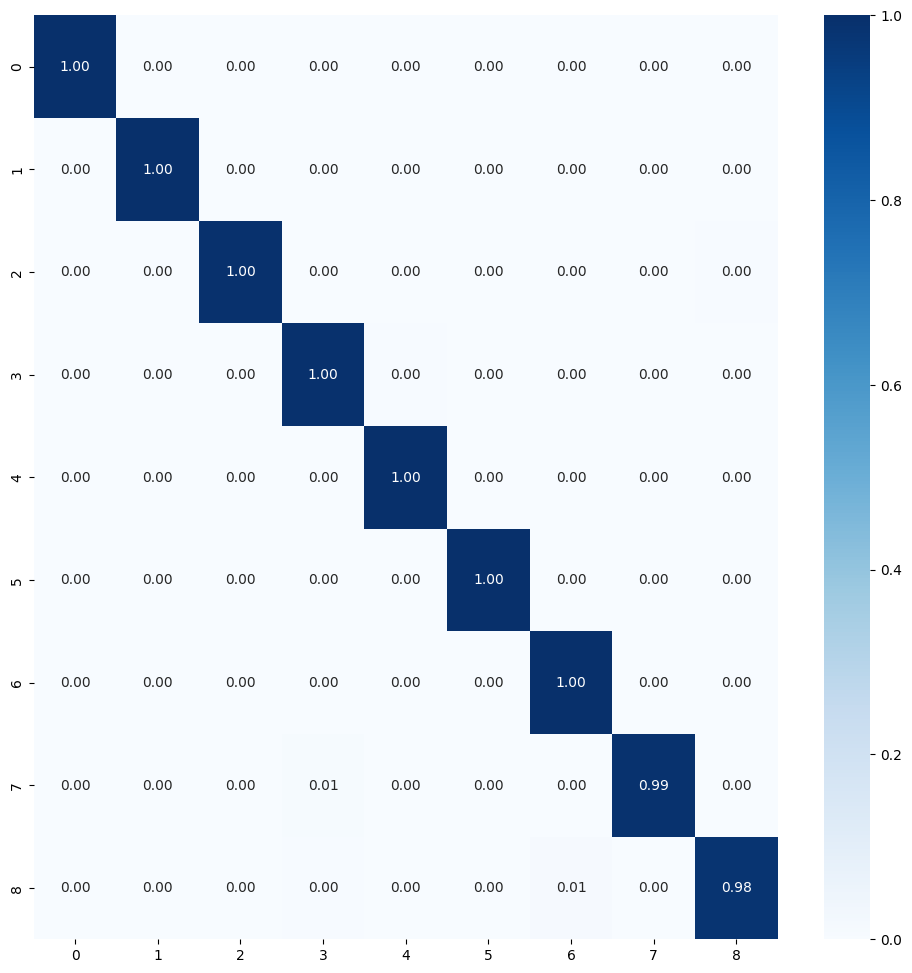


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822537
Trainable params: 1645321
Non-trainable params: 2177216
Epoch 1/50
295/295 [==============================] - 62s 171ms/step - loss: 1.2466 - accuracy: 0.8860 - val_loss: 0.9514 - val_accuracy: 0.9816
Epoch 2/50
295/295 [==============================] - 46s 157ms/step - loss: 0.9481 - accuracy: 0.9748 - val_loss: 0.8901 - val_accuracy: 0.9931
Epoch 3/50
295/295 [==============================] - 37s 126ms/step - loss: 0.8863 - accuracy: 0.9877 - val_loss: 0.8589 - val_accuracy: 0.9936
Epoch 4/50
295/295 [==============================] - 48s 158ms/step - loss: 0.8479 - accuracy: 0.9902 - val_loss: 0.8296 - val_accuracy: 0.9945
Epoch 5/50
295/295 [==============================] - 47s 157ms/step - loss: 0.8063 - accuracy: 0.9947 - val_loss: 0.7974 - val_accuracy: 0.9950
Epoch 6/50
295/295 [==============================] - 47s 160ms/step - loss: 0.7684 - accuracy: 0.9964 - val_loss: 0.7611 - val_accuracy: 0.9950
Epoch 7/50
295

History for fold 3 saved...
296/296 [==============================] - 36s 122ms/step - loss: 0.0082 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00816777627915144
64/64 [==============================] - 9s 119ms/step - loss: 0.0413 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.04134923219680786
64/64 [==============================] - 8s 128ms/step - loss: 0.0370 - accuracy: 0.9970
Test Accuracy: 0.9970370531082153
Test Log Loss: 0.037024736404418945
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  0   0   0   2   0   0   0 223   0]
 [  0   0   0   1   0

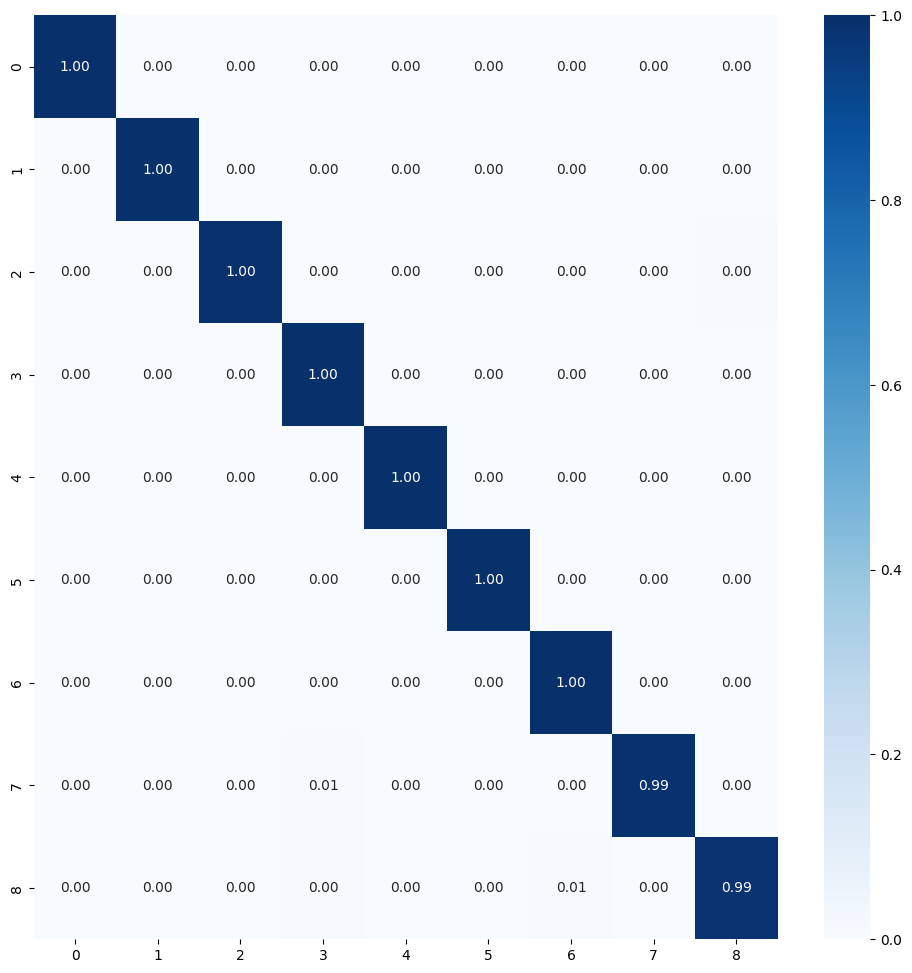


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822537
Trainable params: 1645321
Non-trainable params: 2177216
Epoch 1/50
295/295 [==============================] - 57s 160ms/step - loss: 1.2700 - accuracy: 0.8774 - val_loss: 0.9576 - val_accuracy: 0.9777
Epoch 2/50
295/295 [==============================] - 45s 153ms/step - loss: 0.9456 - accuracy: 0.9761 - val_loss: 0.8908 - val_accuracy: 0.9906
Epoch 3/50
295/295 [==============================] - 44s 149ms/step - loss: 0.8838 - accuracy: 0.9872 - val_loss: 0.8599 - val_accuracy: 0.9921
Epoch 4/50
295/295 [==============================] - 48s 161ms/step - loss: 0.8419 - accuracy: 0.9917 - val_loss: 0.8235 - val_accuracy: 0.9940
Epoch 5/50
295/295 [==============================] - 57s 189ms/step - loss: 0.7991 - accuracy: 0.9947 - val_loss: 0.7862 - val_accuracy: 0.9950
Epoch 6/50
295/295 [==============================] - 50s 167ms/step - loss: 0.7582 - accuracy: 0.9951 - val_loss: 0.7679 - val_accuracy: 0.9876
Epoch 7/50
295

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 4 saved...
296/296 [==============================] - 41s 136ms/step - loss: 0.0081 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00812783744186163
64/64 [==============================] - 9s 138ms/step - loss: 0.0398 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.03984355926513672
64/64 [==============================] - 9s 139ms/step - loss: 0.0414 - accuracy: 0.9951
Test Accuracy: 0.9950617551803589
Test Log Loss: 0.04135897755622864
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  0   0   0   2   0   0   0 223   0]
 [  0   0   0   1   0 

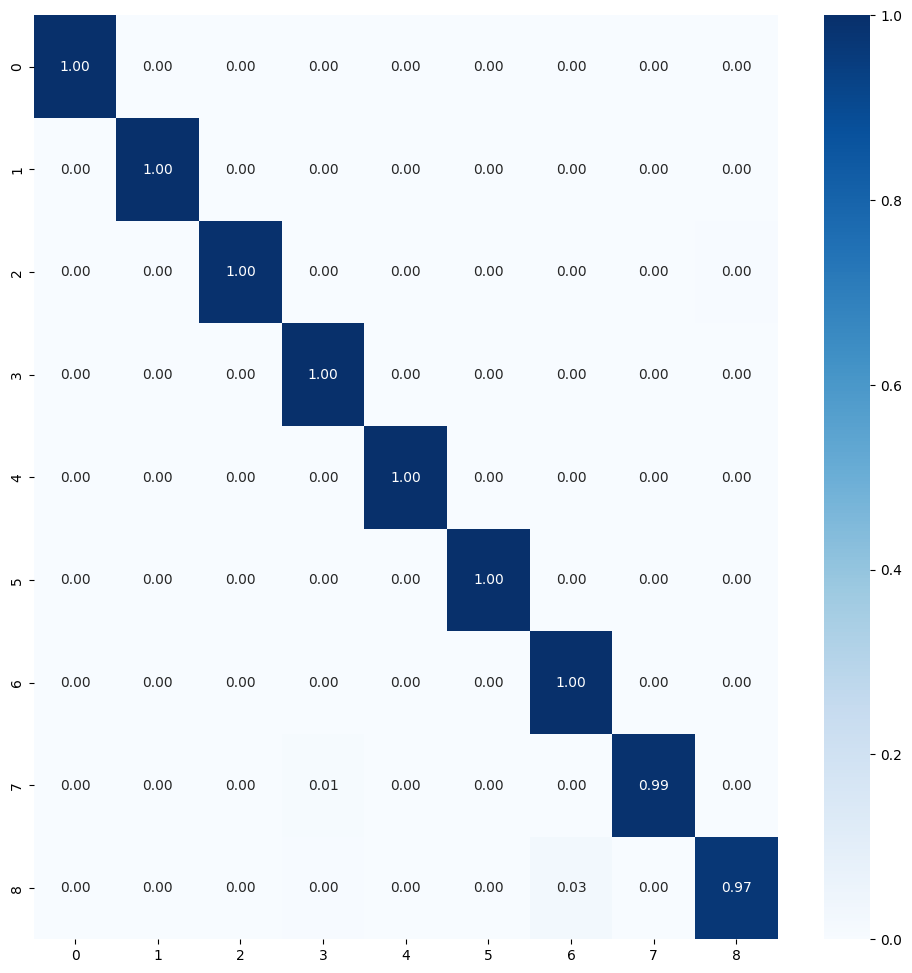


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822537
Trainable params: 1645321
Non-trainable params: 2177216
Epoch 1/50
295/295 [==============================] - 65s 180ms/step - loss: 1.2586 - accuracy: 0.8825 - val_loss: 0.9696 - val_accuracy: 0.9712
Epoch 2/50
295/295 [==============================] - 51s 171ms/step - loss: 0.9448 - accuracy: 0.9758 - val_loss: 0.8933 - val_accuracy: 0.9911
Epoch 3/50
295/295 [==============================] - 51s 172ms/step - loss: 0.8853 - accuracy: 0.9877 - val_loss: 0.8591 - val_accuracy: 0.9921
Epoch 4/50
295/295 [==============================] - 52s 175ms/step - loss: 0.8431 - accuracy: 0.9934 - val_loss: 0.8251 - val_accuracy: 0.9945
Epoch 5/50
295/295 [==============================] - 52s 177ms/step - loss: 0.8044 - accuracy: 0.9935 - val_loss: 0.7911 - val_accuracy: 0.9945
Epoch 6/50
295/295 [==============================] - 52s 174ms/step - loss: 0.7619 - accuracy: 0.9959 - val_loss: 0.7470 - val_accuracy: 0.9960
Epoch 7/50
295

History for fold 5 saved...
296/296 [==============================] - 34s 112ms/step - loss: 0.0097 - accuracy: 0.9997
Train Accuracy: 0.9996825456619263
Train Log Loss: 0.009697288274765015
64/64 [==============================] - 7s 111ms/step - loss: 0.0300 - accuracy: 0.9946
Validation Accuracy: 0.9945679306983948
Validation Log Loss: 0.03002568520605564
64/64 [==============================] - 7s 109ms/step - loss: 0.0351 - accuracy: 0.9931
Test Accuracy: 0.9930863976478577
Test Log Loss: 0.0350688099861145
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 221   1   3   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 220   0   5]
 [  0   0   0   2   0   0   0 223   0]
 [  0 

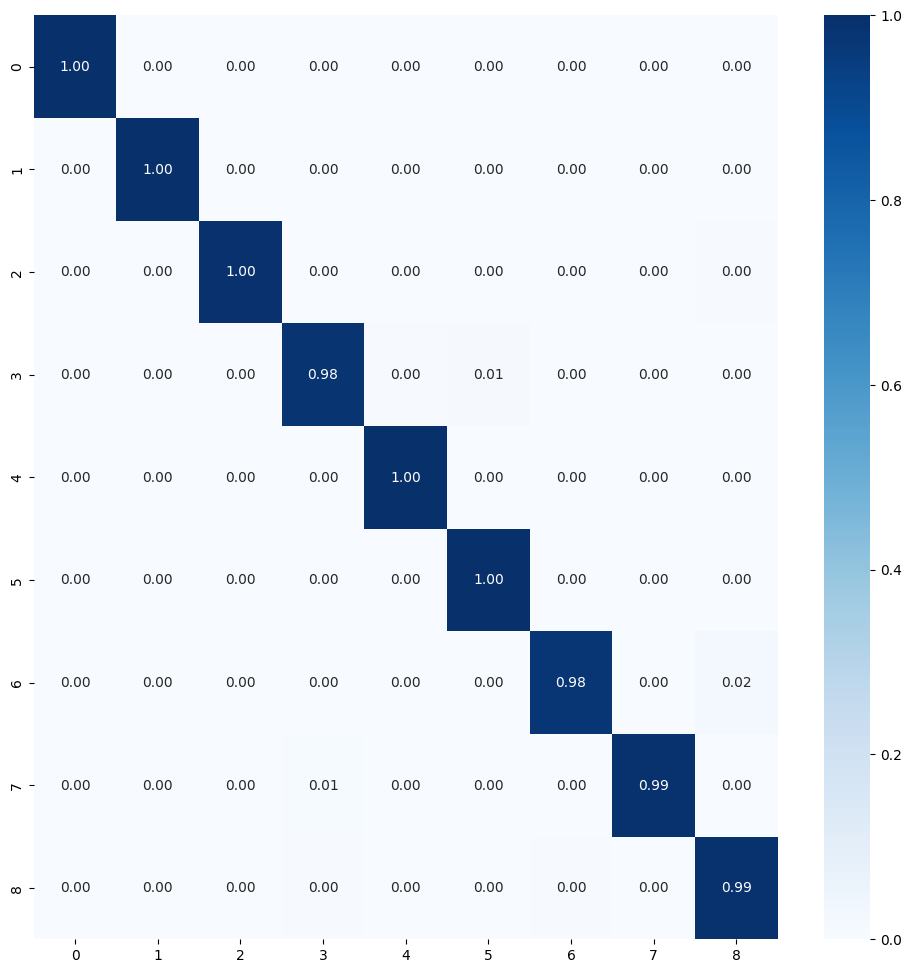


Best fold was 4 with val_accuracy: 0.9970
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9965277910232544

Test Metrics
test_acc_list: [0.9965432286262512, 0.9960494041442871, 0.9970370531082153, 0.9950617551803589, 0.9930863976478577]
Average Test Accuracy with 5-fold: 0.9955555677413941
test_loss_list: [0.032241757959127426, 0.03917011246085167, 0.037024736404418945, 0.04135897755622864, 0.0350688099861145]
Average Test Log Loss with 5-fold: 0.036972878873348235

Precision List: [0.9965755228913125, 0.9960774403296395, 0.9970608030714665, 0.9951446521381633, 0.9931443010132184]
Average Precision List with 5-fold: 0.9956005438887601
Recall List: [0.9965432098765432, 0.9960493827160494, 0.9970370370370369, 0.9950617283950618, 0.9930864197530865]
Average Recall List with 5-fold: 0.9955555555555555
F1 Score List: [0.996541980817145, 0.9960481657209167, 0.9970369640052872, 0.9950566792758175, 0.9930893856354341]
Average F1 Score List with 5-fold: 0.995

In [24]:
%%time

num_classes = 9
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

In [16]:
test_acc_list_all = [1.0, 1.0, 0.9973333239555359, 0.9907555460929871, 0.993925929069519, 0.9946666717529297, 0.9951111197471618, 0.9955555677413941]
test_loss_list_all = [0.10236843526363373, 0.033439606055617334, 0.048529957234859464, 0.21255553066730498, 0.05941887274384498, 0.04939214885234833, 0.03892153464257717, 0.036972878873348235]
precision_list_all = [1.0, 1.0, 0.9973470297732753, 0.9910939844819658, 0.9940201784127108, 0.9946939102184389, 0.995169743427607, 0.9956005438887601]
recall_list_all = [1.0, 1.0, 0.9973333333333333, 0.9907555555555556, 0.9939259259259261, 0.9946666666666667, 0.9951111111111113, 0.9955555555555555]
f1_score_list_all = [1.0, 1.0, 0.9973333004109698, 0.9907402142877786, 0.9939220002452224, 0.9946682620527028, 0.9951156242988295, 0.99555463509092]

Familias de malware copiadas
source2: /notebooks/train3/all_malware/10
name_save_model: MobileNet_tf_150010
Found 10500 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac

TRAINING AND EVALUATING FOLD 1/5...



2025-06-03 02:02:33.589724: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21490 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1d:00.0, compute capability: 8.6


Total params: 3822666
Trainable params: 1645450
Non-trainable params: 2177216
Epoch 1/50


2025-06-03 02:02:37.754549: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-06-03 02:02:40.075956: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f3fb6bf6f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-03 02:02:40.076016: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-06-03 02:02:40.088245: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748916160.217363     373 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


328/328 [==============================] - 31s 74ms/step - loss: 1.4943 - accuracy: 0.8023 - val_loss: 1.0797 - val_accuracy: 0.9308
Epoch 2/50
328/328 [==============================] - 36s 109ms/step - loss: 1.0917 - accuracy: 0.9229 - val_loss: 0.9990 - val_accuracy: 0.9536
Epoch 3/50
328/328 [==============================] - 50s 152ms/step - loss: 1.0104 - accuracy: 0.9431 - val_loss: 0.9602 - val_accuracy: 0.9616
Epoch 4/50
328/328 [==============================] - 52s 156ms/step - loss: 0.9617 - accuracy: 0.9525 - val_loss: 0.9207 - val_accuracy: 0.9665
Epoch 5/50
328/328 [==============================] - 50s 154ms/step - loss: 0.9175 - accuracy: 0.9595 - val_loss: 0.8900 - val_accuracy: 0.9665
Epoch 6/50
328/328 [==============================] - 51s 156ms/step - loss: 0.8690 - accuracy: 0.9681 - val_loss: 0.8682 - val_accuracy: 0.9679
Epoch 7/50
328/328 [==============================] - 51s 154ms/step - loss: 0.8317 - accuracy: 0.9716 - val_loss: 0.8611 - val_accuracy: 0.95

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
329/329 [==============================] - 42s 125ms/step - loss: 0.0548 - accuracy: 0.9930
Train Accuracy: 0.9930475950241089
Train Log Loss: 0.054835252463817596
71/71 [==============================] - 10s 124ms/step - loss: 0.2498 - accuracy: 0.9538
Validation Accuracy: 0.9537777900695801
Validation Log Loss: 0.24981527030467987
71/71 [==============================] - 9s 122ms/step - loss: 0.2149 - accuracy: 0.9591
Test Accuracy: 0.9591110944747925
Test Log Loss: 0.21490143239498138
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 222   0   0   0   0   0   3]
 [  0   0   0   0 211   0   0   0   0  14]
 [  0   0   0   0   0 222   0   0   0   3]
 [  0   0   0   0   0   0 183   0   0  42]
 

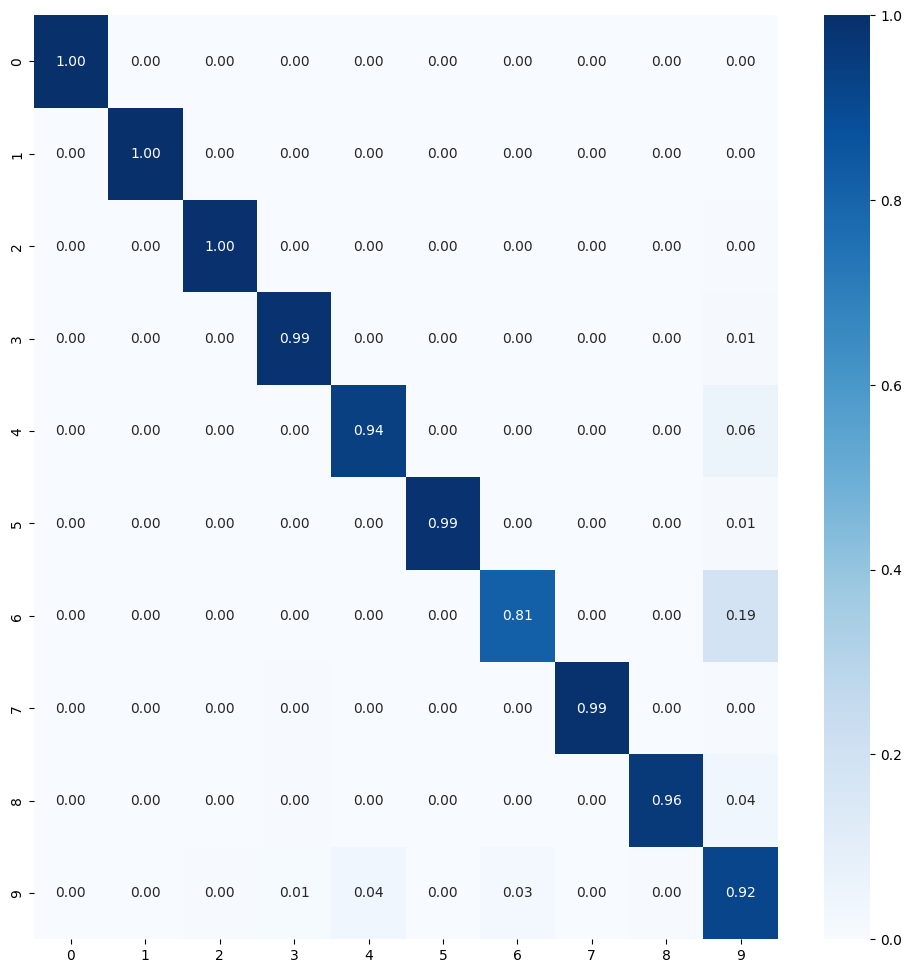


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822666
Trainable params: 1645450
Non-trainable params: 2177216
Epoch 1/50
328/328 [==============================] - 64s 166ms/step - loss: 1.4742 - accuracy: 0.8083 - val_loss: 1.0785 - val_accuracy: 0.9362
Epoch 2/50
328/328 [==============================] - 52s 159ms/step - loss: 1.0945 - accuracy: 0.9230 - val_loss: 0.9961 - val_accuracy: 0.9571
Epoch 3/50
328/328 [==============================] - 51s 154ms/step - loss: 1.0222 - accuracy: 0.9410 - val_loss: 0.9609 - val_accuracy: 0.9603
Epoch 4/50
328/328 [==============================] - 51s 155ms/step - loss: 0.9580 - accuracy: 0.9530 - val_loss: 0.9417 - val_accuracy: 0.9621
Epoch 5/50
328/328 [==============================] - 52s 157ms/step - loss: 0.9134 - accuracy: 0.9619 - val_loss: 0.8907 - val_accuracy: 0.9710
Epoch 6/50
328/328 [==============================] - 49s 150ms/step - loss: 0.8781 - accuracy: 0.9635 - val_loss: 0.8747 - val_accuracy: 0.9638
Epoch 7/50
328

History for fold 2 saved...
329/329 [==============================] - 35s 105ms/step - loss: 0.0411 - accuracy: 0.9997
Train Accuracy: 0.9997143149375916
Train Log Loss: 0.04111713171005249
71/71 [==============================] - 4s 50ms/step - loss: 0.1965 - accuracy: 0.9702
Validation Accuracy: 0.9702222347259521
Validation Log Loss: 0.19649799168109894
71/71 [==============================] - 8s 117ms/step - loss: 0.1820 - accuracy: 0.9698
Test Accuracy: 0.9697777628898621
Test Log Loss: 0.1820431351661682
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[224   0   0   0   0   0   0   0   0   1]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 214   0   0   0   0  11]
 [  0   0   0   0   0 224   0   0   0   1]
 [  0   0   0   0   0   0 218   0   0   7]
 [  0

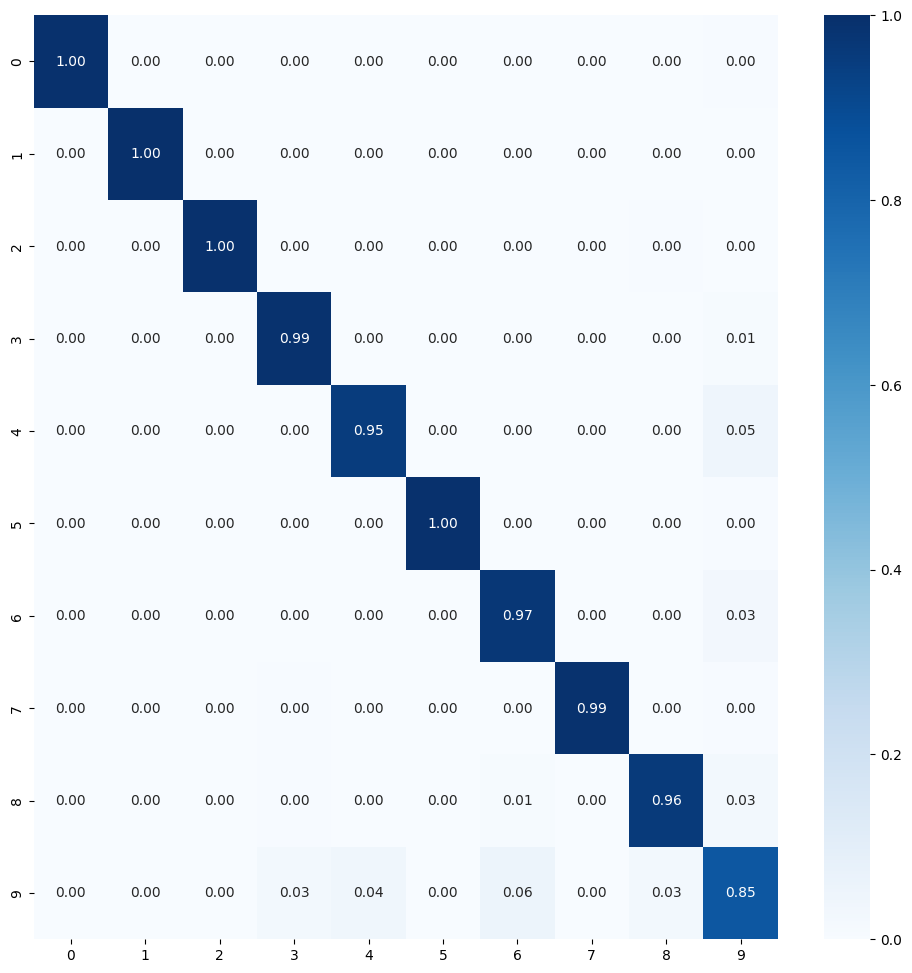


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822666
Trainable params: 1645450
Non-trainable params: 2177216
Epoch 1/50
328/328 [==============================] - 63s 162ms/step - loss: 1.4948 - accuracy: 0.8115 - val_loss: 1.1266 - val_accuracy: 0.9013
Epoch 2/50
328/328 [==============================] - 52s 157ms/step - loss: 1.1136 - accuracy: 0.9158 - val_loss: 0.9989 - val_accuracy: 0.9536
Epoch 3/50
328/328 [==============================] - 51s 154ms/step - loss: 1.0263 - accuracy: 0.9395 - val_loss: 0.9707 - val_accuracy: 0.9540
Epoch 4/50
328/328 [==============================] - 50s 154ms/step - loss: 0.9743 - accuracy: 0.9500 - val_loss: 0.9345 - val_accuracy: 0.9580
Epoch 5/50
328/328 [==============================] - 51s 153ms/step - loss: 0.9193 - accuracy: 0.9606 - val_loss: 0.9076 - val_accuracy: 0.9598
Epoch 6/50
328/328 [==============================] - 52s 155ms/step - loss: 0.8845 - accuracy: 0.9640 - val_loss: 0.8847 - val_accuracy: 0.9576
Epoch 7/50
328

History for fold 3 saved...
329/329 [==============================] - 42s 126ms/step - loss: 0.0500 - accuracy: 0.9997
Train Accuracy: 0.9997143149375916
Train Log Loss: 0.0499936044216156
71/71 [==============================] - 9s 127ms/step - loss: 0.1973 - accuracy: 0.9676
Validation Accuracy: 0.967555582523346
Validation Log Loss: 0.1972811371088028
71/71 [==============================] - 10s 125ms/step - loss: 0.1822 - accuracy: 0.9720
Test Accuracy: 0.972000002861023
Test Log Loss: 0.18221932649612427
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 224   0   0   0   0   0   1]
 [  0   0   0   0 213   0   0   0   0  12]
 [  0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0 216   0   1   8]
 [  0 

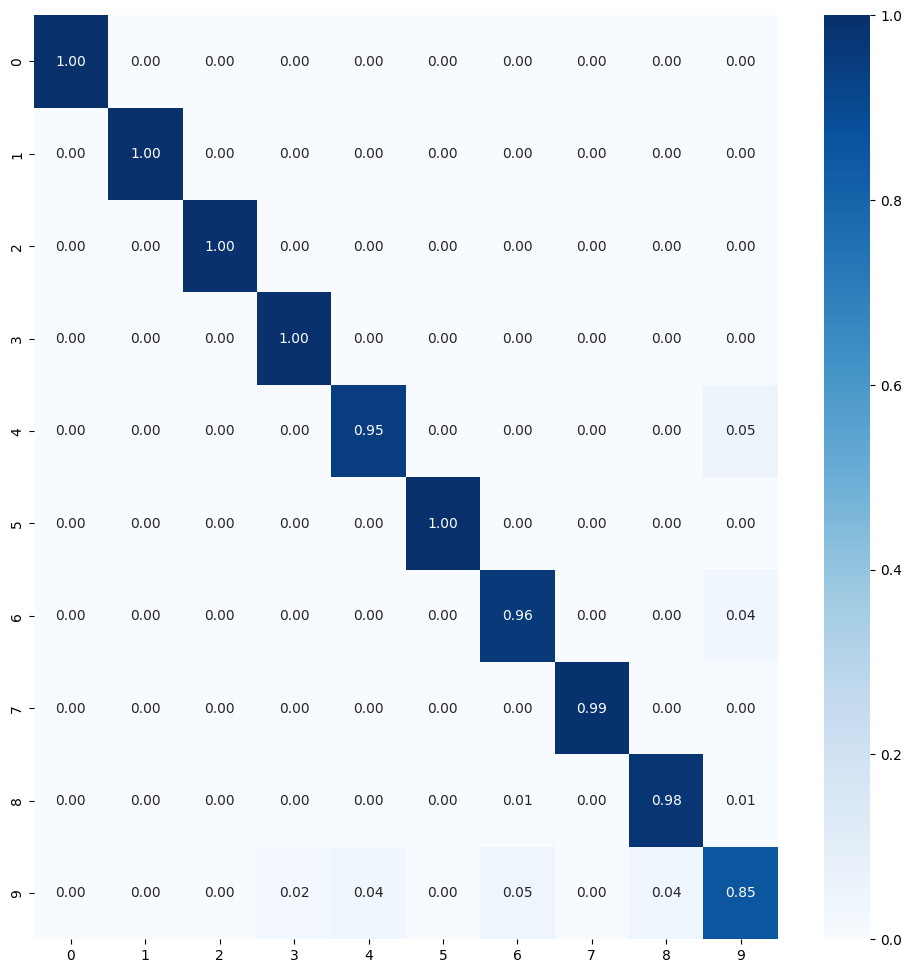


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822666
Trainable params: 1645450
Non-trainable params: 2177216
Epoch 1/50
328/328 [==============================] - 62s 159ms/step - loss: 1.4950 - accuracy: 0.7968 - val_loss: 1.0737 - val_accuracy: 0.9357
Epoch 2/50
328/328 [==============================] - 51s 156ms/step - loss: 1.1065 - accuracy: 0.9210 - val_loss: 0.9933 - val_accuracy: 0.9549
Epoch 3/50
328/328 [==============================] - 50s 152ms/step - loss: 1.0212 - accuracy: 0.9428 - val_loss: 0.9768 - val_accuracy: 0.9522
Epoch 4/50
328/328 [==============================] - 51s 155ms/step - loss: 0.9650 - accuracy: 0.9524 - val_loss: 0.9304 - val_accuracy: 0.9656
Epoch 5/50
328/328 [==============================] - 50s 152ms/step - loss: 0.9279 - accuracy: 0.9582 - val_loss: 0.9037 - val_accuracy: 0.9607
Epoch 6/50
328/328 [==============================] - 52s 157ms/step - loss: 0.8814 - accuracy: 0.9664 - val_loss: 0.8748 - val_accuracy: 0.9629
Epoch 7/50
328

History for fold 4 saved...
329/329 [==============================] - 44s 133ms/step - loss: 0.0567 - accuracy: 0.9943
Train Accuracy: 0.9942857027053833
Train Log Loss: 0.0566878616809845
71/71 [==============================] - 10s 133ms/step - loss: 0.2338 - accuracy: 0.9644
Validation Accuracy: 0.9644444584846497
Validation Log Loss: 0.23382291197776794
71/71 [==============================] - 10s 136ms/step - loss: 0.2308 - accuracy: 0.9631
Test Accuracy: 0.9631111025810242
Test Log Loss: 0.23082061111927032
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 221   0   1   1   0   0   2]
 [  0   0   0   0 219   0   0   0   0   6]
 [  0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0 225   0   0   0]
 [

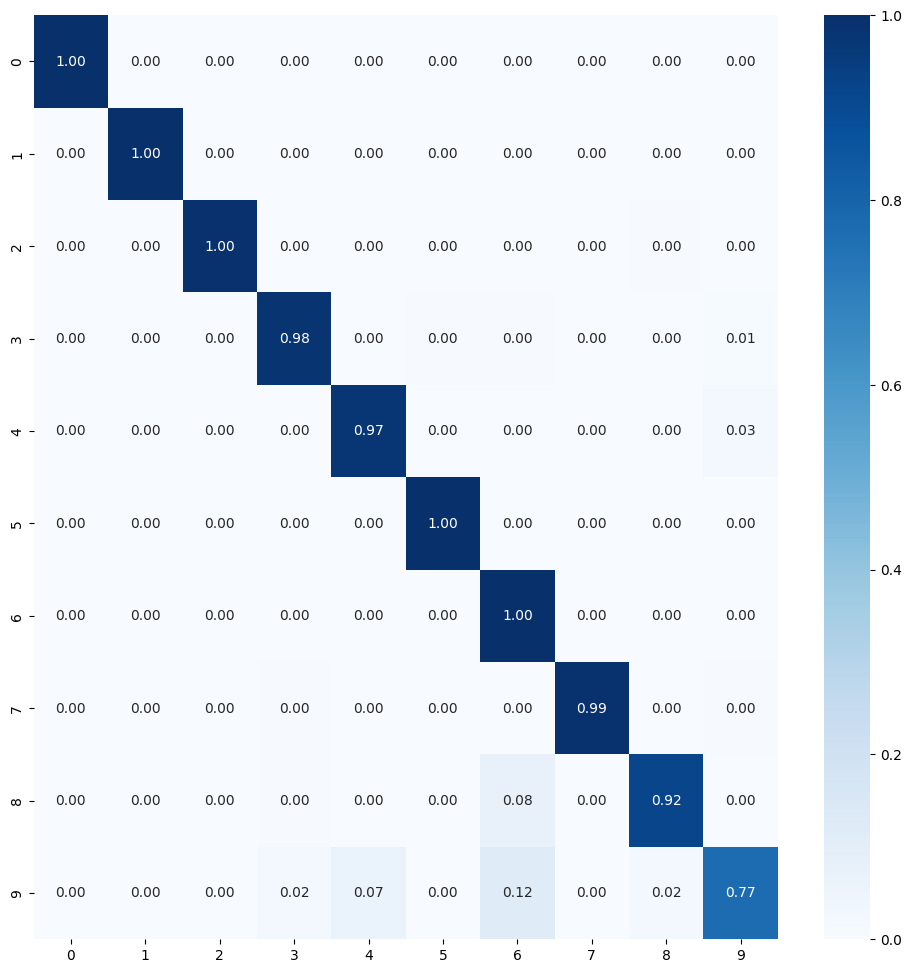


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822666
Trainable params: 1645450
Non-trainable params: 2177216
Epoch 1/50
328/328 [==============================] - 66s 171ms/step - loss: 1.4574 - accuracy: 0.8095 - val_loss: 1.0953 - val_accuracy: 0.9295
Epoch 2/50
328/328 [==============================] - 54s 165ms/step - loss: 1.1085 - accuracy: 0.9163 - val_loss: 1.0018 - val_accuracy: 0.9518
Epoch 3/50
328/328 [==============================] - 55s 168ms/step - loss: 1.0164 - accuracy: 0.9426 - val_loss: 0.9582 - val_accuracy: 0.9567
Epoch 4/50
328/328 [==============================] - 53s 162ms/step - loss: 0.9675 - accuracy: 0.9511 - val_loss: 0.9293 - val_accuracy: 0.9621
Epoch 5/50
328/328 [==============================] - 52s 160ms/step - loss: 0.9180 - accuracy: 0.9593 - val_loss: 0.9073 - val_accuracy: 0.9580
Epoch 6/50
328/328 [==============================] - 54s 162ms/step - loss: 0.8760 - accuracy: 0.9683 - val_loss: 0.8796 - val_accuracy: 0.9616
Epoch 7/50
328

History for fold 5 saved...
329/329 [==============================] - 42s 126ms/step - loss: 0.0433 - accuracy: 0.9995
Train Accuracy: 0.9995238184928894
Train Log Loss: 0.04329552501440048
71/71 [==============================] - 10s 127ms/step - loss: 0.1955 - accuracy: 0.9671
Validation Accuracy: 0.9671111106872559
Validation Log Loss: 0.19553722441196442
71/71 [==============================] - 10s 136ms/step - loss: 0.1711 - accuracy: 0.9738
Test Accuracy: 0.9737777709960938
Test Log Loss: 0.17105422914028168
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 222   0   0   1   0   0   2]
 [  0   0   0   0 219   0   0   0   0   6]
 [  0   0   0   0   0 224   0   0   0   1]
 [  0   0   0   0   0   0 215   0   0  10]
 

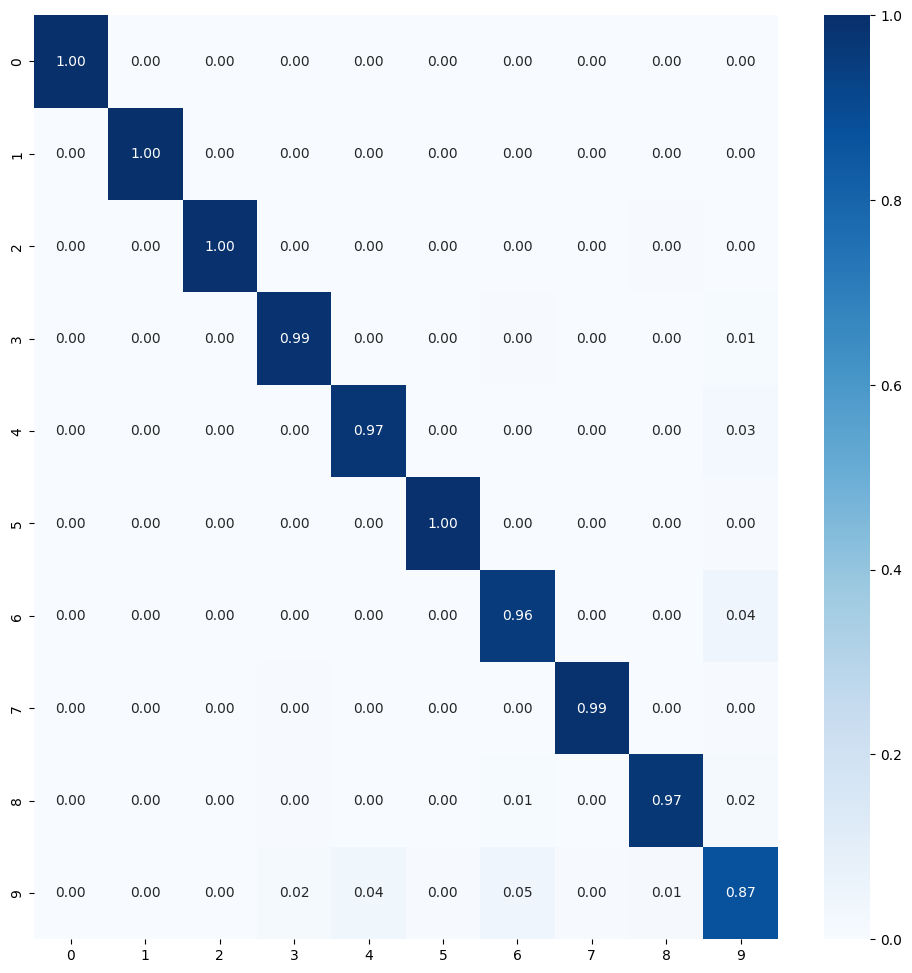


Best fold was 1 with val_accuracy: 0.9728
Average training accuracy in 5-fold: 0.9981276273727417
Average validation precision in 5-fold: 0.9723214268684387

Test Metrics
test_acc_list: [0.9591110944747925, 0.9697777628898621, 0.972000002861023, 0.9631111025810242, 0.9737777709960938]
Average Test Accuracy with 5-fold: 0.9675555467605591
test_loss_list: [0.21490143239498138, 0.1820431351661682, 0.18221932649612427, 0.23082061111927032, 0.17105422914028168]
Average Test Log Loss with 5-fold: 0.19620774686336517

Precision List: [0.9646907917340071, 0.9697423222222582, 0.9717879186888906, 0.9656484672548687, 0.9737057497869092]
Average Precision List with 5-fold: 0.9691150499373867
Recall List: [0.9591111111111111, 0.9697777777777778, 0.9720000000000001, 0.963111111111111, 0.9737777777777777]
Average Recall List with 5-fold: 0.9675555555555555
F1 Score List: [0.9602171354648119, 0.9696959264184872, 0.9718267943730539, 0.9625476291865773, 0.9737093676298982]
Average F1 Score List with 5-

In [17]:
%%time

num_classes = 10
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/11
name_save_model: MobileNet_tf_150011
Found 11550 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822795
Trainable params: 1645579
Non-trainable params: 2177216
Epoch 1/50
360/360 [==============================] - 88s 207ms/step - loss: 1.5994 - accuracy: 0.7637 - val_loss: 1.1876 - val_accuracy: 0.8876
Epoch 2/50
360/360 [==============================] - 70s 195ms/step - loss: 1.2001 - accuracy: 0.8775 - val_loss: 1.0723 - val_accuracy: 0.9196
Epoch 3/50
360/360 [==============================] - 70s 194ms/step - loss: 1.1061 - accuracy: 0.9040 - val_loss: 1.0291 - val_accuracy: 0.9257
Epoch 4/50
360/360 [==============================] - 59

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
361/361 [==============================] - 46s 125ms/step - loss: 0.0653 - accuracy: 0.9940
Train Accuracy: 0.9940259456634521
Train Log Loss: 0.06525871157646179
78/78 [==============================] - 10s 121ms/step - loss: 0.3819 - accuracy: 0.9422
Validation Accuracy: 0.9422222375869751
Validation Log Loss: 0.3818834722042084
78/78 [==============================] - 10s 127ms/step - loss: 0.3225 - accuracy: 0.9491
Test Accuracy: 0.9490908980369568
Test Log Loss: 0.3225032091140747
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 224   1   0   0   0   0   0   0]
 [  0   0   0   1 209   4   0   0   0   0  11]
 [  0   0   0   0  19 203   0   0   0   0   3]
 [  0   

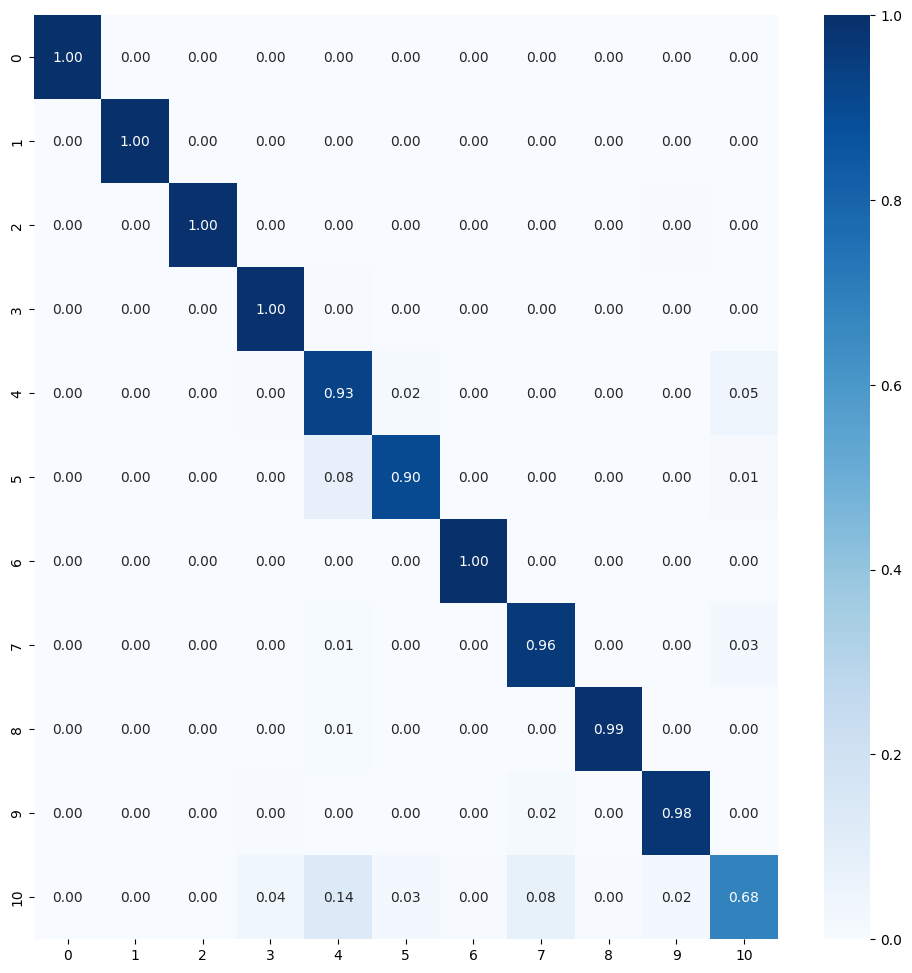


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822795
Trainable params: 1645579
Non-trainable params: 2177216
Epoch 1/50
360/360 [==============================] - 69s 165ms/step - loss: 1.6637 - accuracy: 0.7537 - val_loss: 1.1849 - val_accuracy: 0.8791
Epoch 2/50
360/360 [==============================] - 56s 156ms/step - loss: 1.2176 - accuracy: 0.8752 - val_loss: 1.0751 - val_accuracy: 0.9160
Epoch 3/50
360/360 [==============================] - 55s 153ms/step - loss: 1.1077 - accuracy: 0.9054 - val_loss: 1.0301 - val_accuracy: 0.9241
Epoch 4/50
360/360 [==============================] - 55s 153ms/step - loss: 1.0421 - accuracy: 0.9173 - val_loss: 0.9885 - val_accuracy: 0.9302
Epoch 5/50
360/360 [==============================] - 55s 153ms/step - loss: 0.9845 - accuracy: 0.9303 - val_loss: 0.9498 - val_accuracy: 0.9338
Epoch 6/50
360/360 [==============================] - 54s 151ms/step - loss: 0.9391 - accuracy: 0.9386 - val_loss: 0.9243 - val_accuracy: 0.9383
Epoch 7/50
360

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 2 saved...
361/361 [==============================] - 47s 131ms/step - loss: 0.0820 - accuracy: 0.9881
Train Accuracy: 0.9880519509315491
Train Log Loss: 0.08199562877416611
78/78 [==============================] - 10s 126ms/step - loss: 0.3364 - accuracy: 0.9394
Validation Accuracy: 0.939393937587738
Validation Log Loss: 0.3363569974899292
78/78 [==============================] - 10s 125ms/step - loss: 0.2979 - accuracy: 0.9495
Test Accuracy: 0.9494949579238892
Test Log Loss: 0.2978746294975281
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[224   0   0   0   1   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 223   1   0   0   0   0   0   1]
 [  0   0   0   0 218   2   0   0   0   0   5]
 [  0   0   0   0  28 192   0   0   0   0   5]
 [  0   0

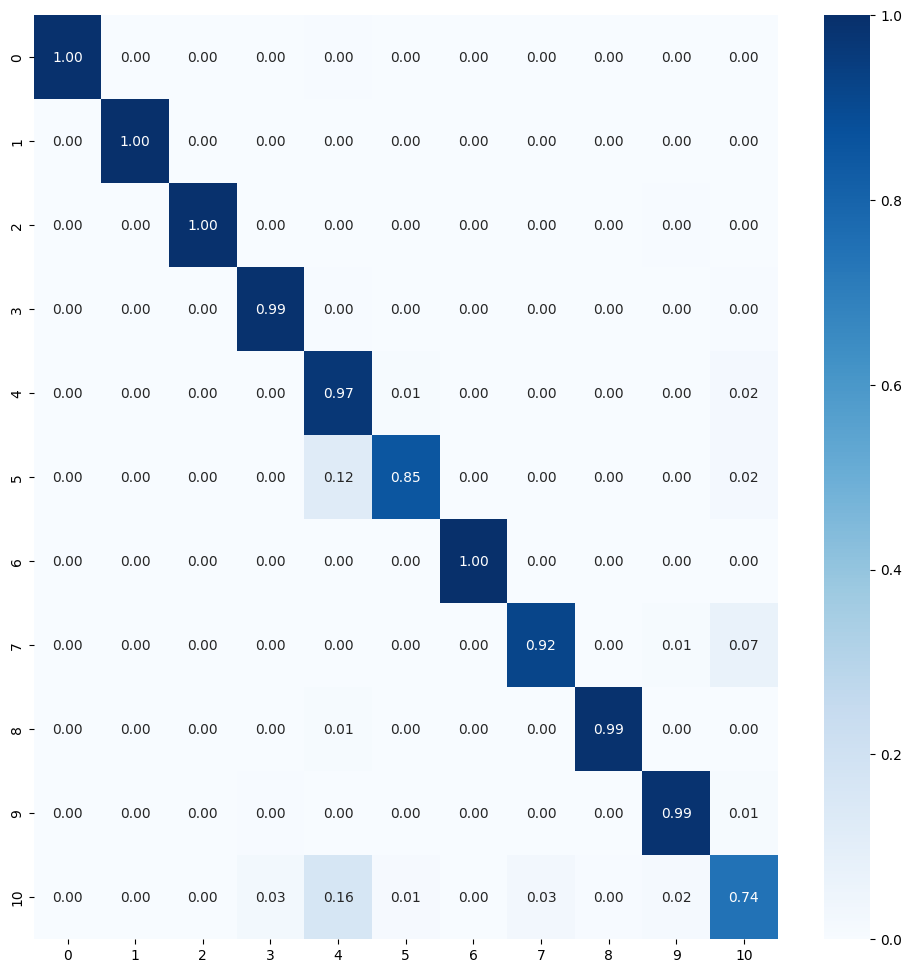


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822795
Trainable params: 1645579
Non-trainable params: 2177216
Epoch 1/50
360/360 [==============================] - 69s 161ms/step - loss: 1.6360 - accuracy: 0.7567 - val_loss: 1.1713 - val_accuracy: 0.8925
Epoch 2/50
360/360 [==============================] - 57s 156ms/step - loss: 1.2076 - accuracy: 0.8801 - val_loss: 1.0713 - val_accuracy: 0.9180
Epoch 3/50
360/360 [==============================] - 59s 164ms/step - loss: 1.1114 - accuracy: 0.9043 - val_loss: 1.0329 - val_accuracy: 0.9253
Epoch 4/50
360/360 [==============================] - 75s 207ms/step - loss: 1.0454 - accuracy: 0.9219 - val_loss: 1.0049 - val_accuracy: 0.9322
Epoch 5/50
360/360 [==============================] - 67s 182ms/step - loss: 0.9959 - accuracy: 0.9323 - val_loss: 0.9876 - val_accuracy: 0.9290
Epoch 6/50
360/360 [==============================] - 64s 178ms/step - loss: 0.9455 - accuracy: 0.9412 - val_loss: 0.9610 - val_accuracy: 0.9294
Epoch 7/50
360

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 3 saved...
361/361 [==============================] - 34s 95ms/step - loss: 0.0658 - accuracy: 0.9953
Train Accuracy: 0.9953246712684631
Train Log Loss: 0.065806083381176
78/78 [==============================] - 10s 122ms/step - loss: 0.2947 - accuracy: 0.9479
Validation Accuracy: 0.9478787779808044
Validation Log Loss: 0.29469066858291626
78/78 [==============================] - 10s 123ms/step - loss: 0.2823 - accuracy: 0.9519
Test Accuracy: 0.9519191980361938
Test Log Loss: 0.28233790397644043
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 219   1   1   1   1   0   0   2]
 [  0   0   0   0 206   7   0   0   0   0  12]
 [  0   0   0   0  13 206   0   0   0   0   6]
 [  0   0

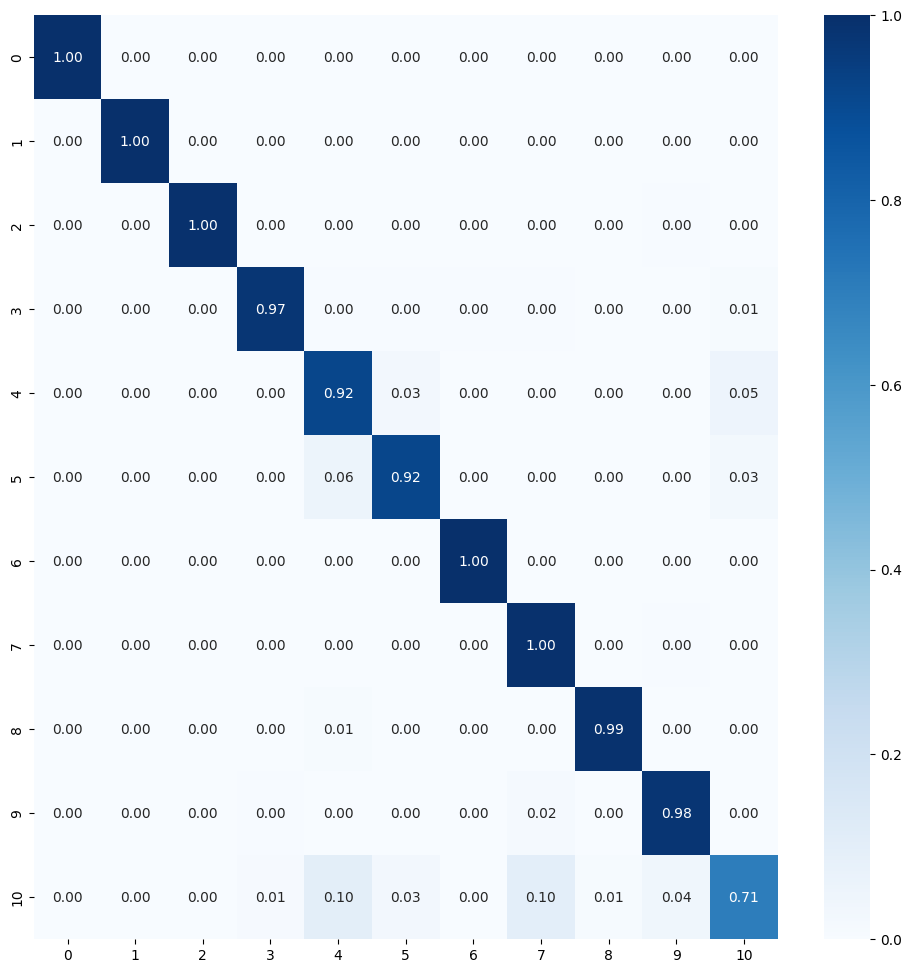


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822795
Trainable params: 1645579
Non-trainable params: 2177216
Epoch 1/50
360/360 [==============================] - 67s 158ms/step - loss: 1.6576 - accuracy: 0.7570 - val_loss: 1.1841 - val_accuracy: 0.8973
Epoch 2/50
360/360 [==============================] - 56s 155ms/step - loss: 1.2090 - accuracy: 0.8807 - val_loss: 1.0886 - val_accuracy: 0.9176
Epoch 3/50
360/360 [==============================] - 57s 156ms/step - loss: 1.1165 - accuracy: 0.9029 - val_loss: 1.0466 - val_accuracy: 0.9286
Epoch 4/50
360/360 [==============================] - 57s 158ms/step - loss: 1.0410 - accuracy: 0.9199 - val_loss: 1.0028 - val_accuracy: 0.9330
Epoch 5/50
360/360 [==============================] - 58s 160ms/step - loss: 0.9948 - accuracy: 0.9296 - val_loss: 0.9760 - val_accuracy: 0.9326
Epoch 6/50
360/360 [==============================] - 56s 156ms/step - loss: 0.9441 - accuracy: 0.9406 - val_loss: 0.9422 - val_accuracy: 0.9351
Epoch 7/50
360

History for fold 4 saved...
361/361 [==============================] - 49s 134ms/step - loss: 0.0575 - accuracy: 0.9959
Train Accuracy: 0.9959307312965393
Train Log Loss: 0.057473424822092056
78/78 [==============================] - 11s 137ms/step - loss: 0.3330 - accuracy: 0.9390
Validation Accuracy: 0.9389898777008057
Validation Log Loss: 0.3329567015171051
78/78 [==============================] - 11s 137ms/step - loss: 0.2796 - accuracy: 0.9511
Test Accuracy: 0.9511111378669739
Test Log Loss: 0.27956268191337585
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1]
 [  0   0   0 222   0   0   1   0   0   0   2]
 [  0   0   0   0 190   6   0   0   0   0  29]
 [  0   0   0   0  11 206   0   0   0   0   8]
 [  0 

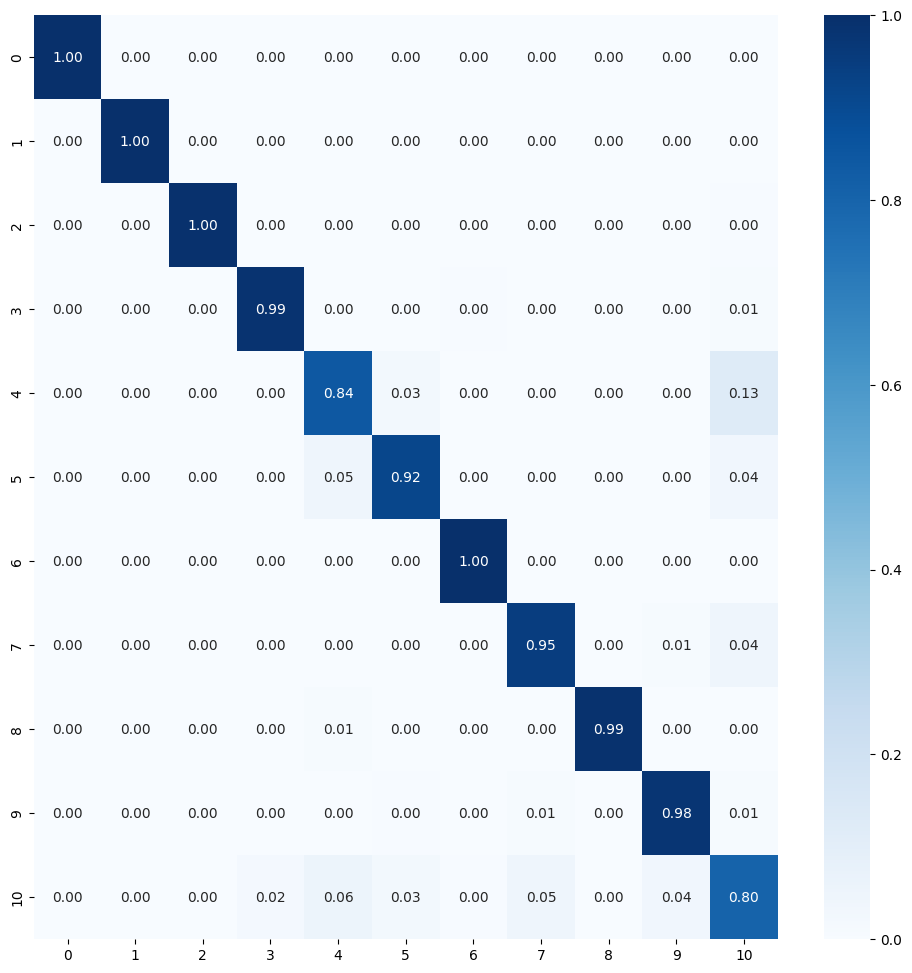


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822795
Trainable params: 1645579
Non-trainable params: 2177216
Epoch 1/50
360/360 [==============================] - 75s 171ms/step - loss: 1.6324 - accuracy: 0.7653 - val_loss: 1.1632 - val_accuracy: 0.8961
Epoch 2/50
360/360 [==============================] - 60s 167ms/step - loss: 1.2048 - accuracy: 0.8811 - val_loss: 1.0743 - val_accuracy: 0.9233
Epoch 3/50
360/360 [==============================] - 59s 163ms/step - loss: 1.1051 - accuracy: 0.9049 - val_loss: 1.0331 - val_accuracy: 0.9286
Epoch 4/50
360/360 [==============================] - 59s 164ms/step - loss: 1.0344 - accuracy: 0.9228 - val_loss: 0.9939 - val_accuracy: 0.9363
Epoch 5/50
360/360 [==============================] - 59s 164ms/step - loss: 0.9946 - accuracy: 0.9284 - val_loss: 0.9734 - val_accuracy: 0.9326
Epoch 6/50
360/360 [==============================] - 58s 161ms/step - loss: 0.9454 - accuracy: 0.9371 - val_loss: 0.9485 - val_accuracy: 0.9326
Epoch 7/50
360

History for fold 5 saved...
361/361 [==============================] - 38s 101ms/step - loss: 0.0743 - accuracy: 0.9918
Train Accuracy: 0.9917749166488647
Train Log Loss: 0.0743040069937706
78/78 [==============================] - 5s 62ms/step - loss: 0.3477 - accuracy: 0.9410
Validation Accuracy: 0.9410101175308228
Validation Log Loss: 0.347714364528656
78/78 [==============================] - 11s 129ms/step - loss: 0.3061 - accuracy: 0.9483
Test Accuracy: 0.9482828378677368
Test Log Loss: 0.30613696575164795
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1]
 [  0   0   0 221   0   0   0   0   0   0   4]
 [  0   0   0   0 214   1   0   0   0   0  10]
 [  0   0   0   0  20 201   0   0   0   0   4]
 [  0   0  

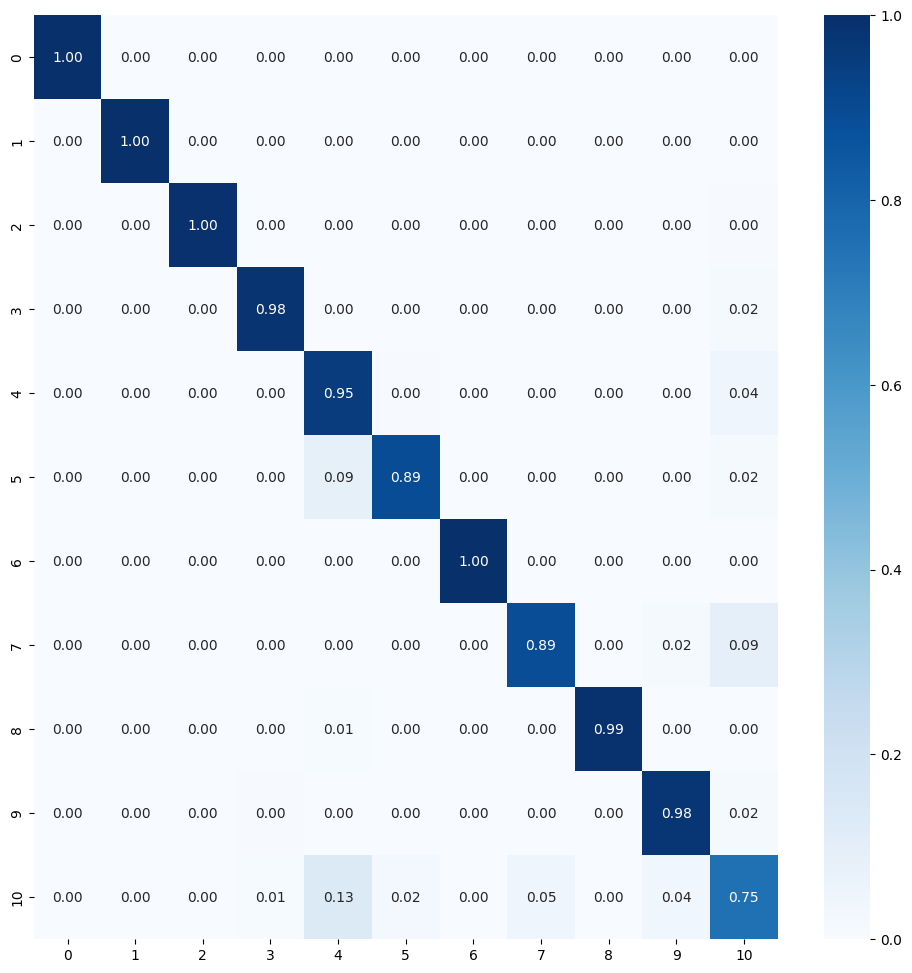


Best fold was 3 with val_accuracy: 0.9493
Average training accuracy in 5-fold: 0.9932800769805908
Average validation precision in 5-fold: 0.9469967603683471

Test Metrics
test_acc_list: [0.9490908980369568, 0.9494949579238892, 0.9519191980361938, 0.9511111378669739, 0.9482828378677368]
Average Test Accuracy with 5-fold: 0.9499798059463501
test_loss_list: [0.3225032091140747, 0.2978746294975281, 0.28233790397644043, 0.27956268191337585, 0.30613696575164795]
Average Test Log Loss with 5-fold: 0.2976830780506134

Precision List: [0.9504981203853167, 0.9534604502648546, 0.9522519566974814, 0.951386867654739, 0.9501548458636698]
Average Precision List with 5-fold: 0.9515504481732122
Recall List: [0.9490909090909092, 0.9494949494949495, 0.9519191919191919, 0.951111111111111, 0.9482828282828283]
Average Recall List with 5-fold: 0.9499797979797979
F1 Score List: [0.9479470760086515, 0.9495431052837627, 0.9507204764666256, 0.951162199007194, 0.9483532628411976]
Average F1 Score List with 5-fol

In [18]:
%%time

num_classes = 11
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/12
name_save_model: MobileNet_tf_150012
Found 12600 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822924
Trainable params: 1645708
Non-trainable params: 2177216
Epoch 1/50
393/393 [==============================] - 74s 167ms/step - loss: 1.6590 - accuracy: 0.7599 - val_loss: 1.1881 - val_accuracy: 0.8862
Epoch 2/50
393/393 [==============================] - 62s 157ms/step - loss: 1.2060 - accuracy: 0.8812 - val_loss: 1.0743 - val_accuracy: 0.9215
Epoch 3/50
393/393 [==============================] - 61s 155ms/step - loss: 1.1097 - accuracy: 0.9064 - val_loss: 1.0186 - val_accuracy: 0.9323
Epoch 4/50
393/393 [=========================

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
394/394 [==============================] - 55s 135ms/step - loss: 0.0560 - accuracy: 0.9942
Train Accuracy: 0.9942063689231873
Train Log Loss: 0.056021690368652344
85/85 [==============================] - 12s 135ms/step - loss: 0.2766 - accuracy: 0.9474
Validation Accuracy: 0.9474074244499207
Validation Log Loss: 0.27661216259002686
85/85 [==============================] - 11s 130ms/step - loss: 0.2732 - accuracy: 0.9470
Test Accuracy: 0.9470370411872864
Test Log Loss: 0.27323684096336365
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   0   0   2   0   1   0]
 [  0   0   0   0 220   2   0   0   0   0   0   3]
 [  0   0   0   

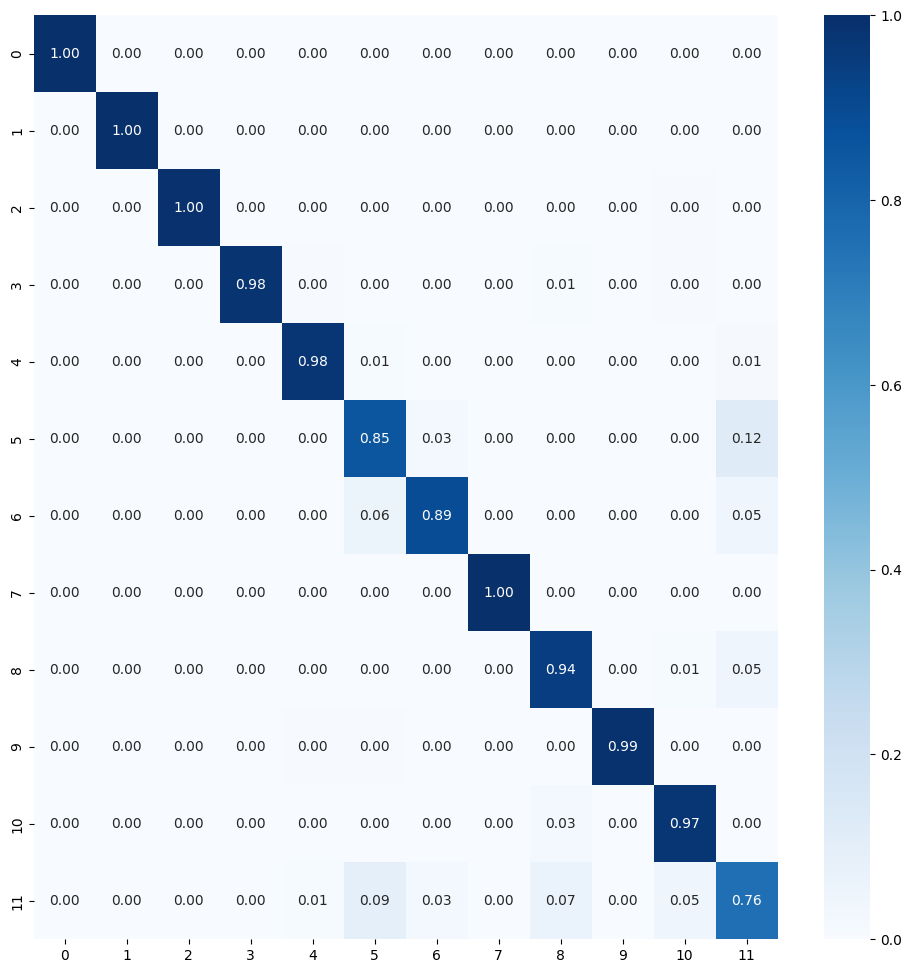


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822924
Trainable params: 1645708
Non-trainable params: 2177216
Epoch 1/50
393/393 [==============================] - 88s 195ms/step - loss: 1.6749 - accuracy: 0.7521 - val_loss: 1.1700 - val_accuracy: 0.8966
Epoch 2/50
393/393 [==============================] - 64s 163ms/step - loss: 1.2107 - accuracy: 0.8829 - val_loss: 1.0858 - val_accuracy: 0.9208
Epoch 3/50
393/393 [==============================] - 66s 166ms/step - loss: 1.1020 - accuracy: 0.9136 - val_loss: 1.0233 - val_accuracy: 0.9319
Epoch 4/50
393/393 [==============================] - 68s 173ms/step - loss: 1.0305 - accuracy: 0.9262 - val_loss: 0.9789 - val_accuracy: 0.9360
Epoch 5/50
393/393 [==============================] - 64s 161ms/step - loss: 0.9807 - accuracy: 0.9333 - val_loss: 0.9691 - val_accuracy: 0.9301
Epoch 6/50
393/393 [==============================] - 64s 163ms/step - loss: 0.9355 - accuracy: 0.9402 - val_loss: 0.9105 - val_accuracy: 0.9423
Epoch 7/50
393

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 2 saved...
394/394 [==============================] - 50s 125ms/step - loss: 0.0553 - accuracy: 0.9956
Train Accuracy: 0.995634913444519
Train Log Loss: 0.055331386625766754
85/85 [==============================] - 11s 128ms/step - loss: 0.2683 - accuracy: 0.9463
Validation Accuracy: 0.9462962746620178
Validation Log Loss: 0.2682988941669464
85/85 [==============================] - 11s 122ms/step - loss: 0.2625 - accuracy: 0.9515
Test Accuracy: 0.9514814615249634
Test Log Loss: 0.2624538540840149
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   2   0   0   0   0   0   1]
 [  0   0   0   0 221   0   0   1   0   0   0   3]
 [  0   0   0   0  

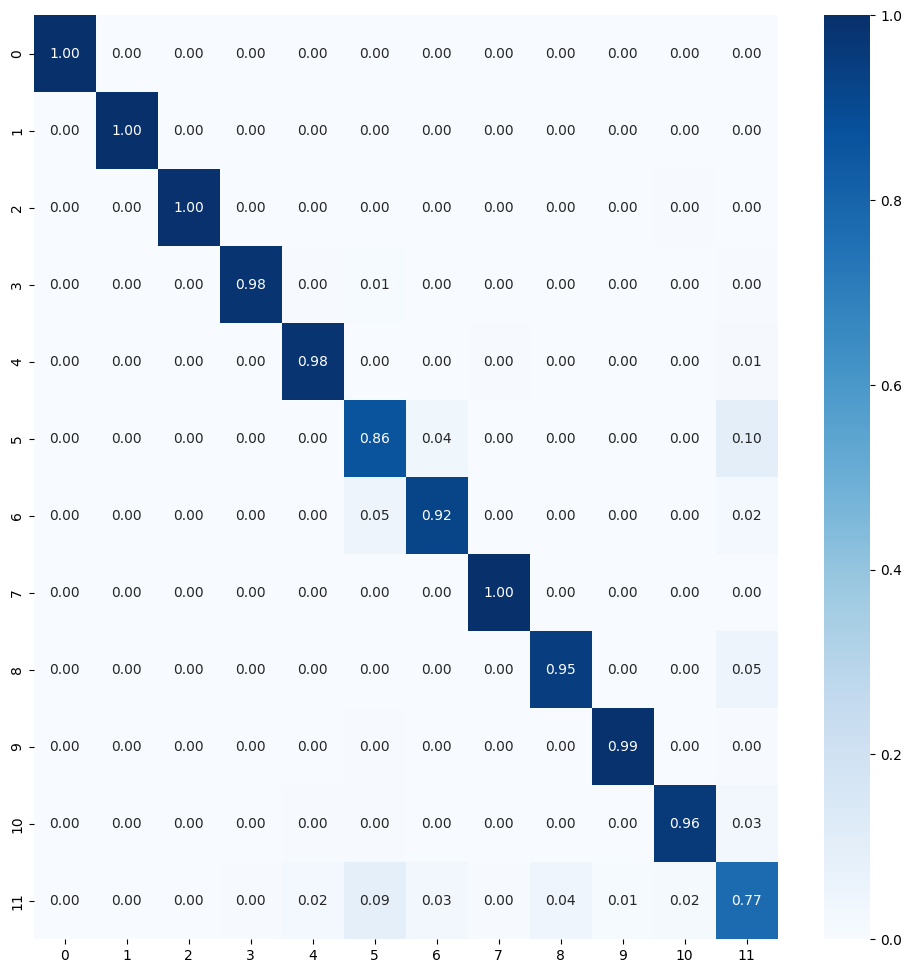


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822924
Trainable params: 1645708
Non-trainable params: 2177216
Epoch 1/50
393/393 [==============================] - 72s 159ms/step - loss: 1.6035 - accuracy: 0.7697 - val_loss: 1.1589 - val_accuracy: 0.9025
Epoch 2/50
393/393 [==============================] - 72s 182ms/step - loss: 1.1909 - accuracy: 0.8867 - val_loss: 1.0578 - val_accuracy: 0.9271
Epoch 3/50
393/393 [==============================] - 62s 156ms/step - loss: 1.0844 - accuracy: 0.9127 - val_loss: 1.0187 - val_accuracy: 0.9327
Epoch 4/50
393/393 [==============================] - 61s 155ms/step - loss: 1.0266 - accuracy: 0.9243 - val_loss: 0.9772 - val_accuracy: 0.9345
Epoch 5/50
393/393 [==============================] - 60s 152ms/step - loss: 0.9651 - accuracy: 0.9352 - val_loss: 0.9486 - val_accuracy: 0.9349
Epoch 6/50
393/393 [==============================] - 61s 154ms/step - loss: 0.9239 - accuracy: 0.9411 - val_loss: 0.9106 - val_accuracy: 0.9401
Epoch 7/50
393

History for fold 3 saved...
394/394 [==============================] - 52s 132ms/step - loss: 0.0558 - accuracy: 0.9941
Train Accuracy: 0.9941269755363464
Train Log Loss: 0.05580531433224678
85/85 [==============================] - 12s 126ms/step - loss: 0.3142 - accuracy: 0.9426
Validation Accuracy: 0.9425926208496094
Validation Log Loss: 0.31415295600891113
85/85 [==============================] - 11s 130ms/step - loss: 0.2961 - accuracy: 0.9493
Test Accuracy: 0.9492592811584473
Test Log Loss: 0.2960576117038727
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 220   2   0   0   0   2   0   0   1]
 [  0   0   0   0 224   0   0   0   0   0   0   1]
 [  0   0   0   0 

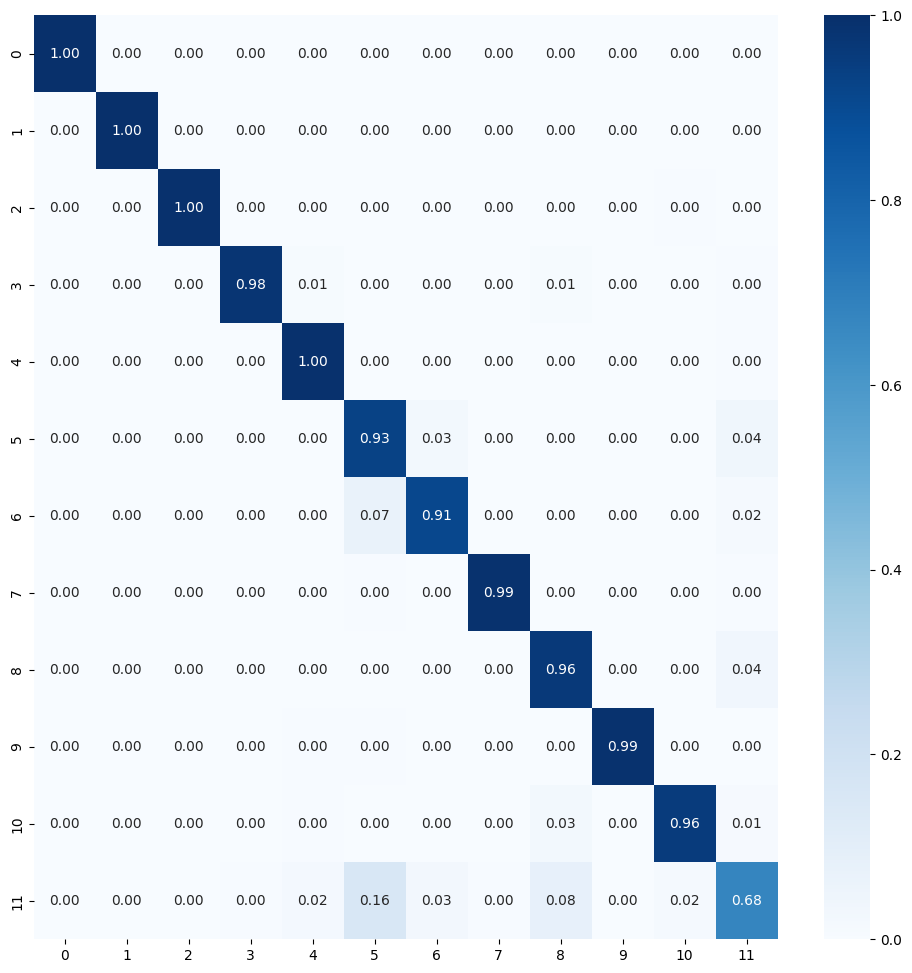


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822924
Trainable params: 1645708
Non-trainable params: 2177216
Epoch 1/50
393/393 [==============================] - 85s 190ms/step - loss: 1.6295 - accuracy: 0.7742 - val_loss: 1.1712 - val_accuracy: 0.9044
Epoch 2/50
393/393 [==============================] - 62s 157ms/step - loss: 1.2069 - accuracy: 0.8848 - val_loss: 1.0783 - val_accuracy: 0.9193
Epoch 3/50
393/393 [==============================] - 63s 159ms/step - loss: 1.0941 - accuracy: 0.9130 - val_loss: 1.0161 - val_accuracy: 0.9345
Epoch 4/50
393/393 [==============================] - 71s 179ms/step - loss: 1.0385 - accuracy: 0.9243 - val_loss: 0.9876 - val_accuracy: 0.9360
Epoch 5/50
393/393 [==============================] - 62s 156ms/step - loss: 0.9802 - accuracy: 0.9352 - val_loss: 0.9453 - val_accuracy: 0.9390
Epoch 6/50
393/393 [==============================] - 72s 183ms/step - loss: 0.9294 - accuracy: 0.9428 - val_loss: 0.9257 - val_accuracy: 0.9394
Epoch 7/50
393

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 4 saved...
394/394 [==============================] - 51s 128ms/step - loss: 0.0518 - accuracy: 0.9961
Train Accuracy: 0.9961110949516296
Train Log Loss: 0.051838263869285583
85/85 [==============================] - 10s 121ms/step - loss: 0.2775 - accuracy: 0.9489
Validation Accuracy: 0.948888897895813
Validation Log Loss: 0.2775215208530426
85/85 [==============================] - 11s 125ms/step - loss: 0.2660 - accuracy: 0.9511
Test Accuracy: 0.9511111378669739
Test Log Loss: 0.2660340666770935
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   2   1   0   0   1   0   0   0]
 [  0   0   0   0 219   0   0   4   0   0   0   2]
 [  0   0   0   0  

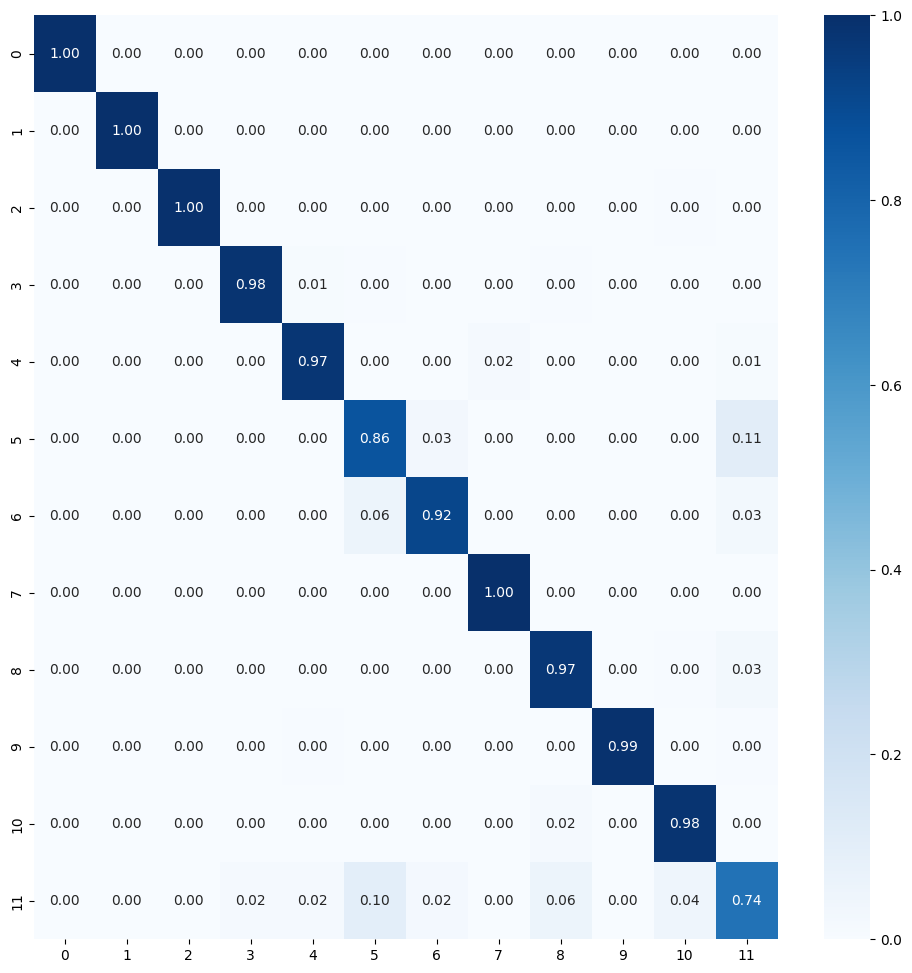


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822924
Trainable params: 1645708
Non-trainable params: 2177216
Epoch 1/50
393/393 [==============================] - 69s 151ms/step - loss: 1.6149 - accuracy: 0.7688 - val_loss: 1.1601 - val_accuracy: 0.8943
Epoch 2/50
393/393 [==============================] - 48s 120ms/step - loss: 1.2016 - accuracy: 0.8826 - val_loss: 1.0713 - val_accuracy: 0.9200
Epoch 3/50
393/393 [==============================] - 60s 151ms/step - loss: 1.0897 - accuracy: 0.9114 - val_loss: 1.0161 - val_accuracy: 0.9271
Epoch 4/50
393/393 [==============================] - 60s 150ms/step - loss: 1.0258 - accuracy: 0.9222 - val_loss: 0.9684 - val_accuracy: 0.9353
Epoch 5/50
393/393 [==============================] - 60s 153ms/step - loss: 0.9707 - accuracy: 0.9348 - val_loss: 0.9451 - val_accuracy: 0.9330
Epoch 6/50
393/393 [==============================] - 59s 149ms/step - loss: 0.9133 - accuracy: 0.9425 - val_loss: 0.9077 - val_accuracy: 0.9375
Epoch 7/50
393

History for fold 5 saved...
394/394 [==============================] - 52s 130ms/step - loss: 0.0646 - accuracy: 0.9891
Train Accuracy: 0.989126980304718
Train Log Loss: 0.06464599817991257
85/85 [==============================] - 11s 132ms/step - loss: 0.3317 - accuracy: 0.9330
Validation Accuracy: 0.932962954044342
Validation Log Loss: 0.3317258358001709
85/85 [==============================] - 11s 126ms/step - loss: 0.2896 - accuracy: 0.9437
Test Accuracy: 0.9437037110328674
Test Log Loss: 0.2896006405353546
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   2   0   0   0   1   0   0   1]
 [  0   0   0   0 219   0   0   0   1   0   0   5]
 [  0   0   0   0   0

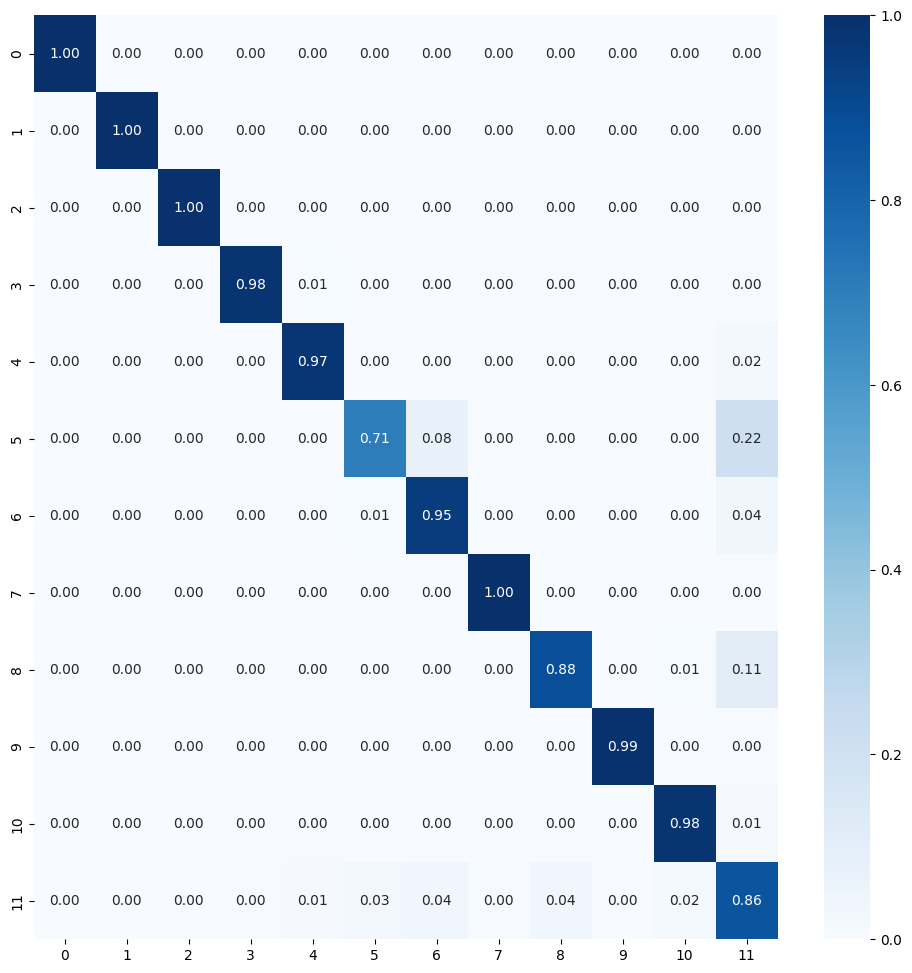


Best fold was 4 with val_accuracy: 0.9539
Average training accuracy in 5-fold: 0.9934754967689514
Average validation precision in 5-fold: 0.9522321343421936

Test Metrics
test_acc_list: [0.9470370411872864, 0.9514814615249634, 0.9492592811584473, 0.9511111378669739, 0.9437037110328674]
Average Test Accuracy with 5-fold: 0.9485185265541076
test_loss_list: [0.27323684096336365, 0.2624538540840149, 0.2960576117038727, 0.2660340666770935, 0.2896006405353546]
Average Test Log Loss with 5-fold: 0.2774766027927399

Precision List: [0.9473353031508139, 0.9517798664623771, 0.9503320613865357, 0.9504266825486236, 0.9500473053744454]
Average Precision List with 5-fold: 0.9499842437845591
Recall List: [0.947037037037037, 0.9514814814814816, 0.9492592592592594, 0.9511111111111114, 0.9437037037037038]
Average Recall List with 5-fold: 0.9485185185185185
F1 Score List: [0.9470443734423326, 0.951600625625963, 0.9483236812722136, 0.9505368956129389, 0.9443571421622184]
Average F1 Score List with 5-fold

In [19]:
%%time

num_classes = 12
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/13
name_save_model: MobileNet_tf_150013
Found 13650 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3823053
Trainable params: 1645837
Non-trainable params: 2177216
Epoch 1/50
426/426 [==============================] - 84s 170ms/step - loss: 1.6568 - accuracy: 0.7557 - val_loss: 1.1522 - val_accuracy: 0.9083
Epoch 2/50
426/426 [==============================] - 69s 160ms/step - loss: 1.1944 - accuracy: 0.8846 - val_loss: 1.0667 - val_accuracy: 0.9224
Epoch 3/50
426/426 [==============================] - 76s 179ms/step - loss: 1.0838 - accuracy: 0.9105 - val_loss: 1.0064 - val_accuracy: 0.9348
Epoch 4/50
426/426 [================

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
427/427 [==============================] - 57s 133ms/step - loss: 0.0477 - accuracy: 0.9954
Train Accuracy: 0.9953846335411072
Train Log Loss: 0.047678641974925995
92/92 [==============================] - 12s 133ms/step - loss: 0.2735 - accuracy: 0.9494
Validation Accuracy: 0.9494017362594604
Validation Log Loss: 0.27352866530418396
92/92 [==============================] - 13s 137ms/step - loss: 0.2560 - accuracy: 0.9518
Test Accuracy: 0.9517948627471924
Test Log Loss: 0.25603532791137695
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 222   1   0   0   0   0   1   0   1   0]
 [  0   0   0   0 224   0   0   0   0

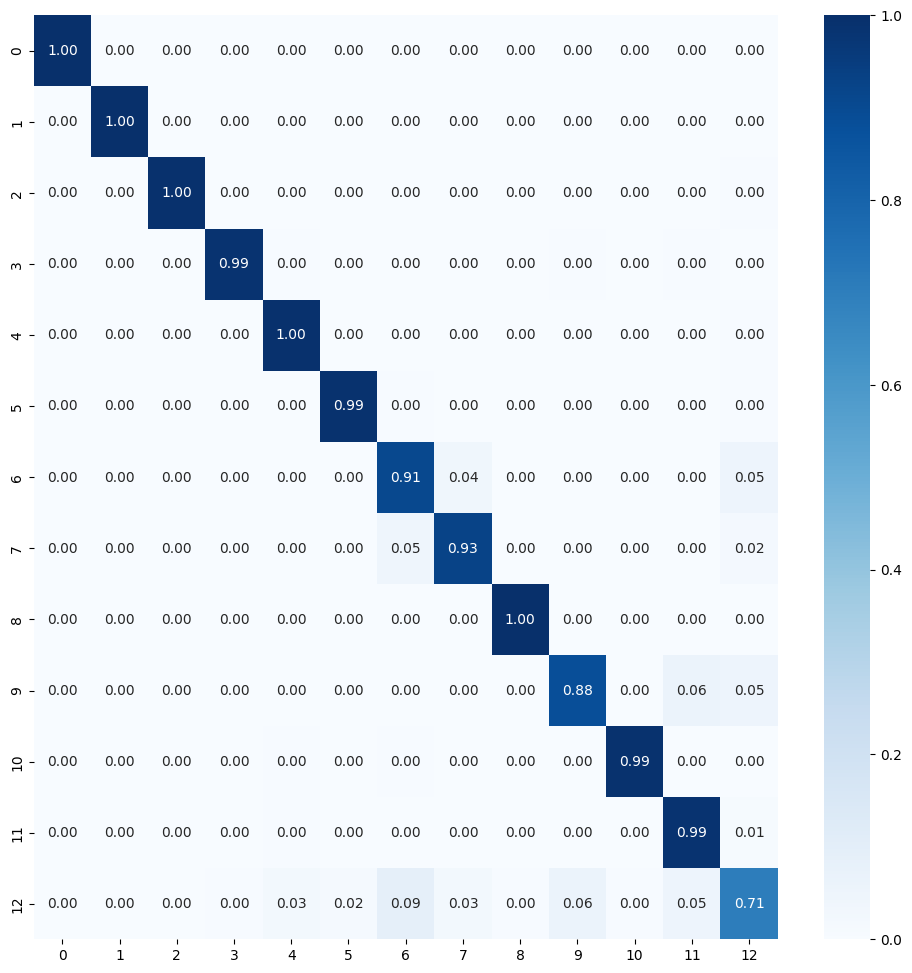


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3823053
Trainable params: 1645837
Non-trainable params: 2177216
Epoch 1/50
426/426 [==============================] - 83s 170ms/step - loss: 1.6528 - accuracy: 0.7597 - val_loss: 1.1543 - val_accuracy: 0.9056
Epoch 2/50
426/426 [==============================] - 71s 167ms/step - loss: 1.1968 - accuracy: 0.8846 - val_loss: 1.0735 - val_accuracy: 0.9190
Epoch 3/50
426/426 [==============================] - 67s 158ms/step - loss: 1.0818 - accuracy: 0.9125 - val_loss: 1.0150 - val_accuracy: 0.9358
Epoch 4/50
426/426 [==============================] - 62s 144ms/step - loss: 1.0160 - accuracy: 0.9282 - val_loss: 0.9618 - val_accuracy: 0.9385
Epoch 5/50
426/426 [==============================] - 64s 150ms/step - loss: 0.9611 - accuracy: 0.9369 - val_loss: 0.9315 - val_accuracy: 0.9392
Epoch 6/50
426/426 [==============================] - 78s 182ms/step - loss: 0.9094 - accuracy: 0.9452 - val_loss: 0.9034 - val_accuracy: 0.9427
Epoch 7/50
426

History for fold 2 saved...
427/427 [==============================] - 54s 123ms/step - loss: 0.0470 - accuracy: 0.9954
Train Accuracy: 0.9953846335411072
Train Log Loss: 0.047009389847517014
92/92 [==============================] - 13s 130ms/step - loss: 0.2681 - accuracy: 0.9525
Validation Accuracy: 0.9524786472320557
Validation Log Loss: 0.2680789828300476
92/92 [==============================] - 11s 122ms/step - loss: 0.2535 - accuracy: 0.9545
Test Accuracy: 0.9545299410820007
Test Log Loss: 0.2535029649734497
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   0   0   0   1   0   1   0]
 [  0   0   0   0 221   0   1   1   0  

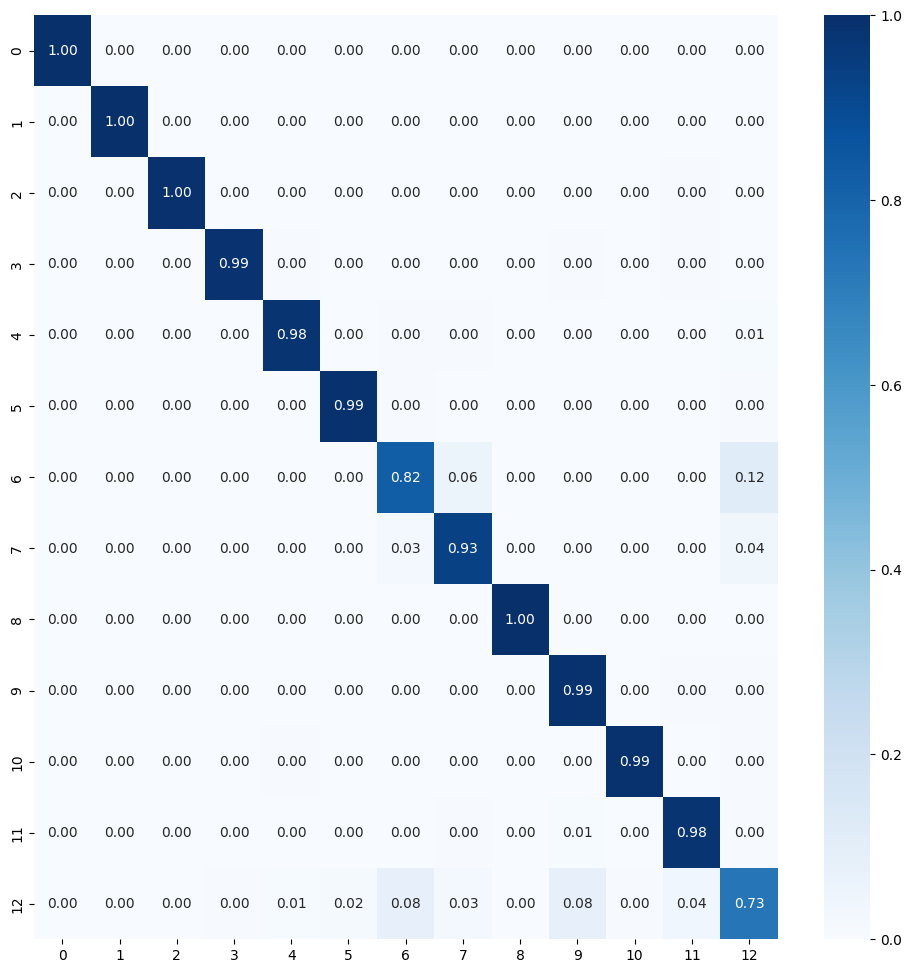


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3823053
Trainable params: 1645837
Non-trainable params: 2177216
Epoch 1/50
426/426 [==============================] - 77s 159ms/step - loss: 1.6197 - accuracy: 0.7681 - val_loss: 1.1551 - val_accuracy: 0.9032
Epoch 2/50
426/426 [==============================] - 73s 172ms/step - loss: 1.1908 - accuracy: 0.8880 - val_loss: 1.0622 - val_accuracy: 0.9217
Epoch 3/50
426/426 [==============================] - 66s 153ms/step - loss: 1.0780 - accuracy: 0.9172 - val_loss: 1.0105 - val_accuracy: 0.9293
Epoch 4/50
426/426 [==============================] - 64s 151ms/step - loss: 1.0101 - accuracy: 0.9273 - val_loss: 0.9658 - val_accuracy: 0.9368
Epoch 5/50
426/426 [==============================] - 64s 149ms/step - loss: 0.9543 - accuracy: 0.9363 - val_loss: 0.9296 - val_accuracy: 0.9358
Epoch 6/50
426/426 [==============================] - 64s 149ms/step - loss: 0.9022 - accuracy: 0.9441 - val_loss: 0.8903 - val_accuracy: 0.9437
Epoch 7/50
426

History for fold 3 saved...
427/427 [==============================] - 57s 131ms/step - loss: 0.0460 - accuracy: 0.9964
Train Accuracy: 0.9964102506637573
Train Log Loss: 0.04604204744100571
92/92 [==============================] - 12s 129ms/step - loss: 0.2756 - accuracy: 0.9525
Validation Accuracy: 0.9524786472320557
Validation Log Loss: 0.27559930086135864
92/92 [==============================] - 12s 130ms/step - loss: 0.2546 - accuracy: 0.9552
Test Accuracy: 0.9552136659622192
Test Log Loss: 0.254586786031723
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   2   0   0   0   0   0   0   0   1]
 [  0   0   0   0 224   0   1   0   0   

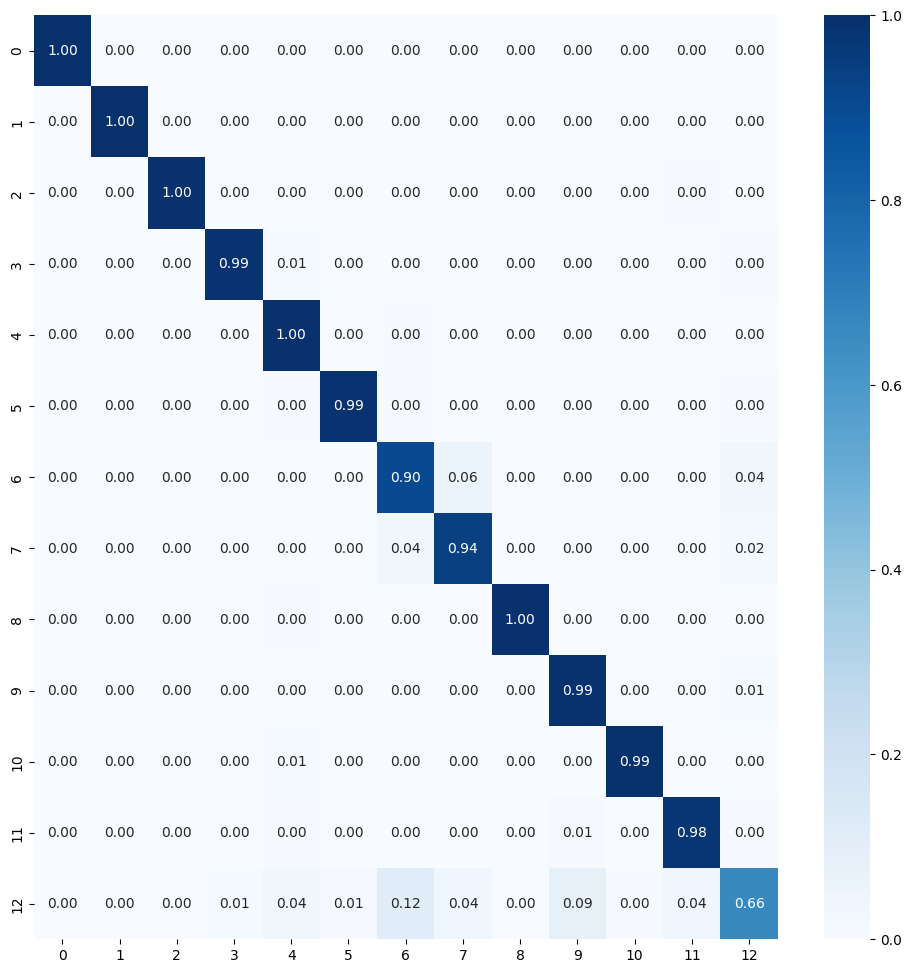


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3823053
Trainable params: 1645837
Non-trainable params: 2177216
Epoch 1/50
426/426 [==============================] - 79s 161ms/step - loss: 1.6626 - accuracy: 0.7574 - val_loss: 1.1624 - val_accuracy: 0.9028
Epoch 2/50
426/426 [==============================] - 67s 157ms/step - loss: 1.1971 - accuracy: 0.8835 - val_loss: 1.0665 - val_accuracy: 0.9293
Epoch 3/50
426/426 [==============================] - 65s 153ms/step - loss: 1.0888 - accuracy: 0.9140 - val_loss: 1.0207 - val_accuracy: 0.9330
Epoch 4/50
426/426 [==============================] - 69s 162ms/step - loss: 1.0262 - accuracy: 0.9250 - val_loss: 0.9943 - val_accuracy: 0.9279
Epoch 5/50
426/426 [==============================] - 72s 169ms/step - loss: 0.9605 - accuracy: 0.9365 - val_loss: 0.9567 - val_accuracy: 0.9402
Epoch 6/50
426/426 [==============================] - 70s 163ms/step - loss: 0.9097 - accuracy: 0.9436 - val_loss: 0.9132 - val_accuracy: 0.9389
Epoch 7/50
426

History for fold 4 saved...
427/427 [==============================] - 63s 146ms/step - loss: 0.0561 - accuracy: 0.9927
Train Accuracy: 0.9927472472190857
Train Log Loss: 0.056092262268066406
92/92 [==============================] - 14s 145ms/step - loss: 0.2633 - accuracy: 0.9504
Validation Accuracy: 0.9504273533821106
Validation Log Loss: 0.26331982016563416
92/92 [==============================] - 13s 128ms/step - loss: 0.2507 - accuracy: 0.9511
Test Accuracy: 0.9511111378669739
Test Log Loss: 0.25073161721229553
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0   0   0   0]
 [  0   0   0 221   2   0   0   0   0   2   0   0   0]
 [  0   0   0   0 221   0   2   0   0

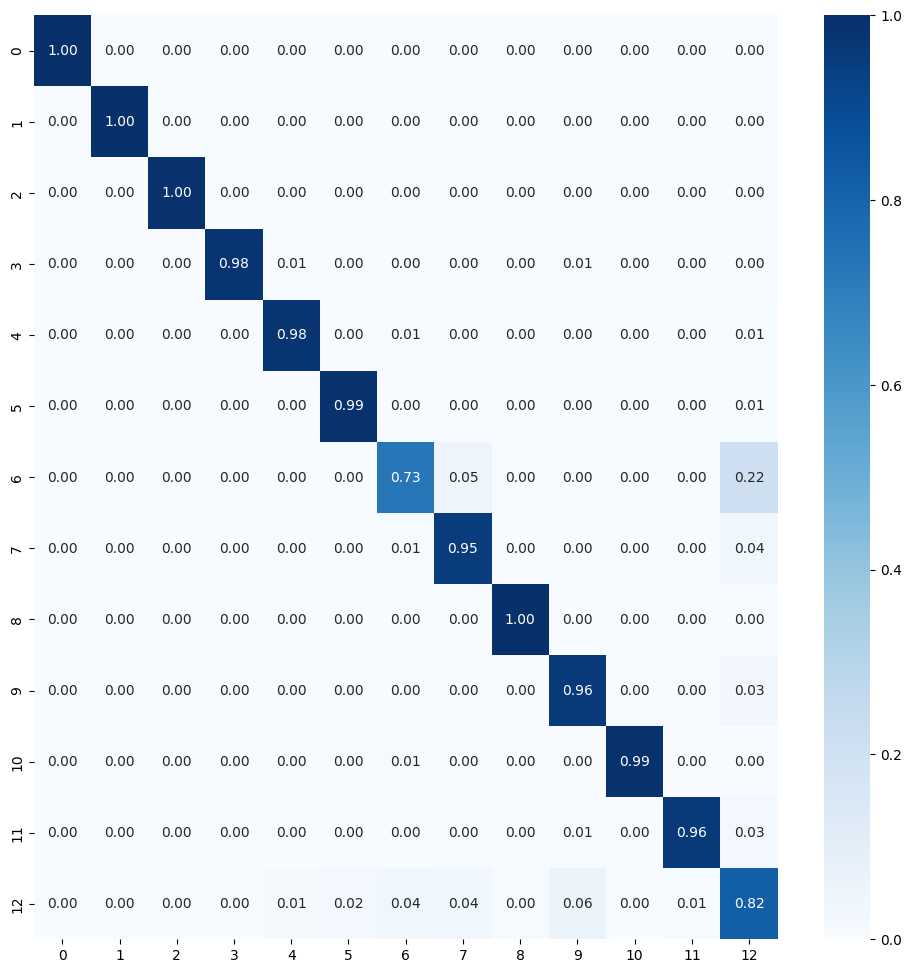


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3823053
Trainable params: 1645837
Non-trainable params: 2177216
Epoch 1/50
426/426 [==============================] - 79s 164ms/step - loss: 1.6422 - accuracy: 0.7645 - val_loss: 1.1569 - val_accuracy: 0.8997
Epoch 2/50
426/426 [==============================] - 68s 159ms/step - loss: 1.2039 - accuracy: 0.8837 - val_loss: 1.0602 - val_accuracy: 0.9245
Epoch 3/50
426/426 [==============================] - 66s 156ms/step - loss: 1.0939 - accuracy: 0.9083 - val_loss: 1.0189 - val_accuracy: 0.9310
Epoch 4/50
426/426 [==============================] - 66s 153ms/step - loss: 1.0273 - accuracy: 0.9244 - val_loss: 0.9647 - val_accuracy: 0.9389
Epoch 5/50
426/426 [==============================] - 67s 156ms/step - loss: 0.9586 - accuracy: 0.9364 - val_loss: 0.9349 - val_accuracy: 0.9389
Epoch 6/50
426/426 [==============================] - 65s 153ms/step - loss: 0.9088 - accuracy: 0.9438 - val_loss: 0.9112 - val_accuracy: 0.9392
Epoch 7/50
426

History for fold 5 saved...
427/427 [==============================] - 57s 133ms/step - loss: 0.0488 - accuracy: 0.9956
Train Accuracy: 0.995604395866394
Train Log Loss: 0.04882371798157692
92/92 [==============================] - 14s 140ms/step - loss: 0.2982 - accuracy: 0.9535
Validation Accuracy: 0.9535042643547058
Validation Log Loss: 0.29817667603492737
92/92 [==============================] - 13s 139ms/step - loss: 0.2784 - accuracy: 0.9545
Test Accuracy: 0.9545299410820007
Test Log Loss: 0.2784479260444641
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   1   0   0   0   0   1   1]
 [  0   0   0   0 224   0   1   0   0   

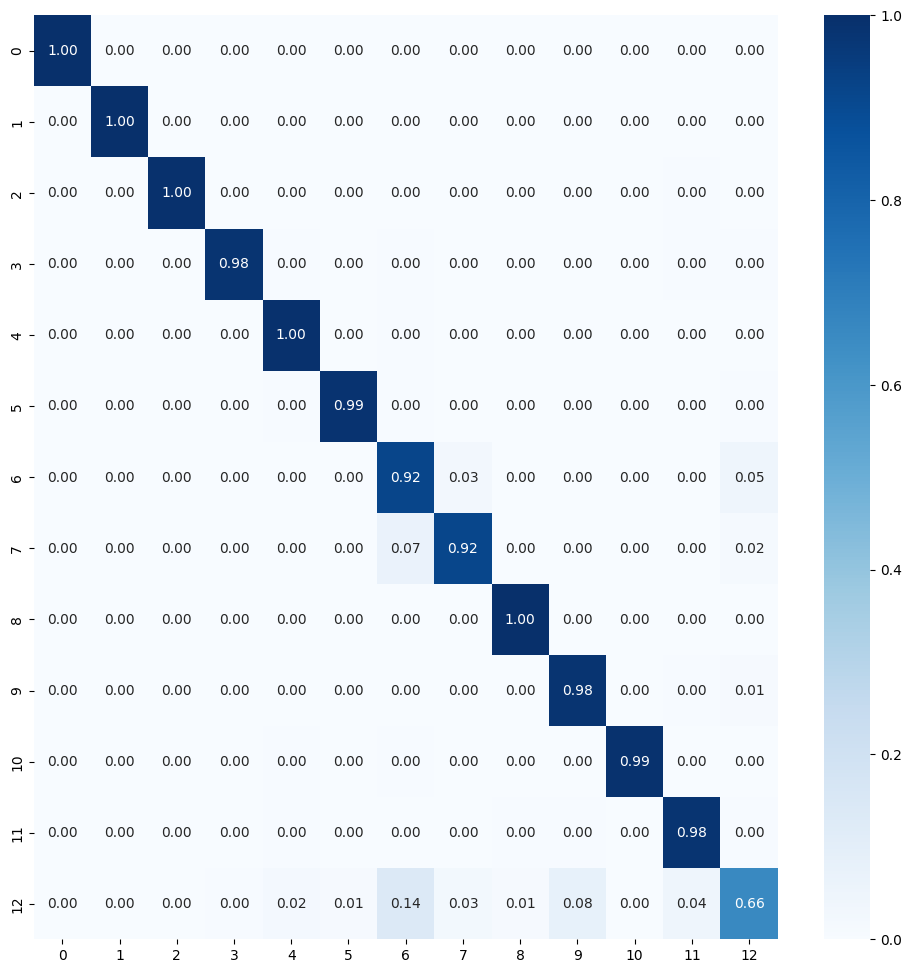


Best fold was 1 with val_accuracy: 0.9557
Average training accuracy in 5-fold: 0.993963873386383
Average validation precision in 5-fold: 0.9545329689979554

Test Metrics
test_acc_list: [0.9517948627471924, 0.9545299410820007, 0.9552136659622192, 0.9511111378669739, 0.9545299410820007]
Average Test Accuracy with 5-fold: 0.9534359097480773
test_loss_list: [0.25603532791137695, 0.2535029649734497, 0.254586786031723, 0.25073161721229553, 0.2784479260444641]
Average Test Log Loss with 5-fold: 0.2586609244346619

Precision List: [0.9512203424008836, 0.9536328901341099, 0.9550271949783328, 0.9536962793673069, 0.9548594205218084]
Average Precision List with 5-fold: 0.9536872254804883
Recall List: [0.9517948717948718, 0.9545299145299146, 0.9552136752136752, 0.9511111111111111, 0.9545299145299146]
Average Recall List with 5-fold: 0.9534358974358975
F1 Score List: [0.9508526592934768, 0.9537388012203516, 0.9535041644936109, 0.9512046348238226, 0.9530587396899364]
Average F1 Score List with 5-fol

In [20]:
%%time

num_classes = 13
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/14
name_save_model: MobileNet_tf_150014
Found 14700 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3823182
Trainable params: 1645966
Non-trainable params: 2177216
Epoch 1/50
459/459 [==============================] - 91s 175ms/step - loss: 1.7509 - accuracy: 0.7118 - val_loss: 1.2339 - val_accuracy: 0.8594
Epoch 2/50
459/459 [==============================] - 79s 171ms/step - loss: 1.2819 - accuracy: 0.8380 - val_loss: 1.1373 - val_accuracy: 0.8916
Epoch 3/50
459/459 [==============================] - 77s 167ms/step - loss: 1.1721 - accuracy: 0.8664 - val_loss: 1.0977 - val_accuracy: 0.8881
Epoch 4/50
459/459 [========

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
460/460 [==============================] - 59s 129ms/step - loss: 0.1089 - accuracy: 0.9642
Train Accuracy: 0.9642176628112793
Train Log Loss: 0.1088702529668808
99/99 [==============================] - 15s 153ms/step - loss: 0.3220 - accuracy: 0.9168
Validation Accuracy: 0.9168254137039185
Validation Log Loss: 0.3219558596611023
99/99 [==============================] - 15s 153ms/step - loss: 0.2950 - accuracy: 0.9225
Test Accuracy: 0.9225397109985352
Test Log Loss: 0.29503580927848816
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 220   1   0   0   0   0   0   0   0   0   4]
 [  0   0  

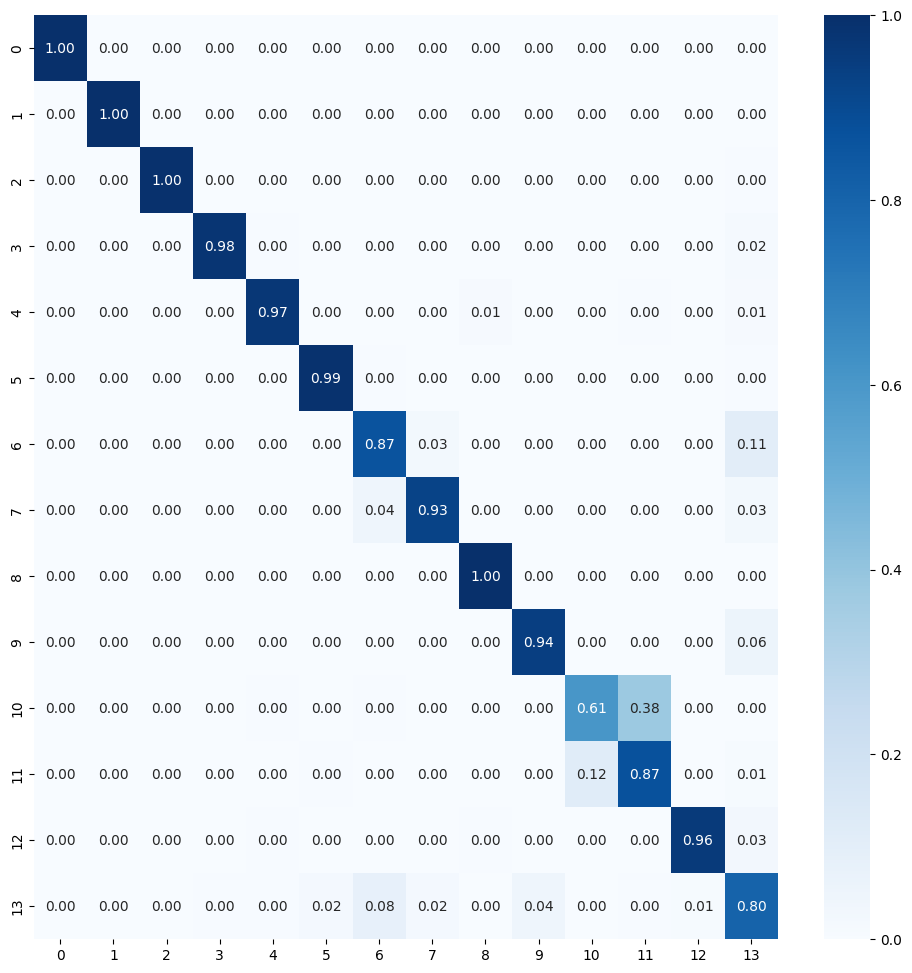


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3823182
Trainable params: 1645966
Non-trainable params: 2177216
Epoch 1/50
459/459 [==============================] - 109s 203ms/step - loss: 1.7714 - accuracy: 0.7220 - val_loss: 1.2441 - val_accuracy: 0.8568
Epoch 2/50
459/459 [==============================] - 84s 184ms/step - loss: 1.2905 - accuracy: 0.8389 - val_loss: 1.1434 - val_accuracy: 0.8753
Epoch 3/50
459/459 [==============================] - 90s 196ms/step - loss: 1.1733 - accuracy: 0.8664 - val_loss: 1.1236 - val_accuracy: 0.8673
Epoch 4/50
459/459 [==============================] - 89s 193ms/step - loss: 1.1043 - accuracy: 0.8791 - val_loss: 1.0576 - val_accuracy: 0.8976
Epoch 5/50
459/459 [==============================] - 84s 182ms/step - loss: 1.0464 - accuracy: 0.8871 - val_loss: 1.0123 - val_accuracy: 0.8948
Epoch 6/50
459/459 [==============================] - 83s 181ms/step - loss: 0.9861 - accuracy: 0.8995 - val_loss: 0.9825 - val_accuracy: 0.8874
Epoch 7/50
45

History for fold 2 saved...
460/460 [==============================] - 68s 146ms/step - loss: 0.1552 - accuracy: 0.9418
Train Accuracy: 0.9417687058448792
Train Log Loss: 0.15521880984306335
99/99 [==============================] - 15s 148ms/step - loss: 0.4129 - accuracy: 0.8895
Validation Accuracy: 0.8895238041877747
Validation Log Loss: 0.41292038559913635
99/99 [==============================] - 15s 153ms/step - loss: 0.3931 - accuracy: 0.8943
Test Accuracy: 0.8942857384681702
Test Log Loss: 0.3930935859680176
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 214   0   0   0   0   0   0   0   0   0   1  10]
 [  0   0   0 219   1   0   0   0   0   0   0   0   0   5]
 [  0   0 

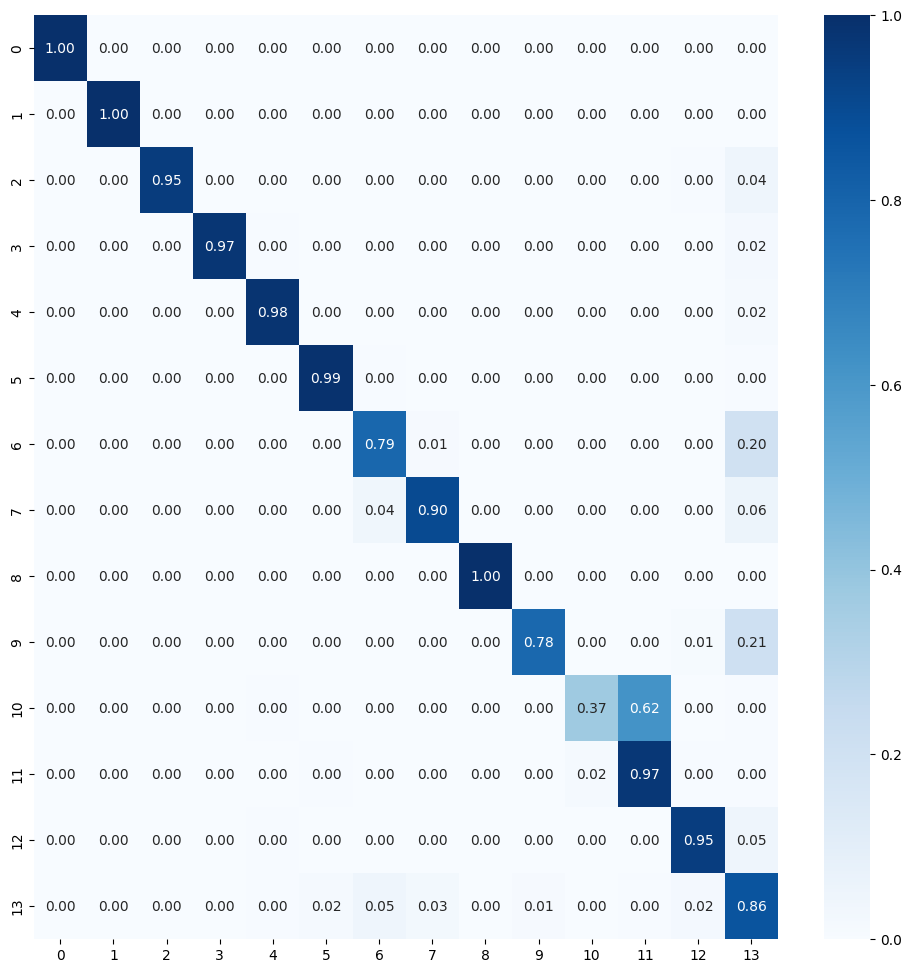


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3823182
Trainable params: 1645966
Non-trainable params: 2177216
Epoch 1/50
459/459 [==============================] - 96s 184ms/step - loss: 1.7084 - accuracy: 0.7289 - val_loss: 1.2474 - val_accuracy: 0.8543
Epoch 2/50
459/459 [==============================] - 91s 197ms/step - loss: 1.2892 - accuracy: 0.8370 - val_loss: 1.1508 - val_accuracy: 0.8744
Epoch 3/50
459/459 [==============================] - 82s 177ms/step - loss: 1.1727 - accuracy: 0.8657 - val_loss: 1.0953 - val_accuracy: 0.8964
Epoch 4/50
459/459 [==============================] - 81s 176ms/step - loss: 1.1091 - accuracy: 0.8772 - val_loss: 1.0487 - val_accuracy: 0.8960
Epoch 5/50
459/459 [==============================] - 91s 196ms/step - loss: 1.0447 - accuracy: 0.8888 - val_loss: 1.0078 - val_accuracy: 0.9078
Epoch 6/50
459/459 [==============================] - 91s 196ms/step - loss: 0.9896 - accuracy: 0.8975 - val_loss: 0.9877 - val_accuracy: 0.8967
Epoch 7/50
459

History for fold 3 saved...
460/460 [==============================] - 69s 147ms/step - loss: 0.1167 - accuracy: 0.9650
Train Accuracy: 0.965034008026123
Train Log Loss: 0.11670669913291931
99/99 [==============================] - 15s 148ms/step - loss: 0.3491 - accuracy: 0.9197
Validation Accuracy: 0.9196825623512268
Validation Log Loss: 0.3491121828556061
99/99 [==============================] - 18s 173ms/step - loss: 0.3442 - accuracy: 0.9213
Test Accuracy: 0.9212698340415955
Test Log Loss: 0.34415632486343384
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0   0   0   0   0]
 [  0   0   0 221   2   0   0   0   0   2   0   0   0   0]
 [  0   0  

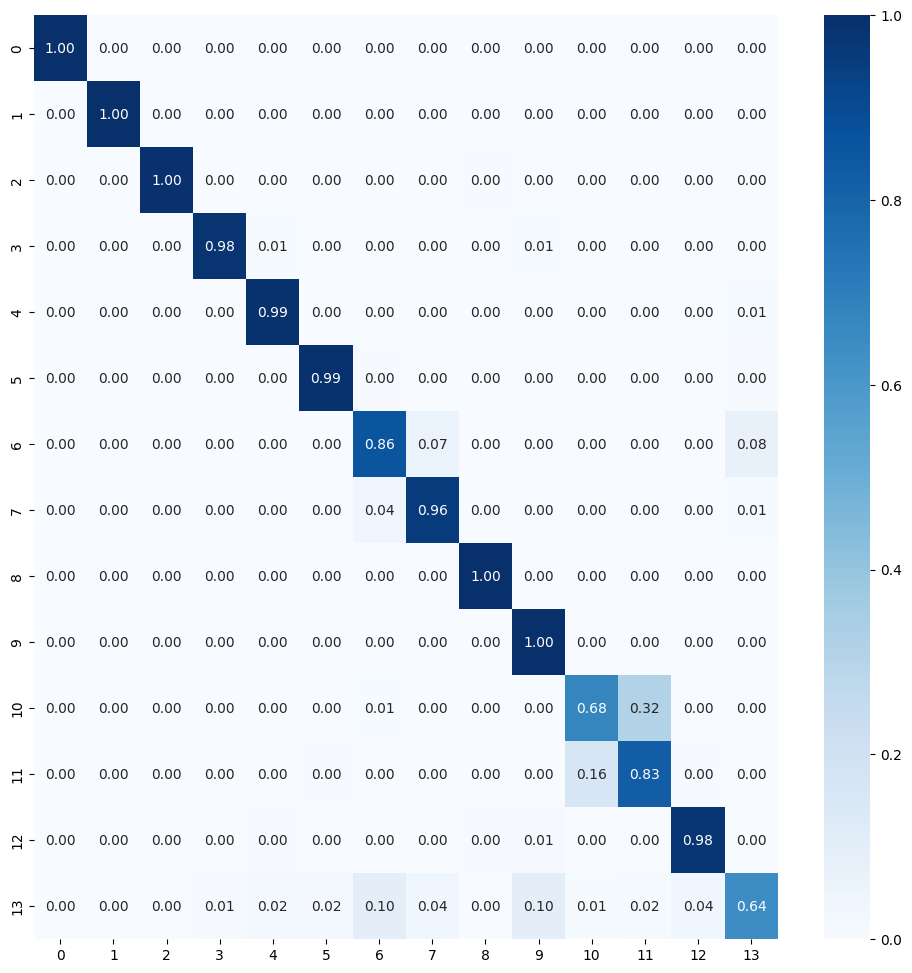


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3823182
Trainable params: 1645966
Non-trainable params: 2177216
Epoch 1/50
459/459 [==============================] - 102s 201ms/step - loss: 1.7513 - accuracy: 0.7199 - val_loss: 1.2456 - val_accuracy: 0.8552
Epoch 2/50
459/459 [==============================] - 80s 173ms/step - loss: 1.2911 - accuracy: 0.8379 - val_loss: 1.1285 - val_accuracy: 0.8874
Epoch 3/50
459/459 [==============================] - 81s 174ms/step - loss: 1.1822 - accuracy: 0.8612 - val_loss: 1.0930 - val_accuracy: 0.8871
Epoch 4/50
459/459 [==============================] - 81s 174ms/step - loss: 1.1023 - accuracy: 0.8778 - val_loss: 1.0466 - val_accuracy: 0.8970
Epoch 5/50
459/459 [==============================] - 84s 183ms/step - loss: 1.0332 - accuracy: 0.8927 - val_loss: 1.0035 - val_accuracy: 0.9031
Epoch 6/50
459/459 [==============================] - 87s 188ms/step - loss: 0.9902 - accuracy: 0.9005 - val_loss: 0.9736 - val_accuracy: 0.8884
Epoch 7/50
45

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 4 saved...
460/460 [==============================] - 71s 154ms/step - loss: 0.1126 - accuracy: 0.9625
Train Accuracy: 0.9625170230865479
Train Log Loss: 0.11260135471820831
99/99 [==============================] - 17s 157ms/step - loss: 0.3281 - accuracy: 0.9140
Validation Accuracy: 0.9139682650566101
Validation Log Loss: 0.3281029164791107
99/99 [==============================] - 15s 147ms/step - loss: 0.3183 - accuracy: 0.9219
Test Accuracy: 0.9219047427177429
Test Log Loss: 0.3183060586452484
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   2   0   1   0   0   0   0   0   1   0]
 [  0   0  

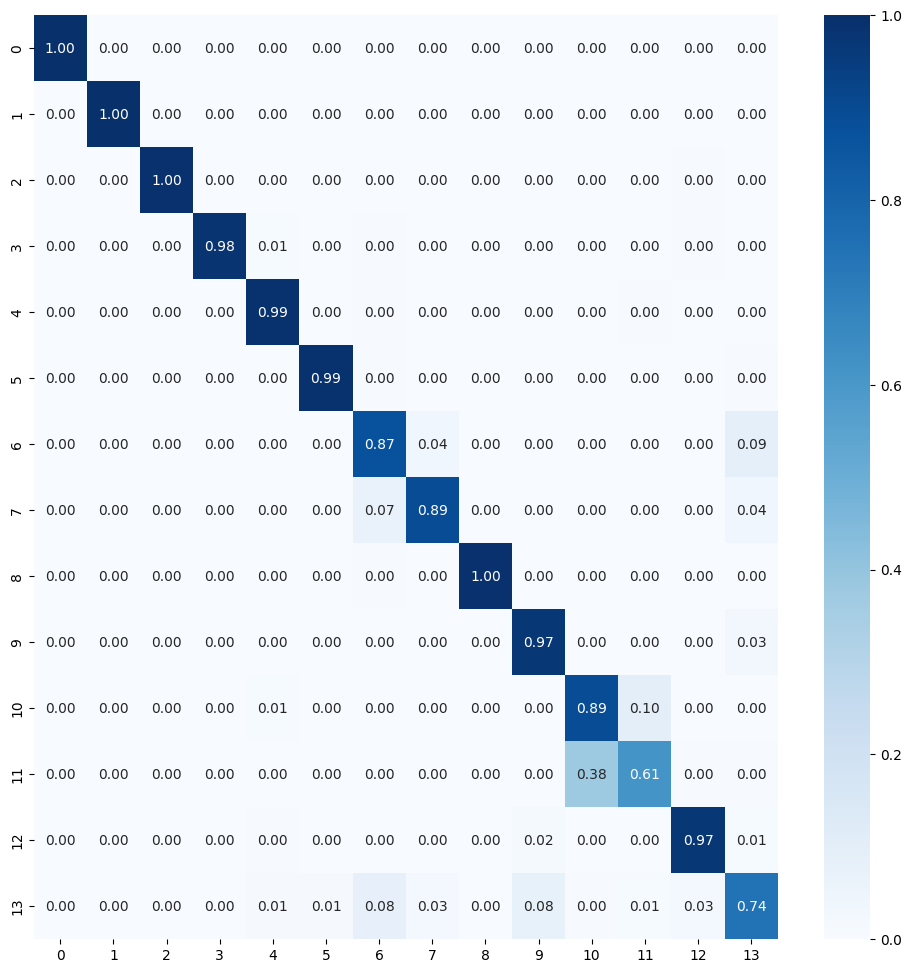


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3823182
Trainable params: 1645966
Non-trainable params: 2177216
Epoch 1/50
459/459 [==============================] - 106s 201ms/step - loss: 1.7205 - accuracy: 0.7218 - val_loss: 1.2296 - val_accuracy: 0.8750
Epoch 2/50
459/459 [==============================] - 78s 170ms/step - loss: 1.2791 - accuracy: 0.8392 - val_loss: 1.1483 - val_accuracy: 0.8680
Epoch 3/50
459/459 [==============================] - 81s 177ms/step - loss: 1.1702 - accuracy: 0.8638 - val_loss: 1.0842 - val_accuracy: 0.8887
Epoch 4/50
459/459 [==============================] - 86s 186ms/step - loss: 1.0971 - accuracy: 0.8763 - val_loss: 1.0485 - val_accuracy: 0.9024
Epoch 5/50
459/459 [==============================] - 86s 188ms/step - loss: 1.0362 - accuracy: 0.8909 - val_loss: 1.0098 - val_accuracy: 0.8986
Epoch 6/50
459/459 [==============================] - 84s 181ms/step - loss: 0.9855 - accuracy: 0.8983 - val_loss: 0.9728 - val_accuracy: 0.8964
Epoch 7/50
45

History for fold 5 saved...
460/460 [==============================] - 68s 147ms/step - loss: 0.1155 - accuracy: 0.9545
Train Accuracy: 0.9544897675514221
Train Log Loss: 0.11553557962179184
99/99 [==============================] - 13s 134ms/step - loss: 0.3254 - accuracy: 0.9105
Validation Accuracy: 0.9104762077331543
Validation Log Loss: 0.3253861963748932
99/99 [==============================] - 14s 131ms/step - loss: 0.3118 - accuracy: 0.9159
Test Accuracy: 0.9158729910850525
Test Log Loss: 0.3118106424808502
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   1   0   0   0   0   0   1   0]
 [  0   0  

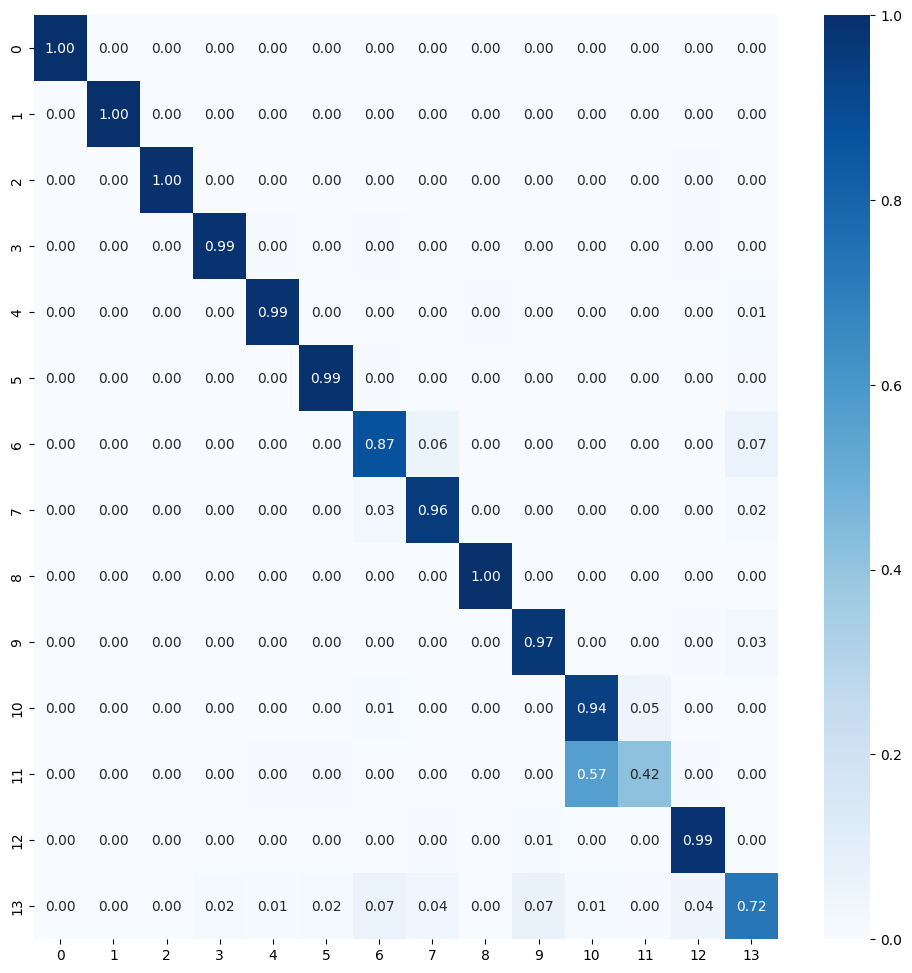


Best fold was 4 with val_accuracy: 0.9260
Average training accuracy in 5-fold: 0.9623670697212219
Average validation precision in 5-fold: 0.9236607193946839

Test Metrics
test_acc_list: [0.9225397109985352, 0.8942857384681702, 0.9212698340415955, 0.9219047427177429, 0.9158729910850525]
Average Test Accuracy with 5-fold: 0.9151746034622192
test_loss_list: [0.29503580927848816, 0.3930935859680176, 0.34415632486343384, 0.3183060586452484, 0.3118106424808502]
Average Test Log Loss with 5-fold: 0.33248048424720766

Precision List: [0.9264976429416283, 0.9215928568402685, 0.9215037664525046, 0.9245316530998853, 0.9245406615390266]
Average Precision List with 5-fold: 0.9237333161746626
Recall List: [0.9225396825396824, 0.8942857142857142, 0.9212698412698412, 0.921904761904762, 0.915873015873016]
Average Recall List with 5-fold: 0.9151746031746033
F1 Score List: [0.9223249572125516, 0.8928309788283472, 0.9192422321738473, 0.9208037005439156, 0.9115075706946234]
Average F1 Score List with 5-fo

In [21]:
%%time

num_classes = 14
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/15
name_save_model: MobileNet_tf_150015
Found 15750 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small
- upatre

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3823311
Trainable params: 1646095
Non-trainable params: 2177216
Epoch 1/50
492/492 [==============================] - 98s 178ms/step - loss: 1.7620 - accuracy: 0.7176 - val_loss: 1.2375 - val_accuracy: 0.8560
Epoch 2/50
492/492 [==============================] - 96s 194ms/step - loss: 1.2965 - accuracy: 0.8386 - val_loss: 1.1438 - val_accuracy: 0.8929
Epoch 3/50
492/492 [==============================] - 99s 201ms/step - loss: 1.1862 - accuracy: 0.8618 - val_loss: 1.0869 - val_accuracy: 0.8887
Epoch 4/50
492/492 

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 1 saved...
493/493 [==============================] - 65s 131ms/step - loss: 0.1028 - accuracy: 0.9716
Train Accuracy: 0.9716190695762634
Train Log Loss: 0.102775439620018
106/106 [==============================] - 20s 149ms/step - loss: 0.3192 - accuracy: 0.9233
Validation Accuracy: 0.9232592582702637
Validation Log Loss: 0.31923922896385193
106/106 [==============================] - 15s 140ms/step - loss: 0.2979 - accuracy: 0.9277
Test Accuracy: 0.9277036786079407
Test Log Loss: 0.2979190945625305
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 221   1   0   0   0   0   1

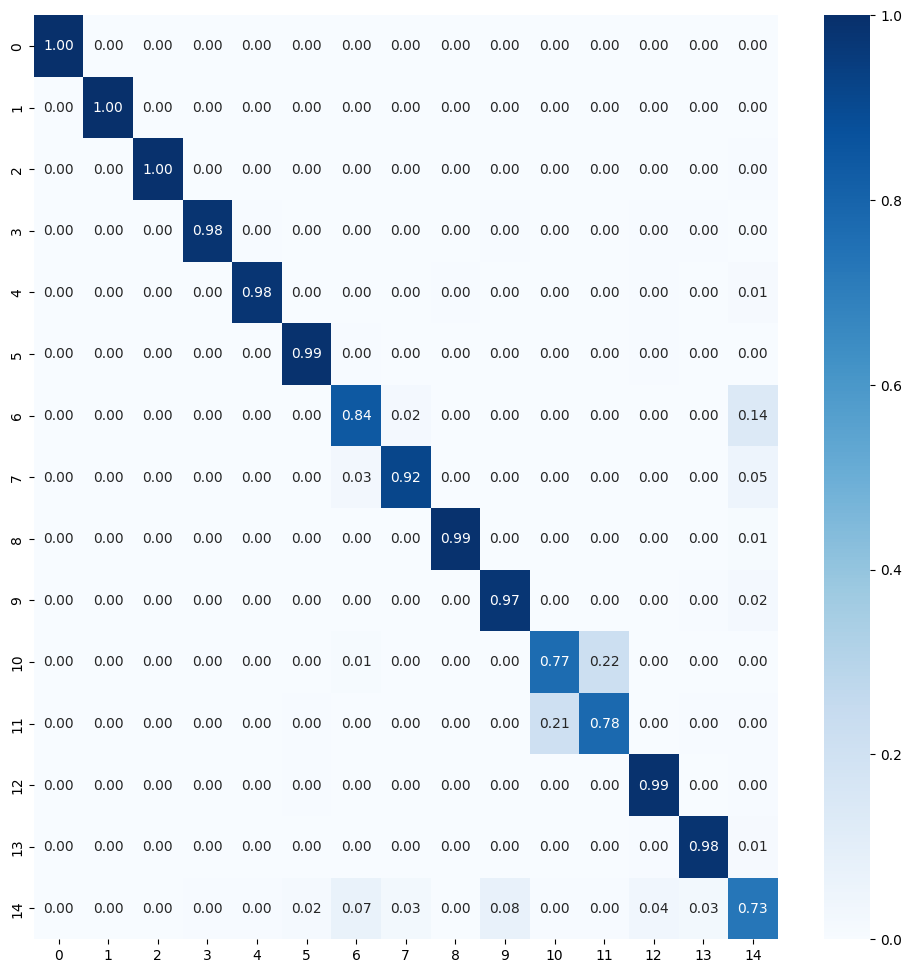


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3823311
Trainable params: 1646095
Non-trainable params: 2177216
Epoch 1/50
492/492 [==============================] - 99s 179ms/step - loss: 1.7588 - accuracy: 0.7206 - val_loss: 1.2351 - val_accuracy: 0.8622
Epoch 2/50
492/492 [==============================] - 82s 166ms/step - loss: 1.2908 - accuracy: 0.8390 - val_loss: 1.1408 - val_accuracy: 0.8935
Epoch 3/50
492/492 [==============================] - 81s 164ms/step - loss: 1.1751 - accuracy: 0.8672 - val_loss: 1.0847 - val_accuracy: 0.8881
Epoch 4/50
492/492 [==============================] - 87s 176ms/step - loss: 1.0995 - accuracy: 0.8787 - val_loss: 1.0500 - val_accuracy: 0.8952
Epoch 5/50
492/492 [==============================] - 85s 172ms/step - loss: 1.0340 - accuracy: 0.8930 - val_loss: 1.0010 - val_accuracy: 0.9021
Epoch 6/50
492/492 [==============================] - 91s 185ms/step - loss: 0.9803 - accuracy: 0.8980 - val_loss: 0.9639 - val_accuracy: 0.8961
Epoch 7/50
492

History for fold 2 saved...
493/493 [==============================] - 100s 201ms/step - loss: 0.1057 - accuracy: 0.9713
Train Accuracy: 0.9713016152381897
Train Log Loss: 0.10567836463451385
106/106 [==============================] - 18s 165ms/step - loss: 0.3303 - accuracy: 0.9194
Validation Accuracy: 0.9194074273109436
Validation Log Loss: 0.3302857577800751
106/106 [==============================] - 18s 170ms/step - loss: 0.3059 - accuracy: 0.9274
Test Accuracy: 0.9274073839187622
Test Log Loss: 0.3059077560901642
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 219   1   0   0   0   0  

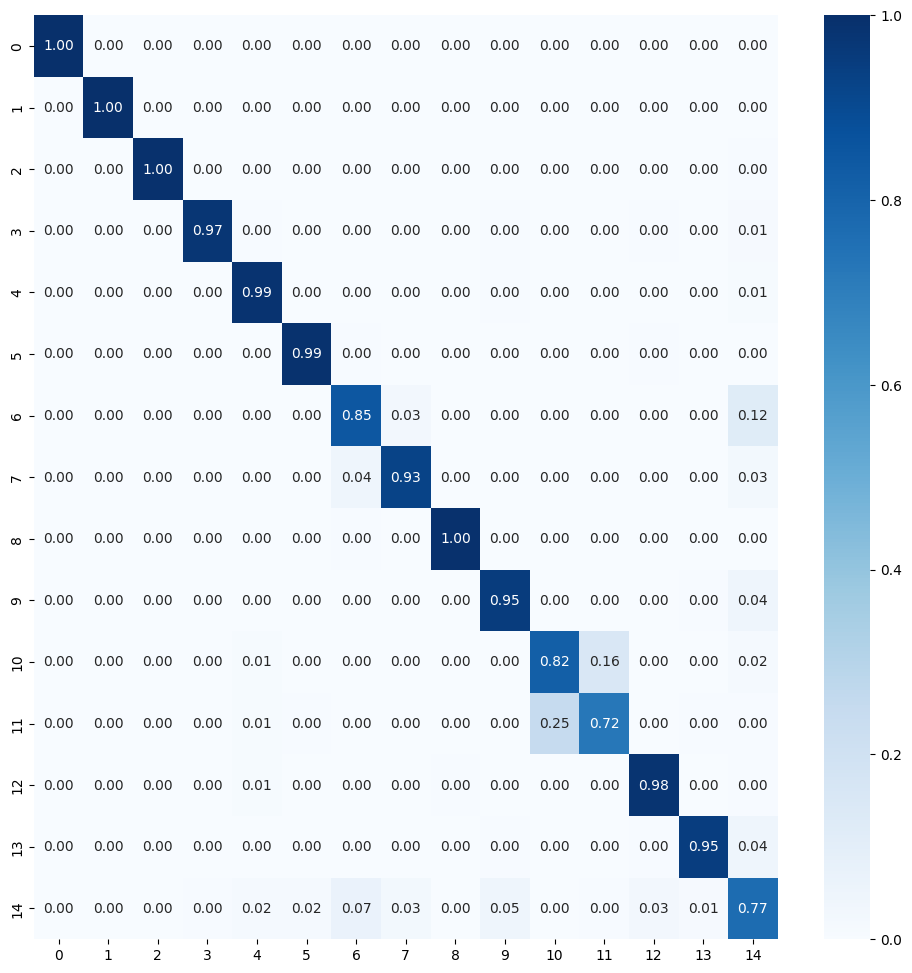


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3823311
Trainable params: 1646095
Non-trainable params: 2177216
Epoch 1/50
492/492 [==============================] - 116s 208ms/step - loss: 1.7509 - accuracy: 0.7204 - val_loss: 1.2283 - val_accuracy: 0.8580
Epoch 2/50
492/492 [==============================] - 103s 208ms/step - loss: 1.2880 - accuracy: 0.8415 - val_loss: 1.1596 - val_accuracy: 0.8705
Epoch 3/50
492/492 [==============================] - 103s 206ms/step - loss: 1.1733 - accuracy: 0.8653 - val_loss: 1.0848 - val_accuracy: 0.8988
Epoch 4/50
492/492 [==============================] - 101s 204ms/step - loss: 1.0964 - accuracy: 0.8812 - val_loss: 1.0593 - val_accuracy: 0.8955
Epoch 5/50
492/492 [==============================] - 106s 216ms/step - loss: 1.0358 - accuracy: 0.8915 - val_loss: 1.0079 - val_accuracy: 0.8926
Epoch 6/50
492/492 [==============================] - 106s 216ms/step - loss: 0.9841 - accuracy: 0.8998 - val_loss: 0.9675 - val_accuracy: 0.9071
Epoch 7/

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 3 saved...
493/493 [==============================] - 83s 167ms/step - loss: 0.1083 - accuracy: 0.9642
Train Accuracy: 0.9641904830932617
Train Log Loss: 0.1083008348941803
106/106 [==============================] - 18s 166ms/step - loss: 0.3601 - accuracy: 0.9164
Validation Accuracy: 0.9164444208145142
Validation Log Loss: 0.3601185381412506
106/106 [==============================] - 20s 172ms/step - loss: 0.3388 - accuracy: 0.9200
Test Accuracy: 0.9200000166893005
Test Log Loss: 0.33877840638160706
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   2   0   0   0   0   

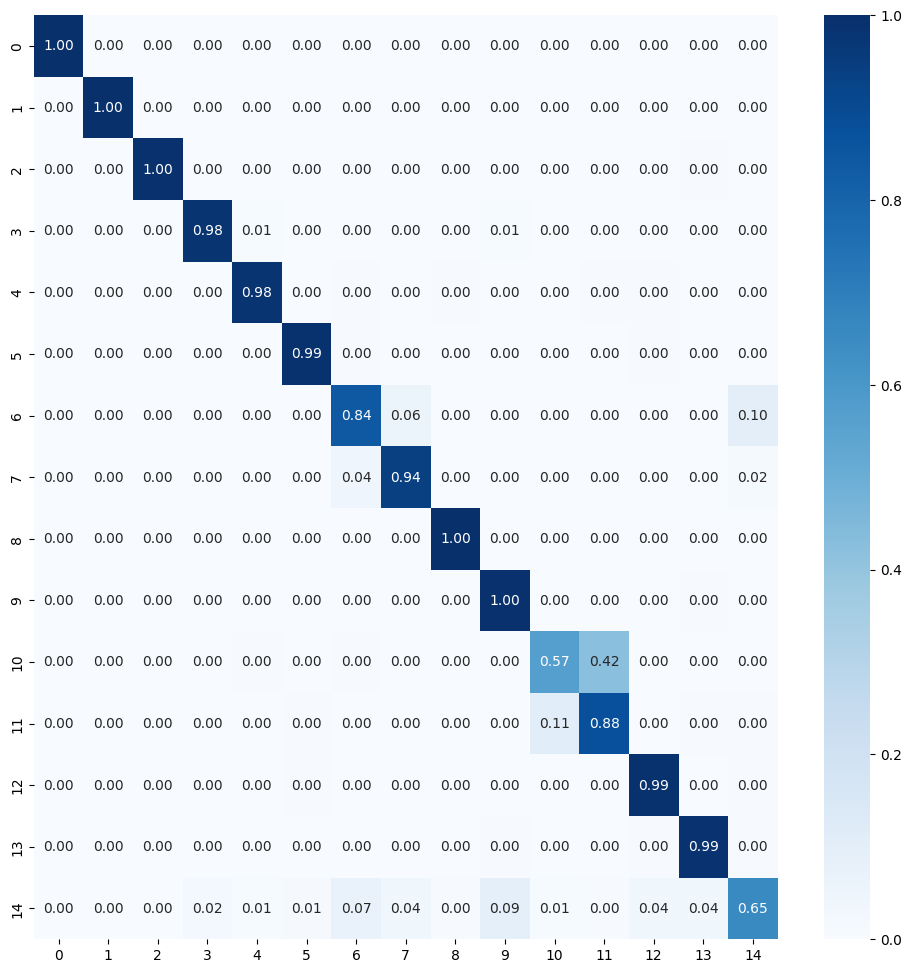


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3823311
Trainable params: 1646095
Non-trainable params: 2177216
Epoch 1/50
492/492 [==============================] - 119s 217ms/step - loss: 1.7325 - accuracy: 0.7205 - val_loss: 1.2249 - val_accuracy: 0.8613
Epoch 2/50
492/492 [==============================] - 102s 207ms/step - loss: 1.2839 - accuracy: 0.8383 - val_loss: 1.1406 - val_accuracy: 0.8827
Epoch 3/50
492/492 [==============================] - 102s 207ms/step - loss: 1.1689 - accuracy: 0.8636 - val_loss: 1.0924 - val_accuracy: 0.8738
Epoch 4/50
492/492 [==============================] - 99s 201ms/step - loss: 1.0901 - accuracy: 0.8816 - val_loss: 1.0367 - val_accuracy: 0.8991
Epoch 5/50
492/492 [==============================] - 102s 205ms/step - loss: 1.0245 - accuracy: 0.8934 - val_loss: 1.0002 - val_accuracy: 0.8988
Epoch 6/50
492/492 [==============================] - 89s 180ms/step - loss: 0.9748 - accuracy: 0.8978 - val_loss: 0.9500 - val_accuracy: 0.9062
Epoch 7/50

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


History for fold 4 saved...
493/493 [==============================] - 76s 152ms/step - loss: 0.1044 - accuracy: 0.9690
Train Accuracy: 0.9689523577690125
Train Log Loss: 0.10440900176763535
106/106 [==============================] - 16s 151ms/step - loss: 0.3380 - accuracy: 0.9236
Validation Accuracy: 0.9235555529594421
Validation Log Loss: 0.3379972279071808
106/106 [==============================] - 17s 155ms/step - loss: 0.3208 - accuracy: 0.9280
Test Accuracy: 0.9279999732971191
Test Log Loss: 0.3207562267780304
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 220   1   0   1   0   0   

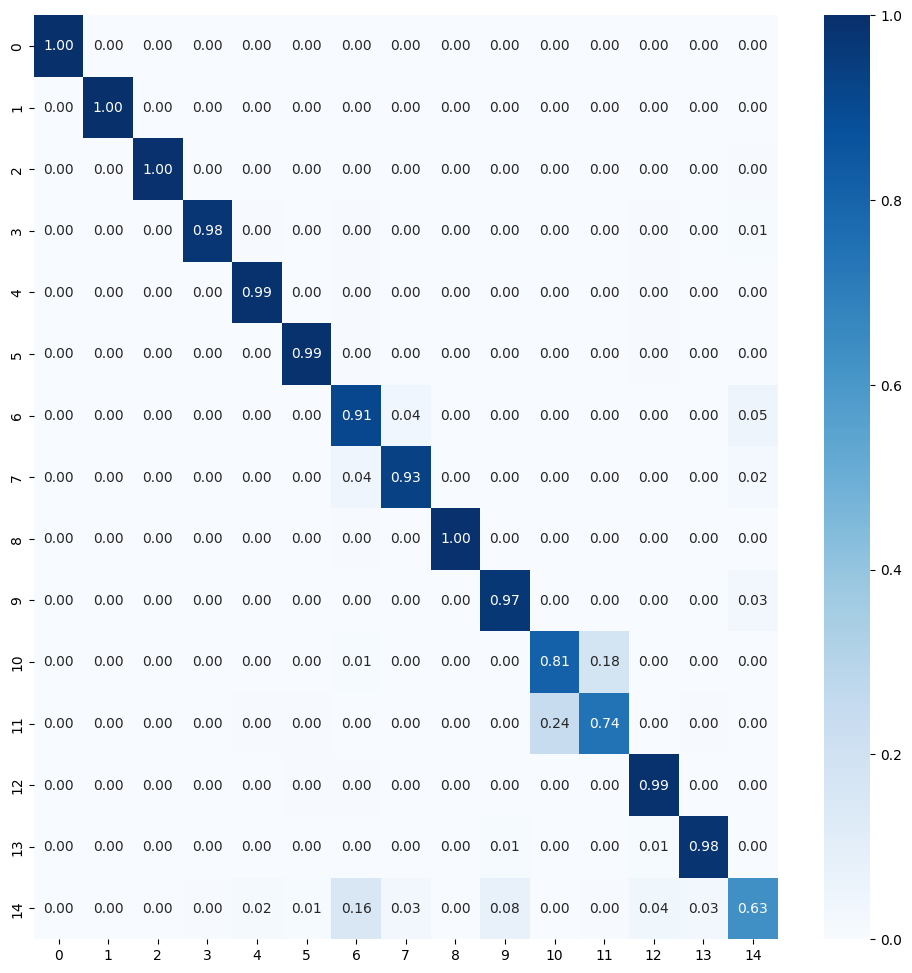


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3823311
Trainable params: 1646095
Non-trainable params: 2177216
Epoch 1/50
492/492 [==============================] - 112s 202ms/step - loss: 1.7350 - accuracy: 0.7227 - val_loss: 1.2550 - val_accuracy: 0.8485
Epoch 2/50
492/492 [==============================] - 95s 190ms/step - loss: 1.2854 - accuracy: 0.8375 - val_loss: 1.1404 - val_accuracy: 0.8789
Epoch 3/50
492/492 [==============================] - 92s 187ms/step - loss: 1.1756 - accuracy: 0.8627 - val_loss: 1.0836 - val_accuracy: 0.9003
Epoch 4/50
492/492 [==============================] - 95s 193ms/step - loss: 1.0985 - accuracy: 0.8827 - val_loss: 1.0330 - val_accuracy: 0.9027
Epoch 5/50
492/492 [==============================] - 97s 195ms/step - loss: 1.0337 - accuracy: 0.8933 - val_loss: 0.9973 - val_accuracy: 0.9027
Epoch 6/50
492/492 [==============================] - 92s 187ms/step - loss: 0.9791 - accuracy: 0.8981 - val_loss: 0.9649 - val_accuracy: 0.9071
Epoch 7/50
49

History for fold 5 saved...
493/493 [==============================] - 66s 133ms/step - loss: 0.1026 - accuracy: 0.9700
Train Accuracy: 0.97003173828125
Train Log Loss: 0.1026281863451004
106/106 [==============================] - 15s 136ms/step - loss: 0.3357 - accuracy: 0.9253
Validation Accuracy: 0.9253333210945129
Validation Log Loss: 0.3357395529747009
106/106 [==============================] - 15s 143ms/step - loss: 0.3208 - accuracy: 0.9286
Test Accuracy: 0.9285926222801208
Test Log Loss: 0.3208487629890442
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   1   0   0   0  

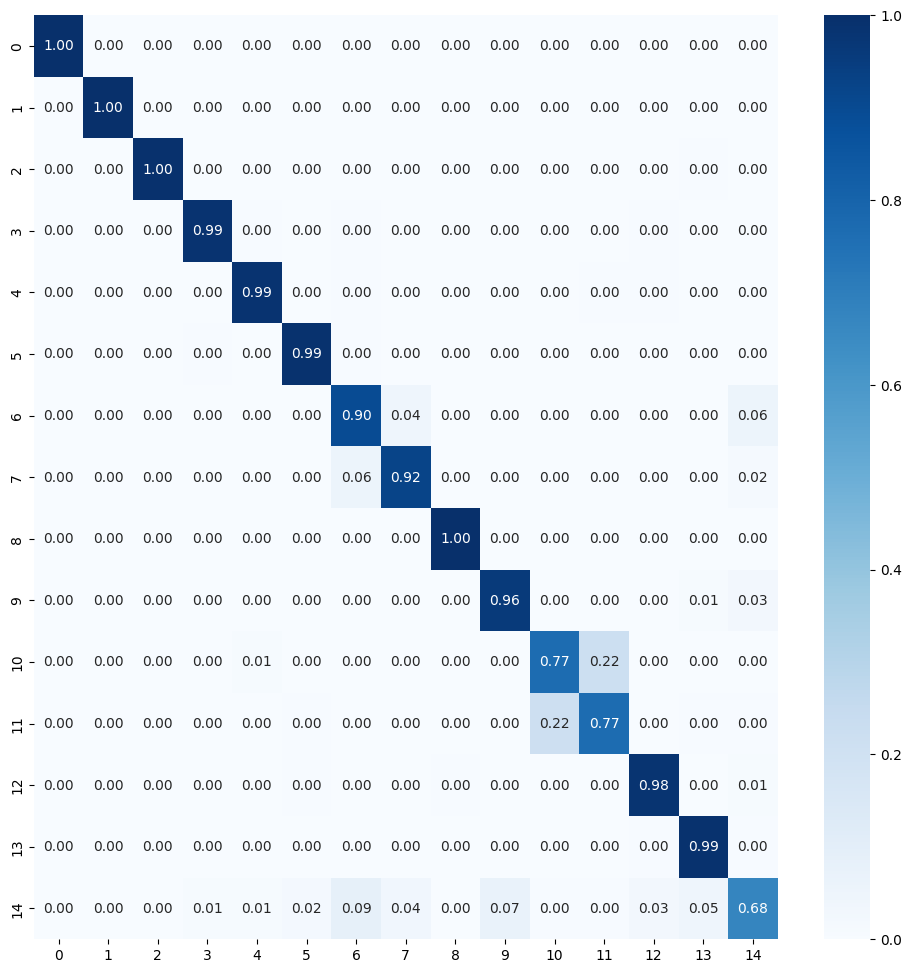


Best fold was 4 with val_accuracy: 0.9265
Average training accuracy in 5-fold: 0.963735830783844
Average validation precision in 5-fold: 0.9254762053489685

Test Metrics
test_acc_list: [0.9277036786079407, 0.9274073839187622, 0.9200000166893005, 0.9279999732971191, 0.9285926222801208]
Average Test Accuracy with 5-fold: 0.9263407349586487
test_loss_list: [0.2979190945625305, 0.3059077560901642, 0.33877840638160706, 0.3207562267780304, 0.3208487629890442]
Average Test Log Loss with 5-fold: 0.31684204936027527

Precision List: [0.9273749293981493, 0.928086705696078, 0.921655104675266, 0.9277126020843784, 0.9275140978506108]
Average Precision List with 5-fold: 0.9264686879408964
Recall List: [0.9277037037037038, 0.9274074074074073, 0.92, 0.9280000000000002, 0.9285925925925925]
Average Recall List with 5-fold: 0.9263407407407408
F1 Score List: [0.9273912466301227, 0.9273737966318573, 0.9173910524424831, 0.9264058943758298, 0.9272941285020299]
Average F1 Score List with 5-fold: 0.9251712237

In [22]:
%%time

num_classes = 15
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

In [23]:
print(f"test_acc_list_all = {test_acc_list_all}")
print(f"test_loss_list_all = {test_loss_list_all}")
print(f"precision_list_all = {precision_list_all}")
print(f"recall_list_all = {recall_list_all}")
print(f"f1_score_list_all = {f1_score_list_all}")

test_acc_list_all = [1.0, 1.0, 0.9973333239555359, 0.9907555460929871, 0.993925929069519, 0.9946666717529297, 0.9951111197471618, 0.9955555677413941, 0.9675555467605591, 0.9499798059463501, 0.9485185265541076, 0.9534359097480773, 0.9151746034622192, 0.9263407349586487]
test_loss_list_all = [0.10236843526363373, 0.033439606055617334, 0.048529957234859464, 0.21255553066730498, 0.05941887274384498, 0.04939214885234833, 0.03892153464257717, 0.036972878873348235, 0.19620774686336517, 0.2976830780506134, 0.2774766027927399, 0.2586609244346619, 0.33248048424720766, 0.31684204936027527]
precision_list_all = [1.0, 1.0, 0.9973470297732753, 0.9910939844819658, 0.9940201784127108, 0.9946939102184389, 0.995169743427607, 0.9956005438887601, 0.9691150499373867, 0.9515504481732122, 0.9499842437845591, 0.9536872254804883, 0.9237333161746626, 0.9264686879408964]
recall_list_all = [1.0, 1.0, 0.9973333333333333, 0.9907555555555556, 0.9939259259259261, 0.9946666666666667, 0.9951111111111113, 0.995555555555

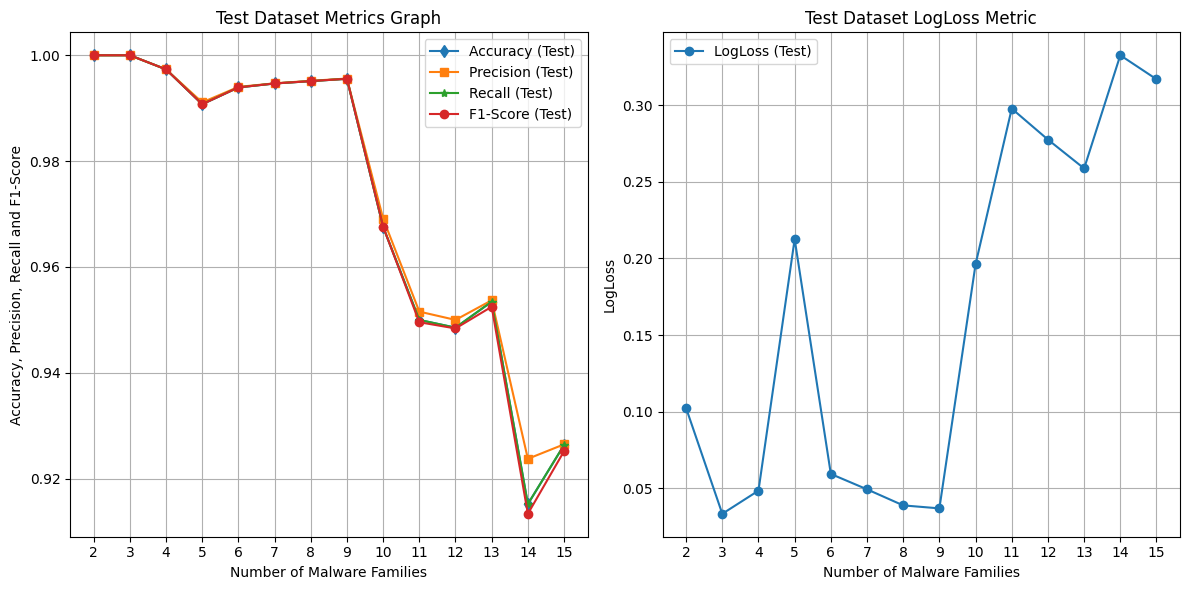

In [24]:
import matplotlib.pyplot as plt

# Datos históricos
strategies = [str(i) for i in range(2, len(test_acc_list_all) + 2)]

# Crear gráfico para Test Accuracy y Test LogLoss en una fila con dos columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


# Gráfico para Test Accuracy, Precision, Recall and F1-Score
axes[0].plot(strategies, test_acc_list_all, marker='d', label='Accuracy (Test)')
axes[0].plot(strategies, precision_list_all, marker='s', label='Precision (Test)')
axes[0].plot(strategies, recall_list_all, marker='*', label='Recall (Test)')
axes[0].plot(strategies, f1_score_list_all, marker='o', label='F1-Score (Test)')
axes[0].set_title('Test Dataset Metrics Graph')
axes[0].set_xlabel('Number of Malware Families')
axes[0].set_ylabel('Accuracy, Precision, Recall and F1-Score')
axes[0].legend()
axes[0].grid(True)

# Gráfico para Test LogLoss
axes[1].plot(strategies, test_loss_list_all, marker='o', label='LogLoss (Test)')
axes[1].set_title('Test Dataset LogLoss Metric')
axes[1].set_xlabel('Number of Malware Families')
axes[1].set_ylabel('LogLoss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
